# Dusty Red Galaxies in COSMOS-Web
AP 2026

Fitting ALMA spectra and SED fitting


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy
from utilities.cosmosWebHandler import CosmosWebHandler
from utilities.jadesHandler import JadesHandler
from utilities.catalogHandler import CatalogHandler

from astropy.table import Table
from astropy.io import fits
from utilities.almaA3Handler import AlmaA3Handler
from utilities.champsHandler import ChampsHandler
from utilities.mighteeHandler import MighteeHandler
from utilities.superDeblendedHandler import SuperDeblendedHandler
from utilities.jadesApertureEnum import JadesApertureEnum
from utilities.cosmosWebApertureEnum import CosmosWebApertureEnum
from utilities.bandEnum import BandEnum
from utilities.almaSpectraHandler import AlmaSpectraHandler

from utilities.utils import plot_alma_spectra, plot_alma_spectra_with_co_fit, plot_alma_spectra_with_h2o_fit, plot_alma_spectra_with_snr, include_scale_bar, include_interface_box, include_marker_scaled, include_ellipse_scaled, check_point_is_in_image, include_small_crosshair, plot_panel, get_statistics_with_sigma_clipping, get_peak_within_radius

from astropy.wcs import WCS
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
import fitz  # PyMuPDF
import os
from IPython.display import HTML
import pandas as pd

# silence noisy astropy WCS header-normalization warnings (DATE-*/OBSGEO-* datfix/obsfix, etc.)
import warnings
from astropy.wcs import FITSFixedWarning
warnings.simplefilter('ignore', FITSFixedWarning)

In [3]:
# constants

PATH_PREFIX = '/Volumes/Apple SDXC Reader Media/dusty-red'
# PATH_PREFIX = '/scratch/poulin.al/dawn'

# CATALOG_PATH = f"{PATH_PREFIX}/data/COSMOSWeb_mastercatalog_v1.1.fits"
# CATALOG_LIGHT_PATH = f'{PATH_PREFIX}/data/COSMOSWeb_mastercatalog_v1.1_no_cigale_no_bd_no_ml_morpho_no_se_aper_no_galfitm_morpho.fits'  # a lighter version of the catalog with the cigale, bd, ml-morpho, se_aper, and galfitm-morpho columns removed to save space and load time, since we won't be using those columns in our analysis
CATALOG_LIGHTER_PATH = f'{PATH_PREFIX}/data/COSMOSWeb_mastercatalog_v1.1_no_cigale_no_bd_no_ml_morpho_no_se_aper_no_galfitm_morpho_lightphotom.fits'  # an even lighter version of the catalog with only the photometric columns (and the id, ra, dec columns) included, for quick loading when we only need the photometric data and not the lephare/cigale/bd/ml-morpho/se_aper/galfitm-morpho data
# CATALOG_LIGHTEST_PATH = f'{PATH_PREFIX}/data/COSMOSWeb_mastercatalog_v1.1_no_cigale_no_bd_no_ml_morpho_no_se_aper_no_galfitm_morpho_lightphotom_condition_clean_miri.fits'  # an even lighter version of the catalog with only the photometric columns (and the id, ra, dec columns) included, and only the objects that pass the condition_clean_miri cut included, for quick loading when we only need the photometric data for the objects that pass the condition_clean_miri cut.

DATA_DIR    = f'{PATH_PREFIX}/data'   # folder with the tiles
# (old) only needed if viewing the tile images of the catalog objects

CHAMPS_PRELIM_PRIOR_CATALOG = f'{PATH_PREFIX}/data/alma_prelim_catalog/Catalogs/champs_prior_catalog.fits'
CHAMPS_PRELIM_BLIND_CATALOG = f'{PATH_PREFIX}/data/alma_prelim_catalog/Catalogs/champs_blind_catalog.fits'
CHAMPS_IMAGE_MAP40 = f'{PATH_PREFIX}/data/alma_prelim_catalog/image_maps/champs_full_field_concat_split_pbcorr_40.fits'
CHAMPS_IMAGE_MAP20 = f'{PATH_PREFIX}/data/alma_prelim_catalog/image_maps/champs_full_field_concat_split_pbcorr_20.fits'
CHAMPS_IMAGE_MAP = f'{PATH_PREFIX}/data/alma_prelim_catalog/image_maps/champs_full_field_concat_split_image.fits'

MIGHTEE_CATALOG = f'{PATH_PREFIX}/data/mightee_continuum/MIGHTEE_Continuum_DR1_COSMOS_5p2arcsec_I_v1.1.fits'
L_BAND_IMAGE = f'{PATH_PREFIX}/data/mightee_continuum/COSMOS_XS_VLA_Lband.fits'
S_BAND_IMAGE = f'{PATH_PREFIX}/data/mightee_continuum/COSMOS_XS_VLA_Sband_img.fits'
VLA_3GHZ_IMAGE = f'{PATH_PREFIX}/data/mightee_continuum/vla_3ghz_msmf.fits'

SUPER_DEBLENDED_CATALOG = f'{PATH_PREFIX}/data/super-deblended/COSMOS_deblended_FIR_201821_photo_phys_2023June.fits'

S2COSP0762_ALMA_SPECTRA = f'{PATH_PREFIX}/alma-spectra/171478/S2COS0762_ALMA_stacked_spectra.txt'
S2COSP0762_ALMA_CLEAN = f'{PATH_PREFIX}/alma-spectra/171478/S2COS0762-CO54-clean.fits'

ALMA_A3_PRIOR_CATALOG = f'{PATH_PREFIX}/data/almaA3Cosmos/catalogues v20250312/A-COSMOS_prior_v20250312_Gaussian_with_meta_corrected_within_Pbcor_0.1_to_publish.fits'
ALMA_A3_BLIND_CATALOG = f'{PATH_PREFIX}/data/almaA3Cosmos/catalogues v20250312/A-COSMOS_blind_v20250312_PyBDSF_with_meta_corrected_within_Pbcor_0.1_with_combined_surveys_to_publish.fits'

# cosmos-web catalog

In [4]:
# load the handler
catalogHandler = CosmosWebHandler(CATALOG_LIGHTER_PATH)

catalogHandler.load_catalog(CATALOG_LIGHTER_PATH)

#read the cosmos web header
print("Reading the COSMOSWeb header...")
print(catalogHandler.hdr)


Filename: /Volumes/Apple SDXC Reader Media/dusty-red/data/COSMOSWeb_mastercatalog_v1.1_no_cigale_no_bd_no_ml_morpho_no_se_aper_no_galfitm_morpho_lightphotom.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  PHOTOMETRY    1 BinTableHDU    107   784016R x 49C   [K, D, D, D, D, D, D, K, D, D, 5D, D, 5D, 5D, D, D, 5D, D, 5D, 5D, D, D, 5D, D, 5D, 5D, D, D, 5D, D, 5D, 5D, D, D, 5D, D, 5D, 5D, D, D, D, D, D, D, D, D, D, D, 3A]   
  2  LEPHARE       1 BinTableHDU     13   784016R x 2C   [K, D]   
 HDU Info: None
Catalog loaded successfully. Tables present: photom, lephare
Purity cut: 650707 out of 784016 objects remain. Fraction: 83.00%
MIRI cut: 177816 out of 650707 objects remain. Fraction: 27.33%
Reading the COSMOSWeb header...
XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / array data type                                NAXIS   =                    2 / n

#### misc

In [ ]:
# Backfill extra columns into the light "main" catalog from the full COSMOS-Web photometry
# catalog: the tile name plus calibrated & uncalibrated model flux errors for
# F115W/F150W/F277W/F444W/F770W (the model flux *errors* were dropped during reduction).
# Match by id, copy each column with its native FITS format, and resave the fits file.
# Idempotent: re-running skips columns that are already present.
import os

FULL_PHOTOM_CATALOG = '/Volumes/Apple SDXC Reader Media/dusty-red/COSMOSWeb_mastercatalog_v1.1_photom_primary.fits'

_bands = ['f115w', 'f150w', 'f277w', 'f444w', 'f770w']
_new_cols = (['tile']
             + [f'flux_err-cal_model_{b}' for b in _bands]
             + [f'flux_err-uncal_model_{b}' for b in _bands])

with fits.open(FULL_PHOTOM_CATALOG, memmap=True) as _full:
    _fdata = _full[1].data
    _fcols = {c.name: c for c in _full[1].columns}
    _full_id = np.asarray(_fdata['id'])
    _src = {c: np.array(_fdata[c]) for c in _new_cols}   # keep each column's native dtype
    _fmt = {c: _fcols[c].format for c in _new_cols}       # ...and its native FITS format (e.g. '3A', 'D')

with fits.open(CATALOG_LIGHTER_PATH) as _hdul:
    _phot = _hdul['PHOTOMETRY']
    _light_id = np.asarray(_phot.data['id'])

    # map full-catalog rows onto the light-catalog id order (robust to reordering)
    _order = np.argsort(_full_id)
    _pos = _order[np.searchsorted(_full_id, _light_id, sorter=_order)]
    assert np.array_equal(_full_id[_pos], _light_id), 'id mismatch between catalogs'

    _cols = list(_phot.columns)
    _added = []
    for _c in _new_cols:
        if _c in _phot.columns.names:
            continue
        _cols.append(fits.Column(name=_c, format=_fmt[_c], array=_src[_c][_pos]))
        _added.append(_c)

    if _added:
        _new_phot = fits.BinTableHDU.from_columns(_cols, header=_phot.header, name=_phot.name)
        _out = fits.HDUList([_hdul['PRIMARY'].copy(), _new_phot] +
                            [_hdul[i].copy() for i in range(1, len(_hdul)) if _hdul[i] is not _phot])

if _added:
    _tmp = CATALOG_LIGHTER_PATH + '.tmp'          # atomic resave: write temp then replace
    _out.writeto(_tmp, overwrite=True)
    os.replace(_tmp, CATALOG_LIGHTER_PATH)
    print('Added and resaved:', _added)
else:
    print('All requested columns already present; nothing to do.')

# reload so catalogHandler sees the new columns
catalogHandler.load_catalog(CATALOG_LIGHTER_PATH)


## make detection cuts

#### condition detection -- flux aperature

In [5]:
aperature_for_analysis = CosmosWebApertureEnum.APER_0p5.value if isinstance(catalogHandler, CosmosWebHandler) else None

if aperature_for_analysis is None:
    raise NotImplementedError("Aperture for analysis not defined for this catalog handler type.")

print(f"Using aperture {aperature_for_analysis} for analysis.")

# catalogHandler.clean_miri_cut(aperature = JadesApertureEnum.APER0.value)
catalogHandler.clean_miri_cut(aperature = aperature_for_analysis)
catalogHandler.make_selection_cut(aperature = aperature_for_analysis)

condition_detection_reviewed = catalogHandler.get_filter_cut(filtername='condition_detection_reviewed', filter_func=lambda photom, lephare, cigale, bd: photom['id'] != None, filter_to_take_from='condition_detection_aper')



Using aperture 2 for analysis.
MIRI cut: 177816 out of 650707 objects remain. Fraction: 27.33%
Filter cut: 29 out of 177816 objects remain. Fraction: 0.02%
Filter cut: 29 out of 29 objects remain. Fraction: 100.00%


#### check if any matches hollis akins catalogue

In [38]:
from astropy.table import Table
t = Table.read('/Volumes/Apple SDXC Reader Media/dusty-red/hollisakins/COSMOS-Web_LRDs.dat', format='ascii.ecsv')
# display the table
# t

#check if any ra, dec matches condition_detection_reviewed, tolerance is 1 arcsec but print the closest match if no match is found
from astropy.coordinates import SkyCoord
from astropy import units as u

coord = SkyCoord(ra=t['ra'], dec=t['dec'], unit=(u.deg, u.deg))
for i, row in enumerate(catalogHandler.get_photometry_catalog('condition_detection_reviewed')):
    obj_coord = SkyCoord(ra=row['ra'], dec=row['dec'], unit=(u.deg, u.deg))
    sep = coord.separation(obj_coord)
    if np.any(sep < 1*u.arcsec):
        print(f"Match found for object {row['id']} at index {i}:")
        print(t[sep.argmin()])
        print(f"Separation: {sep[sep.argmin()].arcsec} arcsec\n")
    else:
        print(f"No match found for object {row['id']} at index {i}. Closest match:")
        print(t[sep.argmin()])
        print(f"Separation: {sep[sep.argmin()].arcsec} arcsec\n")
        
        

Match found for object 17338 at index 0:
 id      ra       dec    in_cw_miri in_primer_nircam in_primer_miri  m814   m115   m150   m277   m444   m770  snr814 snr115 snr150 snr277 snr444 snr770 primer_m606 primer_m814 primer_m090 primer_m115 primer_m150 primer_m200 primer_m277 primer_m356 primer_m410 primer_m444 primer_m770 primer_m1800 primer_snr606 primer_snr814 primer_snr090 primer_snr115 primer_snr150 primer_snr200 primer_snr277 primer_snr356 primer_snr410 primer_snr444 primer_snr770 primer_snr1800 z_qso_med z_qso_u68 z_qso_l68 logLbol_med logLbol_u68 logLbol_l68 Av_qso_med Av_qso_u68 Av_qso_l68 chi2_qso z_gal_med z_gal_u68 z_gal_l68 logMstar_med logMstar_u68 logMstar_l68 SFR_100_med  SFR_100_u68  SFR_100_l68  Av_gal_med Av_gal_u68 Av_gal_l68 chi2_gal chi2_bd C444 Reff444_med Reff444_u68 Reff444_l68 Muv_int_med Muv_int_u68 Muv_int_l68
        deg       deg                                               AB mag AB mag AB mag AB mag AB mag AB mag                                         

### see detection from inspection plots

#### Cosmos-Web

In [ ]:
# cycle through the 18 detected objects, showing the COSMOS-Web DR1 per-source
# inspection plot (SED) for each via "https://cosmos2025.iap.fr/fitsmap/data/inspec_plots/cosmos_web_sed_{sid}.pdf"
import requests
import fitz  # PyMuPDF
from IPython.display import Image, display
import ipywidgets as widgets

pdf_url_sourceid = lambda sid: f"https://cosmos2025.iap.fr/fitsmap/data/inspec_plots/cosmos_web_sed_{sid}.pdf"

_cat_sed = catalogHandler.get_cat_photom('condition_detection_aper')
_sids = np.asarray(_cat_sed['id'])
# _tiles_sed = np.asarray(_cat_sed['tile']).astype(str)
_n_sed = len(_sids)

_png_cache = {}   # sid -> list of PNG byte-strings (one per page)

def _render_pdf(sid, dpi=130):
    if sid not in _png_cache:
        r = requests.get(pdf_url_sourceid(sid), timeout=30)
        r.raise_for_status()
        doc = fitz.open(stream=r.content, filetype='pdf')
        _png_cache[sid] = [doc.load_page(p).get_pixmap(dpi=dpi).tobytes('png')
                           for p in range(doc.page_count)]
        doc.close()
    return _png_cache[sid]


_slider_sed = widgets.IntSlider(min=0, max=_n_sed - 1, step=1, value=0, description='object')
_prev_sed = widgets.Button(description='◀ Prev')
_next_sed = widgets.Button(description='Next ▶')
_out_sed = widgets.Output()


def _show_sed(i):
    with _out_sed:
        _out_sed.clear_output(wait=True)
        sid = int(_sids[i])
        # print(f"[{i + 1}/{_n_sed}]  id={sid}  tile {_tiles_sed[i]}")
        if fitz is None:
            print("Install PyMuPDF to render the inspection plots:  pip install pymupdf")
            print("Direct link:", pdf_url_sourceid(sid))
            return
        try:
            for png in _render_pdf(sid):
                display(Image(data=png))
        except Exception as e:
            print(f"Could not load plot for id={sid}: {e}")
            print("Direct link:", pdf_url_sourceid(sid))


_slider_sed.observe(lambda change: _show_sed(change['new']), names='value')
_prev_sed.on_click(lambda _: setattr(_slider_sed, 'value', max(0, _slider_sed.value - 1)))
_next_sed.on_click(lambda _: setattr(_slider_sed, 'value', min(_n_sed - 1, _slider_sed.value + 1)))

display(widgets.HBox([_prev_sed, _slider_sed, _next_sed]), _out_sed)
_show_sed(_slider_sed.value)   # render the first object immediately


## simple size vs redness plot

In [6]:
rc = {}
rc['font.family'] = 'serif'
rc['font.serif'] = ['Times New Roman', 'DejaVu Serif']
rc['mathtext.fontset'] = 'dejavuserif'

rc['font.size'] = 14
rc['axes.labelsize'] = 16
rc['axes.titlesize'] = 18
rc['xtick.labelsize'] = 13
rc['ytick.labelsize'] = 13
rc['legend.fontsize'] = 13
rc['figure.figsize'] = (10, 7.5)

# Line and marker settings
rc['lines.linewidth'] = 1.5
rc['lines.markersize'] = 6
rc['patch.linewidth'] = 0.5

# Axes settings
rc['axes.linewidth'] = 1.0
rc['axes.grid'] = False
rc['axes.axisbelow'] = True
rc['axes.labelpad'] = 4.0

# Tick settings
rc['xtick.direction'] = 'in'
rc['ytick.direction'] = 'in'
rc['xtick.major.size'] = 5
rc['xtick.minor.size'] = 3
rc['ytick.major.size'] = 5
rc['ytick.minor.size'] = 3
rc['xtick.major.width'] = 1.0
rc['xtick.minor.width'] = 0.8
rc['ytick.major.width'] = 1.0
rc['ytick.minor.width'] = 0.8
rc['xtick.top'] = True
rc['ytick.right'] = True
rc['xtick.minor.visible'] = True
rc['ytick.minor.visible'] = True

# Legend settings
rc['legend.frameon'] = False
rc['legend.numpoints'] = 1
rc['legend.scatterpoints'] = 1

# Save settings
rc['savefig.dpi'] = 300
rc['savefig.bbox'] = 'tight'
rc['savefig.pad_inches'] = 0.05

_rcparams = rc

# cross-ref

## cross-ref super-deblended

In [ ]:
superDeblendedHandler = SuperDeblendedHandler(SUPER_DEBLENDED_CATALOG)
superDeblendedHandler.load_catalog()

#### cross-ref via RA,DEC

In [ ]:
#instead match the objects by ra, dec with tolerance of 0.5 arcsec, and print out their fluxes in the super-deblended catalog.
# Vectorized cross-match: build the SkyCoord arrays once and let match_to_catalog_sky do the
# nearest-neighbour search in compiled C (KD-tree) over all objects at once, instead of the
# O(N*M) Python double loop that constructed a SkyCoord per pair.
from astropy.coordinates import SkyCoord
import astropy.units as u
tolerance = 1.0 * u.arcsec

obj_cat = catalogHandler.get_cat_photom('condition_detection_reviewed')
sd_cat  = superDeblendedHandler.cat_photom['original']

obj_coords = SkyCoord(obj_cat['ra'] * u.deg, obj_cat['dec'] * u.deg)
sd_coords  = SkyCoord(sd_cat['RA'] * u.deg, sd_cat['Dec'] * u.deg)

# For every object, find the single closest super-deblended source (vectorized).
sd_idx, sep2d, _ = obj_coords.match_to_catalog_sky(sd_coords)
within_tol = sep2d < tolerance

superDeblended_ids_matched = []
matched_super_deblended : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the super-deblended catalog that matches it.
closest_match_super_deblended : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the super-deblended catalog that is the closest match to it, even if it is outside the tolerance.

original_cols_to_print = ['id', 'ra', 'dec', 'flux_aper_f115w', 'flux_err_aper_f115w', 'flux_aper_f150w', 'flux_err_aper_f150w', 'flux_aper_f444w', 'flux_err_aper_f444w', 'flux_aper_f770w', 'flux_err_aper_f770w']

for obj, j, sep, ok in zip(obj_cat, sd_idx, sep2d, within_tol):
    row = sd_cat[j]
    if ok:
        print(f"\nObject ID: {obj['id']} in condition_detection_reviewed matches with Super-Deblended ID: {row['ID']} at separation {sep.arcsec:.2f} arcsec")
        original_info = {col: obj[col] for col in original_cols_to_print}
        print(f"Original: \n{original_info}")
        print(f"Super Deblended: \n{row}")
        print(f"Object ID: {row['ID']} in super-deblended catalog")
        print(f"Object ID: {obj['id']}, Super-Deblended photo_red : {row['z_phot']}, spect_red: {row['z_spec']} \n\n")
        superDeblended_ids_matched.append(row['ID'])
        matched_super_deblended[obj['id']] = row
    else:
        print(f"Object ID: {obj['id']} not found in super-deblended catalog within {tolerance}")
        closest_match_super_deblended[obj['id']] = row
        print(f"Closest match is Super-Deblended ID: {row['ID']} at separation {sep.arcsec:.2f} arcsec\n\n")

# #filter the super-deblended catalog to only include the matched objects, and print out the number of matched objects and their IDs.
matched_super_deblended_mask = superDeblendedHandler.get_filter_cut(filtername='matched_super_deblended', filter_func=lambda photom: np.isin(photom['ID'], superDeblended_ids_matched), filter_to_take_from='original')


In [ ]:
#print all matches for ID 171478
for obj, j, sep, ok in zip(obj_cat, sd_idx, sep2d, within_tol):
    if obj['id'] == 171478:
        row = sd_cat[j]
        if ok:
            print(f"\nObject ID: {obj['id']} in condition_detection_reviewed matches with Super-Deblended ID: {row['ID']} at separation {sep.arcsec:.2f} arcsec")
            original_info = {col: obj[col] for col in original_cols_to_print}
            print(f"Original: \n{original_info}")
            print(f"Super Deblended: \n{row}")
            print(f"Object ID: {row['ID']} in super-deblended catalog")
            print(f"Object ID: {obj['id']}, Super-Deblended photo_red : {row['z_phot']}, spect_red: {row['z_spec']} \n\n")
            superDeblended_ids_matched.append(row['ID'])
            matched_super_deblended[obj['id']] = row
        else:
            print(f"Object ID: {obj['id']} not found in super-deblended catalog within {tolerance}")
            closest_match_super_deblended[obj['id']] = row
            print(f"Closest match is Super-Deblended ID: {row['ID']} at separation {sep.arcsec:.2f} arcsec with ra, dec: {row['RA']:.6f}, {row['Dec']:.6f}\n\n")

In [ ]:
print(f"Number of matched objects in super-deblended catalog: {len(superDeblended_ids_matched)}, matched catalog length: {len(superDeblendedHandler.get_cat_photom('matched_super_deblended'))}")
print(superDeblendedHandler.get_cat_photom('matched_super_deblended'))

## cross-ref MIGHTEE

In [110]:
mighteeHandler = MighteeHandler(MIGHTEE_CATALOG)
mighteeHandler.load_catalog()
print(mighteeHandler.hdr)

Filename: /Volumes/Apple SDXC Reader Media/dusty-red/data/mightee_continuum/MIGHTEE_Continuum_DR1_COSMOS_5p2arcsec_I_v1.1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      32   (7486, 7486)   float64   
 HDU Info: None
Catalog loaded successfully.
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 7486                                                  NAXIS2  =                 7486                                                  CTYPE1  = 'RA---TAN'                                                            CTYPE2  = 'DEC--TAN'                                                            CTYPE3  = 'FREQ    '                                                            CTYPE4  = 'STOKES  '                                      

### get image maps

In [111]:
#given that MIGHTEE catalog is just the intensity image, where each col and row corresponds to a pixel in the image, we can use the WCS information in the header to convert the ra, dec of our objects to pixel coordinates, and then extract the intensity value at those pixel coordinates from the MIGHTEE catalog.

# The MIGHTEE header keeps leftover FREQ/STOKES axes (4-D WCS) over a 2-D image,
# so use .celestial to get a clean 2-D (RA, Dec) WCS that takes a single SkyCoord.
mightee_header = mighteeHandler.hdr
mightee_wcs = WCS(mightee_header).celestial
print(f"distance between pixels in arcsec: {mightee_wcs.proj_plane_pixel_scales()[0].to(u.arcsec)}")

# Ensure we index a 2-D ndarray (Astropy Table does not support [y, x] tuple access)
mightee_image = mighteeHandler.cat_photom['original']
if hasattr(mightee_image, "as_array"):  # astropy.table.Table
    mightee_image = np.asarray(mightee_image.as_array().tolist(), dtype=float)
else:
    mightee_image = np.asarray(mightee_image, dtype=float)
mightee_image = np.squeeze(mightee_image)


distance between pixels in arcsec: 1.1000016000000001 arcsec


In [112]:
#include L band, S band, and VLA 3GHZ images
lBand_fits = fits.open(L_BAND_IMAGE)
sBand_fits = fits.open(S_BAND_IMAGE)
vla_fits = fits.open(VLA_3GHZ_IMAGE)

lBand_data = lBand_fits[0].data
lBand_hdr = lBand_fits[0].header

sBand_data = sBand_fits[0].data
sBand_hdr = sBand_fits[0].header

vla_data = vla_fits[0].data
vla_hdr = vla_fits[0].header

# print(f"L Band image shape: {lBand_data.shape}, header keys: {lBand_hdr}")
# print(f"S Band image shape: {sBand_data.shape}, header keys: {sBand_hdr}")
# print(f"VLA 3GHz image shape: {vla_data.shape}, header keys: {vla_hdr}")
# print(f"L Band WCS info: {WCS(lBand_hdr)} \n")
# print(f"S Band WCS info: {WCS(sBand_hdr)} \n")
# print(f"VLA 3GHz WCS info: {WCS(vla_hdr)} \n")

lBand_image = np.squeeze(lBand_data)
sBand_image = np.squeeze(sBand_data)
vla_image = np.squeeze(vla_data)

lBand_wcs = WCS(lBand_hdr)
sBand_wcs = WCS(sBand_hdr)
vla_wcs = WCS(vla_hdr)

### aside, plot mini plots for mightee points around sources

In [ ]:
zoom_size_arcsec = 5.75 + 10 # in arcsec
zoom_size_pixels = int(zoom_size_arcsec / mightee_wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value)  # convert zoom size to pixels
print(f"Zoom size in pixels: {zoom_size_pixels} pixels (for {zoom_size_arcsec} arcsec at MIGHTEE pixel scale)")

### get fluxes and errors from each detected object

In [ ]:
# get the VLA 3GHz image and header from the fits file, and then use the WCS information to convert the ra, dec of our objects to pixel coordinates, and then extract the intensity value at those pixel coordinates from the VLA 3GHz image.
vla_resolution_arcsec = None
vla_statistic_resolution_arcsec = None
matched_vla : dict[int, tuple[bool, float, float, float, float]] = {} #dict stores the object id as key, and a tuple of (ok_detection, intensity_point, intensity_peak, stdev_value, rms_value) as value
for obj in catalogHandler.get_cat_photom('condition_detection_reviewed'):
    obj_id = obj['id']
    ra, dec = obj['ra'], obj['dec']
    if check_point_is_in_image(vla_image, vla_wcs, ra, dec):
        print(f"Object ID: {obj_id} is in VLA 3GHz image bounds. RA={ra}, Dec={dec}.")
        
        pixel_scales = np.abs(vla_wcs.celestial.proj_plane_pixel_scales()[0]).to(u.deg)
        if 'BMAJ' in vla_hdr:
            beamsizeMaj = vla_hdr['BMAJ'] * u.deg
        else:
            print(f"Warning: BMAJ keyword not found in header. Using default beamsize of {vla_resolution_arcsec} arcsec.")
            beamsizeMaj = (vla_resolution_arcsec if vla_resolution_arcsec is not None else 1) * u.arcsec
        if 'BMIN' in vla_hdr:
            beamsizeMin = vla_hdr['BMIN'] * u.deg
        else:
            print(f"Warning: BMIN keyword not found in header. Using default beamsize of {vla_resolution_arcsec} arcsec.")
            beamsizeMin = (vla_resolution_arcsec if vla_resolution_arcsec is not None else 1) * u.arcsec
            
        #beam angle
        if 'BPA' in vla_hdr:
            beam_pa = vla_hdr['BPA'] * u.deg
        else:
            print(f"Warning: BPA keyword not found in header. Using default beam position angle of 0 degrees.")
            beam_pa = 0 * u.deg
        beamsize_maj_arcsec = beamsizeMaj.to(u.arcsec).value
        beamsize_min_arcsec = beamsizeMin.to(u.arcsec).value

        if vla_resolution_arcsec is None:
            # radius_for_peak_arcsec as 1*BMAJ in arcseconds for each image.
            radius = int(np.ceil((1 * beamsizeMaj / pixel_scales).decompose().value)) # in pixels, then convert to arcseconds for the function input
            radius_for_peak_arcsec = (radius * pixel_scales).to(u.arcsec).value #akin to resolution, since it's 1*BMAJ, and convert it to arcseconds
            # print(f"{title_prefix} beamsize: {beamsize_maj_arcsec:.2f} x {beamsize_min_arcsec:.2f} arcsec, pixel scale: {pixel_scales.to(u.arcsec)}, radius: {radius} pixels, radius for peak measurement: {radius_for_peak_arcsec:.2f} arcsec, radius for statistics: {radius_for_statistics_arcsec:.2f} arcsec")
        else:
            radius_for_peak_arcsec = vla_resolution_arcsec
            # print(f"{title_prefix} using provided resolution for analysis: {vla_resolution_arcsec} arcsec, radius for peak measurement: {radius_for_peak_arcsec:.2f} arcsec, radius for statistics: {radius_for_statistics_arcsec:.2f} arcsec")
            
        if vla_statistic_resolution_arcsec is not None:
            radius_for_statistics_arcsec = vla_statistic_resolution_arcsec

        elif vla_resolution_arcsec is not None and vla_statistic_resolution_arcsec is None:
            radius_for_statistics_arcsec = round(radius_for_peak_arcsec * 5)

        elif vla_resolution_arcsec is None and vla_statistic_resolution_arcsec is None:
            radius_for_statistics_arcsec = round(radius_for_peak_arcsec * 5)

            
        x_pixel, y_pixel, intensity_point, intensity_avg, intensity_peak = get_peak_within_radius(vla_image, vla_wcs, vla_hdr, obj_id, ra, dec, radius_arcsec=radius_for_peak_arcsec)


        stdev_value, rms_value = get_statistics_with_sigma_clipping(vla_image, x_pixel, y_pixel, radius_arcsec=radius_for_statistics_arcsec, sigma_threshold=3, pixscale_arcsec=pixel_scales.to(u.arcsec).value)
        sigma3 = 3 * stdev_value
        
        matched_vla[obj_id] = (intensity_peak > sigma3, intensity_point, intensity_avg, intensity_peak, stdev_value, rms_value)
        print(f"Object ID: {obj_id}, VLA 3GHz point intensity: {intensity_point:.3g}, avg: {intensity_avg:.3g}, peak: {intensity_peak:.3g}, stdev: {stdev_value:.3g}, RMS: {rms_value:.3g}, 3-sigma: {sigma3:.3g}\n")
    else:
        print(f"Object ID: {obj_id} is out of VLA 3GHz image bounds. RA={ra}, Dec={dec}.\n\n")

## cross-ref alma CHAMPS

### ALMA prior

In [ ]:
champsPriorHandler = ChampsHandler(CHAMPS_PRELIM_PRIOR_CATALOG)
champsPriorHandler.load_catalog()

### ALMA Blind

In [ ]:
champsBlindHandler = ChampsHandler(CHAMPS_PRELIM_BLIND_CATALOG)
champsBlindHandler.load_catalog()

In [ ]:
# print both headers
print(f"CHAMPS Prior catalog header: {champsPriorHandler.hdr}")
print(f"CHAMPS Blind catalog header: {champsBlindHandler.hdr}")

print(f"Observed frequency of CHAMPS Prior catalog: {champsPriorHandler.hdr.get('OBSFREQ', 'N/A')} Hz")
print(f"Observed frequency of CHAMPS Blind catalog: {champsBlindHandler.hdr.get('OBSFREQ', 'N/A')} Hz")

### Cross ref

#### cross ref with RA,DEC

In [ ]:
#try matching by ra, dec with tolerance of 1 arcsec
from astropy.coordinates import SkyCoord
import astropy.units as u
tolerance = 1 * u.arcsec
blind_matches_ids = []
prior_matches_ids = []
matched_prior : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the ALMA prior catalog that matches it.
matched_blind : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the ALMA blind catalog that matches it.

closest_match_prior : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the ALMA prior catalog that is the closest match to it, even if it is outside the tolerance.
closest_match_blind : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the ALMA blind catalog that is the closest match to it, even if it is outside the tolerance.
for obj in catalogHandler.get_cat_photom('condition_detection_reviewed'):
    obj_coord = SkyCoord(obj['ra'] * u.deg, obj['dec'] * u.deg)
    print(f"Object ID: {obj['id']} in condition_detection_reviewed at RA={obj['ra']:.5f}, Dec={obj['dec']:.5f}")
    
    # Check in ALMA prior catalog
    prior_match = None
    closest_prior = float('inf')
    for row in champsPriorHandler.cat_photom['original']:
        row_coord = SkyCoord(row['ra'] * u.deg, row['dec'] * u.deg)
        separation = obj_coord.separation(row_coord)
        if separation < tolerance:
            prior_match = row
            break
        if separation < closest_prior:
            closest_prior = separation
            closest_match_prior[obj['id']] = row
    if prior_match is not None:
        print(f"Found match in ALMA prior catalog for Object ID: {obj['id']} at separation {obj_coord.separation(row_coord).arcsec:.2f} arcsec")
        print(prior_match)
        prior_matches_ids.append(prior_match['cosmos_id'])
        matched_prior[obj['id']] = prior_match
    else:
        print(f"No match found in ALMA prior catalog for Object ID: {obj['id']} within {tolerance}")
    
    # Check in ALMA blind catalog
    blind_match = None
    closest_blind = float('inf')
    for row in champsBlindHandler.cat_photom['original']:
        row_coord = SkyCoord(row['ra'] * u.deg, row['dec'] * u.deg)
        separation = obj_coord.separation(row_coord)
        if separation < tolerance:
            blind_match = row
            break
        if separation < closest_blind:
            closest_blind = separation
            closest_match_blind[obj['id']] = row
    if blind_match is not None:
        print(f"Found match in ALMA blind catalog for Object ID: {obj['id']} at separation {obj_coord.separation(row_coord).arcsec:.2f} arcsec")
        print(blind_match)
        blind_matches_ids.append(blind_match['id'])
        matched_blind[obj['id']] = blind_match
    else:
        print(f"No match found in ALMA blind catalog for Object ID: {obj['id']} within {tolerance}")
    
    if obj['id'] in matched_prior:
        print(f"ALMA Prior match for Object ID {obj['id']}: {matched_prior[obj['id']]}")
    else:
        if obj['id'] in closest_match_prior:
            print(f"Closest ALMA Prior match for Object ID {obj['id']} is at separation {closest_prior.arcsec:.2f} arcsec: {closest_match_prior[obj['id']]}")
    if obj['id'] in matched_blind:
        print(f"ALMA Blind match for Object ID {obj['id']}: {matched_blind[obj['id']]}\n\n")
    else:
        if obj['id'] in closest_match_blind:
            print(f"Closest ALMA Blind match for Object ID {obj['id']} is at separation {closest_blind.arcsec:.2f} arcsec: {closest_match_blind[obj['id']]}\n\n")
        
        
# #filter the ALMA prior and blind catalogs to only include the matches, and print out the filtered catalogs.
# filtered_prior = champsPriorHandler.get_filter_cut(filtername='alma_prior_matches', filter_func=lambda photom: np.isin(photom['cosmos_id'], prior_matches_ids), filter_to_take_from='original')
# filtered_blind = champsBlindHandler.get_filter_cut(filtername='alma_blind_matches', filter_func=lambda photom: np.isin(photom['id'], blind_matches_ids), filter_to_take_from='original')

### visually inspect CHAMPS with pbcorr40

In [113]:
#read CHAMPS image from fits file and extract the pixel values at the positions of the objects in the condition_detection_reviewed catalog, using the WCS information in the CHAMPS image header to convert the ra, dec of the objects to pixel coordinates in the CHAMPS image.
from astropy.io import fits
from astropy.wcs import WCS
champs_fits = fits.open(CHAMPS_IMAGE_MAP20)
champs_image_raw = champs_fits[0].data #4D array for RA--sin, Dec--cos, FREQ, STOKES axes
champs_image = np.squeeze(champs_image_raw)  # remove singleton dimensions to get a 2D image
champs_header = champs_fits[0].header
print(f"CHAMPS image shape: {champs_image.shape}")
print(f"CHAMPS header keys: {champs_header}")
print(f"CHAMPS WCS info: {WCS(champs_header)} \n \n")
champs_wcs = WCS(champs_header)

        

CHAMPS image shape: (17280, 19200)
CHAMPS header keys: SIMPLE  =                    T /Standard FITS                                   BITPIX  =                  -32 /Floating point (32 bit)                         NAXIS   =                    4                                                  NAXIS1  =                19200                                                  NAXIS2  =                17280                                                  NAXIS3  =                    1                                                  NAXIS4  =                    1                                                  EXTEND  =                    T                                                  BSCALE  =   1.000000000000E+00 /PHYSICAL = PIXEL*BSCALE + BZERO                 BZERO   =   0.000000000000E+00                                                  BMAJ    =   3.055555555556E-04                                                  BMIN    =   3.055555555556E-04                                   

### get fluxes and errors from each detected object

In [ ]:
matched_champs_image : dict[int, tuple[bool, float, float, float, float, float]] = {} #dict stores the object id as key, and a tuple of (ok_detection, intensity_point, intensity_avg, intensity_peak, stdev_value, rms_value) as value

for obj in catalogHandler.get_cat_photom('condition_detection_reviewed'):
    obj_id = obj['id']
    ra, dec = obj['ra'], obj['dec']
    if check_point_is_in_image(champs_image, champs_wcs, ra, dec):
        print(f"Object ID: {obj_id} is in CHAMPS image bounds. RA={ra}, Dec={dec}.")
        
        pixel_scales = np.abs(champs_wcs.celestial.proj_plane_pixel_scales()[0]).to(u.deg)
        if 'BMAJ' in champs_header:
            beamsizeMaj = champs_header['BMAJ'] * u.deg
        else:
            print(f"Warning: BMAJ keyword not found in header. Using default beamsize of 1 arcsec.")
            beamsizeMaj = 1 * u.arcsec
        if 'BMIN' in champs_header:
            beamsizeMin = champs_header['BMIN'] * u.deg
        else:
            print(f"Warning: BMIN keyword not found in header. Using default beamsize of 1 arcsec.")
            beamsizeMin = 1 * u.arcsec
            
        #beam angle
        if 'BPA' in champs_header:
            beam_pa = champs_header['BPA'] * u.deg
        else:
            print(f"Warning: BPA keyword not found in header. Using default beam position angle of 0 degrees.")
            beam_pa = 0 * u.deg
        beamsize_maj_arcsec = beamsizeMaj.to(u.arcsec).value
        beamsize_min_arcsec = beamsizeMin.to(u.arcsec).value
        
        champs_statistic_radius_arcsec = 5.0  # Use a fixed radius of 5 arcseconds for statistics in the CHAMPS image
        champs_resolution_arcsec = None
        
        x_pixel, y_pixel, intensity_point, intensity_avg, intensity_peak = get_peak_within_radius(champs_image, champs_wcs, champs_header, obj_id, ra, dec, radius_arcsec=champs_resolution_arcsec)
        
        
        stdev_value, rms_value = get_statistics_with_sigma_clipping(champs_image, x_pixel, y_pixel, radius_arcsec=champs_statistic_radius_arcsec, sigma_threshold=3, pixscale_arcsec=pixel_scales.to(u.arcsec).value)
        sigma3 = 3 * stdev_value
        
        matched_champs_image[obj_id] = (intensity_peak > sigma3, intensity_point, intensity_avg, intensity_peak, stdev_value, rms_value)
        print(f"Object ID: {obj_id}, CHAMPS point intensity: {intensity_point:.3g}, avg: {intensity_avg:.3g}, peak: {intensity_peak:.3g}, stdev: {stdev_value:.3g}, RMS: {rms_value:.3g}, 3-sigma: {sigma3:.3g}\n")
        
    else:
        print(f"Object ID: {obj_id} is out of CHAMPS image bounds. RA={ra}, Dec={dec}.\n\n")

## Cross ref ALMA A3 Cosmos

### Load Alma Prior and Alma Blind

In [ ]:
almaA3PriorHandler = AlmaA3Handler(ALMA_A3_PRIOR_CATALOG)
almaA3PriorHandler.load_catalog()

almaA3BlindHandler = AlmaA3Handler(ALMA_A3_BLIND_CATALOG)
almaA3BlindHandler.load_catalog()

In [ ]:
#print blind and priors hdr
print("Blind Header:")
print(almaA3BlindHandler.hdr)
print("Priors Header:")
print(almaA3PriorHandler.hdr)

In [ ]:
for i, row in enumerate(almaA3PriorHandler.cat_photom['original']):
    print(f"ALMA A3 Prior Catalog Row {i}: {row}") if i < 1 else None  # Print only the first 5 rows for brevity
    
for i, row in enumerate(almaA3BlindHandler.cat_photom['original']):
    print(f"ALMA A3 Blind Catalog Row {i}: {row}") if i < 1 else None  # Print only the first 5 rows for brevity

In [ ]:
#print the frequency of the ALMA A3 prior and blind catalogs based on  TTYPE9  = 'Obs_wavelength'  which is in microns, and convert it to frequency in Hz using the speed of light.
from astropy.constants import c
def micron_wavelength_to_frequency(wavelength_micron):
    wavelength_m = wavelength_micron * 1e-6  # convert microns to meters
    frequency_hz = c.value / wavelength_m  # frequency in Hz
    return frequency_hz

# prior_obs_wavelengths = almaA3PriorHandler.cat_photom['original']['Obs_wavelength']
# prior_obs_frequencies = micron_wavelength_to_frequency(prior_obs_wavelengths)
# blind_obs_wavelengths = almaA3BlindHandler.cat_photom['original']['Obs_wavelength']
# blind_obs_frequencies = micron_wavelength_to_frequency(blind_obs_wavelengths)

# print(f"ALMA A3 Prior Catalog Observed Frequencies (GHz): {np.sort(prior_obs_frequencies / 1e9)}")

### try cross-matching via RA,Dec

In [ ]:
matched_almaA3_prior : dict[int, Table] = {}
matched_almaA3_blind : dict[int, Table] = {}

obj_cat = catalogHandler.get_cat_photom('condition_detection_reviewed')
obj_coords = SkyCoord(obj_cat['ra'] * u.deg, obj_cat['dec'] * u.deg)

tolerance = 1 * u.arcsec  # Define a matching tolerance of 1 arcsecond

# Match ALMA A3 Prior
prior_cat = almaA3PriorHandler.cat_photom['original']
prior_coords = SkyCoord(prior_cat['RA'] * u.deg, prior_cat['Dec'] * u.deg)
prior_idx, sep2d, _ = obj_coords.match_to_catalog_sky(prior_coords)
for obj, j, sep in zip(obj_cat, prior_idx, sep2d):
    if sep < tolerance:
        print(f"Found match in ALMA A3 prior catalog for Object ID: {obj['id']} at separation {sep.arcsec:.2f} arcsec")
        matched_almaA3_prior[obj['id']] = prior_cat[j]
    else:
        print(f"No match found in ALMA A3 prior catalog for Object ID: {obj['id']} within {tolerance}")

# Match ALMA A3 Blind
blind_cat = almaA3BlindHandler.cat_photom['original']
blind_coords = SkyCoord(blind_cat['RA'] * u.deg, blind_cat['DEC'] * u.deg)
blind_idx, sep2d, _ = obj_coords.match_to_catalog_sky(blind_coords)
for obj, j, sep in zip(obj_cat, blind_idx, sep2d):
    if sep < tolerance:
        print(f"Found match in ALMA A3 blind catalog for Object ID: {obj['id']} at separation {sep.arcsec:.2f} arcsec")
        matched_almaA3_blind[obj['id']] = blind_cat[j]
    else:
        print(f"No match found in ALMA A3 blind catalog for Object ID: {obj['id']} within {tolerance}")


In [ ]:
# print the row for the matched object for id 171478 in both blind and prior catalogs, if it exists.
obj_id_to_check = 171478
if obj_id_to_check in matched_almaA3_prior:
    print(f"Matched ALMA A3 Prior Catalog Row for Object ID {obj_id_to_check}: {matched_almaA3_prior[obj_id_to_check]}")
else:
    print(f"No match found in ALMA A3 Prior Catalog for Object ID {obj_id_to_check}")
    
if obj_id_to_check in matched_almaA3_blind:
    print(f"Matched ALMA A3 Blind Catalog Row for Object ID {obj_id_to_check}: {matched_almaA3_blind[obj_id_to_check]}")
else:
    print(f"No match found in ALMA A3 Blind Catalog for Object ID {obj_id_to_check}")

In [ ]:
# from the original catalog, how far away is id 171478 from id 171494 and id 171453 and id 171483 and id 185238

id171478 = catalogHandler.get_cat_photom('condition_detection_reviewed')[catalogHandler.get_cat_photom('condition_detection_reviewed')['id'] == 171478][0]
id171494 = catalogHandler.get_cat_photom('original')[catalogHandler.get_cat_photom('original')['id'] == 171494][0]
id171453 = catalogHandler.get_cat_photom('original')[catalogHandler.get_cat_photom('original')['id'] == 171453][0]
id171483 = catalogHandler.get_cat_photom('original')[catalogHandler.get_cat_photom('original')['id'] == 171483][0]
id185238 = catalogHandler.get_cat_photom('original')[catalogHandler.get_cat_photom('original')['id'] == 185238][0]

print(f"Distance between ID 171478 and ID 171494: {SkyCoord(id171478['ra'] * u.deg, id171478['dec'] * u.deg).separation(SkyCoord(id171494['ra'] * u.deg, id171494['dec'] * u.deg)).arcsec:.2f} arcsec")
print(f"Distance between ID 171478 and ID 171453: {SkyCoord(id171478['ra'] * u.deg, id171478['dec'] * u.deg).separation(SkyCoord(id171453['ra'] * u.deg, id171453['dec'] * u.deg)).arcsec:.2f} arcsec")
print(f"Distance between ID 171478 and ID 171483: {SkyCoord(id171478['ra'] * u.deg, id171478['dec'] * u.deg).separation(SkyCoord(id171483['ra'] * u.deg, id171483['dec'] * u.deg)).arcsec:.2f} arcsec")
print(f"Distance between ID 171478 and ID 185238: {SkyCoord(id171478['ra'] * u.deg, id171478['dec'] * u.deg).separation(SkyCoord(id185238['ra'] * u.deg, id185238['dec'] * u.deg)).arcsec:.2f} arcsec")

## create super table

In [ ]:
# print a csv with Object/29, ID, RA, DEC, F444W, F770W,mag_F444W, mag_F770W, Radius_Sersic, Flux, σ (MeerKAT), Flux, σ, 3σ (L Band), Flux, σ, 3σ (S Band), Flux, σ, 3σ (VLA 3Ghz), Flux, σ, 3σ (CHAMPS) for all the objects in the condition_detection_reviewed catalog, filling in the values from the various catalogs and measurements we've made, and leaving blank if no match or measurement is available.

import csv
with open('compiled_catalog.csv', mode='w', newline='') as csv_file:
    fieldnames = ['Object/29', 'ID', 'RA', 'DEC', 'F444W', 'F770W', 'mag_F444W', 'mag_F770W', 'Radius_Sersic', 'Flux_MeerKAT Sigma_MeerKAT 3Sigma_MeerKAT', 'Flux_LBand Sigma_LBand 3Sigma_LBand', 'Flux_SBand Sigma_SBand 3Sigma_SBand', 'Flux_VLA3GHz Sigma_VLA3GHz 3Sigma_VLA3GHz', 'Flux_CHAMPS Sigma_CHAMPS 3Sigma_CHAMPS']
    writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
    writer.writeheader()
    for i, obj in enumerate(catalogHandler.get_cat_photom('condition_detection_reviewed')):
        obj_id = obj['id']
        ra = obj['ra']
        dec = obj['dec']
        f115w = obj.get('flux_model_f115w', '')[2] # flux is in microJy
        f150w = obj.get('flux_model_f150w', '')[2] # flux is in microJy
        f277w = obj.get('flux_model_f277w', '')[2] # flux is in microJy
        f444w = obj.get('flux_model_f444w', '')[2] # flux is in microJy
        f770w = obj.get('flux_model_f770w', '')[2] # flux is in microJy
        #convert flux to mJy
        f115w = f115w / 1000 if f115w != '' else ''
        f150w = f150w / 1000 if f150w != '' else ''
        f277w = f277w / 1000 if f277w != '' else ''
        f444w = f444w / 1000 if f444w != '' else ''
        f770w = f770w / 1000 if f770w != '' else ''
        
        mag_f444w = obj.get('mag_model_f444w', '')[2]
        mag_f770w = obj.get('mag_model_f770w', '')[2]
        radius_sersic = obj.get('radius_sersic', '') # in degrees
        #convert to arcsec
        radius_sersic = radius_sersic * 3600 if radius_sersic != '' else ''
        
        if not check_point_is_in_image(mightee_image, mightee_wcs, ra, dec):
            print(f"Object ID {obj_id} is out of MIGHTEE image bounds. Skipping measurements for this object.")
            x_pixel_meerkat, y_pixel_meerkat, point_int_meerkat, avg_int_meerkat, flux_meerkat = np.nan, np.nan, np.nan, np.nan, np.nan
            stdev_meerkat, rms_meerkat = np.nan, np.nan
        else:
            x_pixel_meerkat, y_pixel_meerkat, point_int_meerkat, avg_int_meerkat, flux_meerkat = get_peak_within_radius(image=mightee_image, wcs=mightee_wcs, hdr=mightee_header, id=obj_id, ra=ra, dec=dec, radius_arcsec=None)
            stdev_meerkat, rms_meerkat = get_statistics_with_sigma_clipping(image=mightee_image, x_pixel=x_pixel_meerkat, y_pixel=y_pixel_meerkat, sigma_threshold=3, radius_arcsec=None, pixscale_arcsec=None, wcs=mightee_wcs, hdr=mightee_header)
        
        if not check_point_is_in_image(lBand_image, lBand_wcs, ra, dec):
            print(f"Object ID {obj_id} is out of L Band image bounds. Skipping measurements for this object.")
            x_pixel_lband, y_pixel_lband, point_int_lband, avg_int_lband, flux_lband = np.nan, np.nan, np.nan, np.nan, np.nan
            stdev_lband, rms_lband = np.nan, np.nan
        else:
            x_pixel_lband, y_pixel_lband, point_int_lband, avg_int_lband, flux_lband = get_peak_within_radius(image=lBand_image, wcs=lBand_wcs, hdr=lBand_hdr, id=obj_id, ra=ra, dec=dec, radius_arcsec=None)
            stdev_lband, rms_lband = get_statistics_with_sigma_clipping(image=lBand_image, x_pixel=x_pixel_lband, y_pixel=y_pixel_lband, sigma_threshold=3, radius_arcsec=None, pixscale_arcsec=None, wcs=lBand_wcs, hdr=lBand_hdr)
        
        if not check_point_is_in_image(sBand_image, sBand_wcs, ra, dec):
            print(f"Object ID {obj_id} is out of S Band image bounds. Skipping measurements for this object.")
            x_pixel_sband, y_pixel_sband, point_int_sband, avg_int_sband, flux_sband = np.nan, np.nan, np.nan, np.nan, np.nan
            stdev_sband, rms_sband = np.nan, np.nan
        else:
            x_pixel_sband, y_pixel_sband, point_int_sband, avg_int_sband, flux_sband = get_peak_within_radius(image=sBand_image, wcs=sBand_wcs, hdr=sBand_hdr, id=obj_id, ra=ra, dec=dec, radius_arcsec=None)
            stdev_sband, rms_sband = get_statistics_with_sigma_clipping(image=sBand_image, x_pixel=x_pixel_sband, y_pixel=y_pixel_sband, sigma_threshold=3, radius_arcsec=None, pixscale_arcsec=None, wcs=sBand_wcs, hdr=sBand_hdr)
        
        if not check_point_is_in_image(vla_image, vla_wcs, ra, dec):
            print(f"Object ID {obj_id} is out of VLA 3GHz image bounds. Skipping measurements for this object.")
            x_pixel_vla, y_pixel_vla, point_int_vla, avg_int_vla, flux_vla = np.nan, np.nan, np.nan, np.nan, np.nan
            stdev_vla, rms_vla = np.nan, np.nan
        else:
            x_pixel_vla, y_pixel_vla, point_int_vla, avg_int_vla, flux_vla = get_peak_within_radius(image=vla_image, wcs=vla_wcs, hdr=vla_hdr, id=obj_id, ra=ra, dec=dec, radius_arcsec=None)
            stdev_vla, rms_vla = get_statistics_with_sigma_clipping(image=vla_image, x_pixel=x_pixel_vla, y_pixel=y_pixel_vla, sigma_threshold=3, radius_arcsec=None, pixscale_arcsec=None, wcs=vla_wcs, hdr=vla_hdr)
        
        if not check_point_is_in_image(champs_image, champs_wcs, ra, dec):
            print(f"Object ID {obj_id} is out of CHAMPS image bounds. Skipping measurements for this object.")
            x_pixel_champs, y_pixel_champs, point_int_champs, avg_int_champs, flux_champs = np.nan, np.nan, np.nan, np.nan, np.nan
            stdev_champs, rms_champs = np.nan, np.nan
        else:
            x_pixel_champs, y_pixel_champs, point_int_champs, avg_int_champs, flux_champs = get_peak_within_radius(image=champs_image, wcs=champs_wcs, hdr=champs_header, id=obj_id, ra=ra, dec=dec, radius_arcsec=None)
            stdev_champs, rms_champs = get_statistics_with_sigma_clipping(image=champs_image, x_pixel=x_pixel_champs, y_pixel=y_pixel_champs, sigma_threshold=3, radius_arcsec=5.0, pixscale_arcsec=champs_wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value, wcs=champs_wcs, hdr=champs_header)
        
        
        writer.writerow({
            'Object/29': f"{i+1}/29",
            'ID': obj_id,
            'RA': ra,
            'DEC': dec,
            'F444W': f444w,
            'F770W': f770w,
            'mag_F444W': mag_f444w,
            'mag_F770W': mag_f770w,
            'Radius_Sersic': radius_sersic,
            'Flux_MeerKAT Sigma_MeerKAT 3Sigma_MeerKAT': f"{flux_meerkat:.3g} {rms_meerkat:.3g} {3*rms_meerkat:.3g}" if not np.isnan(flux_meerkat) else '',
            'Flux_LBand Sigma_LBand 3Sigma_LBand': f"{flux_lband:.3g} {rms_lband:.3g} {3*rms_lband:.3g}" if not np.isnan(flux_lband) else '',
            'Flux_SBand Sigma_SBand 3Sigma_SBand': f"{flux_sband:.3g} {rms_sband:.3g} {3*rms_sband:.3g}" if not np.isnan(flux_sband) else '',
            'Flux_VLA3GHz Sigma_VLA3GHz 3Sigma_VLA3GHz': f"{flux_vla:.3g} {rms_vla:.3g} {3*rms_vla:.3g}" if not np.isnan(flux_vla) else '',
            'Flux_CHAMPS Sigma_CHAMPS 3Sigma_CHAMPS': f"{flux_champs:.3g} {rms_champs:.3g} {3*rms_champs:.3g}" if not np.isnan(flux_champs) else '',
            
        })
        
        
        


# ALMA Spectra And Continuum

## Spectra

#### spectra plot sanity 171478

In [ ]:
#  plot ALMA object S2COS.0762 aka COSMOS-Web ID 171478 specta, in the file each row is freq, flux, flux_error
# plot flux density (mJy) vs Observed frequency (GHz) as spectra line with shaded error region

ALMA_ID = 'S2COS.0762'
COSMOS_WEB_ID = 171478

alma_spectra_fig, alma_spectra_ax, coeffs, alpha, A, fitted_flux, s2cos0762_freq, s2cos0762_flux, s2cos0762_flux_error, signal_mask, bin_size = plot_alma_spectra(S2COSP0762_ALMA_SPECTRA, ALMA_ID, COSMOS_WEB_ID)
plot_alma_spectra_with_snr(S2COSP0762_ALMA_SPECTRA, ALMA_ID, COSMOS_WEB_ID)
plot_alma_spectra_with_co_fit(S2COSP0762_ALMA_SPECTRA, ALMA_ID, COSMOS_WEB_ID)
plot_alma_spectra_with_h2o_fit(S2COSP0762_ALMA_SPECTRA_file = S2COSP0762_ALMA_SPECTRA, ALMA_ID = ALMA_ID, COSMOS_WEB_ID = COSMOS_WEB_ID)

### download splatalogue and try general fitting

In [ ]:
from astroquery.splatalogue import Splatalogue
from astropy.table import vstack

# Query lines by exact frequency range for CO and H2O
low_range = 300 * u.GHz
high_range = 900 * u.GHz
lines_co = Splatalogue.query_lines(min_frequency=low_range, max_frequency=high_range, chemical_name='Carbon Monoxide')
lines_h2o = Splatalogue.query_lines(min_frequency=low_range, max_frequency=high_range, chemical_name='Water')

lines = vstack([lines_co, lines_h2o], metadata_conflicts='silent')

# Export to an Astroquery table and write to a CSV file
lines.write('splatalogue_export_h2o_co.csv', format='csv', overwrite=True)


In [ ]:
from utilities.fitLineSpectraModel import FitLineSpectraModel
from utilities.lineSpectraModelsEnum import LineSpectraModelsEnum

# H20_C0_SPLATALOGUE = '/Volumes/Apple SDXC Reader Media/dusty-red/splatalogue/2a027127-2ec3-4fc3-aea3-fbb2cb5241bc.csv'
H20_C0_SPLATALOGUE = 'splatalogue_export_h2o_co.csv'
fitLineSpectraModel = FitLineSpectraModel(line_spectra_model = LineSpectraModelsEnum.DoubleGaussian, list_molecule_lines_file=H20_C0_SPLATALOGUE)
s2cos0762_spectra = np.loadtxt(S2COSP0762_ALMA_SPECTRA)

In [ ]:
results = fitLineSpectraModel.fit(s2cos0762_spectra, verbose=True, continuum_degree=1)

print("Fitted line spectra results:")
print(results)

### download data from astroquery.alma instead of manually

In [ ]:
import os, re, time
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
from astroquery.alma import Alma

def _retry(fn, *a, tries=4, **k):
    for i in range(tries):
        try:
            return fn(*a, **k)
        except Exception as e:
            if i == tries - 1: raise
            time.sleep(2 ** i)              # archive resets connections; back off

def _is_line_cube(name):
    """True for a per-spw, pb-corrected line cube (not the combined continuum)."""
    n = name.lower().split('?')[0]
    return n.endswith('.pbcor.fits') and '.cube.' in n and '.cont.' not in n

def _dedup_key(name):
    """(MOUS uid, spw) parsed from the filename -- both are embedded in the name,
    so this needs no metadata columns. Collapses pbcor/image and repeat pipeline
    copies of the same spw within a MOUS; keeps distinct spws and distinct MOUS."""
    n = name.lower().split('?')[0]
    mous = re.search(r'uid___[\w]+', n)
    spw  = re.search(r'spw[\d_]+', n)
    return (mous.group(0) if mous else n, spw.group(0) if spw else '')

def download_alma_for_object(ra, dec, outdir, radius=30*u.arcsec,
                             bands=None, fmin_ghz=None, fmax_ghz=None,
                             max_gb=20):
    """Download per-spw pb-corrected line CUBES covering (ra, dec) into outdir.

    Only individual-spw line cubes are kept: the mfs-combined continuum images
    (`.cont.`) are excluded, and products are de-duplicated by (MOUS, spw) so
    pbcor/image copies and repeat pipeline products don't download twice.
    """
    alma = Alma()
    c = SkyCoord(ra, dec, unit='deg')
    obs = _retry(alma.query_region, c, radius=radius, public=True, science=True)
    if len(obs) == 0:
        print(f"no ALMA data at {ra},{dec}"); return None
    else:
        print(f"{len(obs)} obscore rows at {ra},{dec} "
              f"({len(set(str(x) for x in obs['member_ous_uid']))} observations)")

    # Narrow before downloading -- this is where you control cost.
    if bands:
        obs = obs[[str(b) in {str(x) for x in bands} for b in obs['band_list']]]
    if fmin_ghz is not None:
        obs = obs[obs['frequency'] >= fmin_ghz]
    if fmax_ghz is not None:
        obs = obs[obs['frequency'] <= fmax_ghz]
    if len(obs) == 0:
        print("nothing left after band/freq cut"); return None

    uids = sorted(set(str(x) for x in obs['member_ous_uid']))
    info = _retry(alma.get_data_info, uids, expand_tarfiles=True)

    names = [str(x) for x in info['access_url']]
    # 1) per-spw line cubes only (pbcor); drops raw/cal tars AND combined continuum.
    n_cont = sum(n.lower().split('?')[0].endswith('.pbcor.fits') and '.cont.' in n.lower()
                 for n in names)
    sel = info[[_is_line_cube(n) for n in names]]

    # 2) de-duplicate by (MOUS, spw) -> no repeated frequency ranges.
    seen, keep = set(), []
    for n in (str(x) for x in sel['access_url']):
        key = _dedup_key(n)
        keep.append(key not in seen)
        seen.add(key)
    sel = sel[keep]

    gb = np.nansum(np.array(sel['content_length'], float)) / 1e9
    print(f"{len(sel)} unique per-spw cubes (~{gb:.1f} GB); "
          f"skipped {n_cont} combined-continuum images")
    if len(sel) == 0:
        print("no per-spw line cubes found (only continuum?)"); return None
    if gb > max_gb:
        raise RuntimeError(f"{gb:.1f} GB exceeds max_gb={max_gb}; tighten filters")

    os.makedirs(outdir, exist_ok=True)
    return alma.download_files(list(sel['access_url']), savedir=outdir, cache=True)

In [ ]:
# if loop over all objects
# from utilities.almaSpectraHandler import AlmaSpectraHandler

# handlers = {}
# for obj_id, ra, dec in zip(cat['id'], cat['ra'], cat['dec']):
#     d = f'/Volumes/Apple SDXC Reader Media/dusty-red/data/alma-spectra/{obj_id}'
#     download_alma_for_object(ra, dec, d, bands=[3,6], max_gb=15)
#     if os.path.isdir(d) and any(f.endswith('.fits') for f in os.listdir(d)):
#         handlers[obj_id] = AlmaSpectraHandler(d)
#         spec = handlers[obj_id].get_alma_spectra(object_position=(ra, dec))


#just try obj 17338
obj_id = 17338
d = f'/Volumes/Sandisk/dusty-red/alma-spectra/{obj_id}'
RA, DEC = catalogHandler.get_obj_position(filtername = "condition_detection_reviewed", objectID=obj_id)
download_alma_for_object(ra=RA, dec=DEC, outdir=d, bands=[3,6], max_gb=15, radius = 0.1*u.arcsec)

### load/generate alma spectra

In [ ]:
# objectID = 17338
# objectID = 171478
#get object 2/29 

objectIndex = 8

objectID = catalogHandler.get_ids(filtername = "condition_detection_reviewed")[objectIndex]
RA, DEC = catalogHandler.get_obj_position(filtername = "condition_detection_reviewed", objectID=objectID)
radius_sersic = catalogHandler.get_cat_photom('condition_detection_reviewed')[catalogHandler.get_cat_photom('condition_detection_reviewed')['id'] == objectID]['radius_sersic'][0]
# catalogHandler.get_cat_photom('condition_detection_reviewed')[catalogHandler.get_cat_photom('condition_detection_reviewed')['id'] == 171478][0]
print(f"Downloading ALMA data for object {objectID} at RA={RA}, DEC={DEC} with radius {radius_sersic * 3600 :.4f}...")
print(f"Checking ALMA spectra for object {objectID}...")

path_to_raw_spectra = f'/Volumes/Sandisk/dusty-red/alma-spectra/{objectID}'

almaSpectraHandler = AlmaSpectraHandler(path_to_raw_spectra)

In [ ]:
print(f"Available spectra files for object {objectID}:")
RA, DEC = catalogHandler.get_obj_position(filtername="condition_detection_reviewed", objectID=objectID)
almaSpectraData = almaSpectraHandler.get_alma_spectra(object_position=(RA, DEC), point_source=False, box_halfwidth_arcsec=radius_sersic * 3600)

# almaSpectraData = almaSpectraHandler.get_alma_spectra(box_halfwidth=-1, object_position=(RA, DEC), point_source=False, box_halfwidth_arcsec=radius_sersic * 3600)

In [ ]:
# print almaSpectraData as a pandas dataframe with columns: 'frequency', 'flux', 'flux_error'
# almaSpectraData is an astropy.table.Table; convert to pandas safely
almaSpectraData_df = almaSpectraData.to_pandas()
expected_cols = ['frequency', 'flux', 'flux_error']
if all(c in almaSpectraData_df.columns for c in expected_cols):
	almaSpectraData_df = almaSpectraData_df[expected_cols]
else:
	print("Available columns:", list(almaSpectraData_df.columns))
print(almaSpectraData_df)

In [ ]:
# View all spw cubes together in CARTA -- do NOT combine them into one FITS.
#
# The spws sit on different spatial grids (different imsize per execution) and
# are non-contiguous in frequency, so concatenating them into a single cube
# would require regridding and would still need a fake linear spectral axis.
# CARTA handles this natively: open every cube and let it match them using each
# file's real WCS.
#
#   File > Open Image  (select all cubes, or point CARTA at the folder below)
#   Image > Matching > enable Spatial and Spectral
#
# The list below is sorted by starting frequency for convenience.

almadir = f'/Volumes/Sandisk/dusty-red/alma-spectra/{objectID}'


def _channel0_freq(hdr):
    """World frequency (header units) at channel 0, for sorting."""
    crval3 = hdr.get('CRVAL3', hdr.get('CRVAL')) #starting frequency of the cube in header units
    cdelt3 = hdr.get('CDELT3', hdr.get('CDELT'))
    crpix3 = hdr.get('CRPIX3', hdr.get('CRPIX', 1))
    
    #also get ending frequency of the cube in header units
    crval3_end = crval3 + (hdr.get('NAXIS3', hdr.get('NAXIS', 1)) - crpix3) * cdelt3 if crval3 is not None and cdelt3 is not None else None
    if crval3 is None:
        return float('inf')
    if cdelt3 is None:
        return float(crval3)
    return float(crval3 + (1 - crpix3) * cdelt3), float(crval3_end) if crval3_end is not None else float('inf')


infos = []  # (channel0_freq_ghz, path, shape)
for file in almaSpectraHandler.get_all_fit_files_loaded():
    hdr = fits.getheader(file)                       # header only -- no pixel read
    data_shape = tuple(hdr[f'NAXIS{i}'] for i in range(hdr['NAXIS'], 0, -1))
    infos.append((_channel0_freq(hdr)[0] / 1e9, _channel0_freq(hdr)[1] / 1e9, file, data_shape))

infos.sort(key=lambda e: e[0])

print(f"{len(infos)} cubes for object {objectID} (sorted by start frequency):")
print(f"Open these in CARTA from: {almadir}\n")
for f0, f1, file, shape in infos:
    f0_str = f"{f0:8.3f} GHz" if f0 != float('inf') else "    n/a    "
    f1_str = f"{f1:8.3f} GHz" if f1 != float('inf') else "    n/a    "
    print(f"  {f0_str} - {f1_str}  shape={shape!s:>18}  {os.path.basename(file)}")


In [ ]:
# try plotting the spectra using the plot_alma_spectra_with_h2o_fit function
fullDataTable = almaSpectraData_df.to_numpy()
#only keep the 2,3,4 columns (frequency, flux, flux_error)
fullDataTable = fullDataTable[:, 0:3]
# Extract only the numeric columns: frequency, flux, flux_error
fullDataTable = almaSpectraData_df[['frequency_ghz', 'flux_mjy', 'flux_err_mjy']].to_numpy()

#trim the data to only include rows where frequency is between 85 and 112 GHz
# fullDataTable = fullDataTable[(fullDataTable[:, 0] >= 85) & (fullDataTable[:, 0] <= 112)]

# plot_alma_spectra_with_h2o_fit(spectraData = fullDataTable, ALMA_ID = ALMA_ID, COSMOS_WEB_ID = COSMOS_WEB_ID, bin_factor=2)
plot_alma_spectra(spectraData = fullDataTable, ALMA_ID = None, COSMOS_WEB_ID = objectID, bin_factor=2)

#iterate over infos, build up the frequency range and if there is a break, make a new plot for each contiguous frequency range. Use the _channel0_freq function to get the starting and ending frequency of each cube, and if the next cube's starting frequency is more than 1 GHz away from the previous cube's ending frequency, start a new plot.
contiguous_ranges = []
current_range = [infos[0][0], infos[0][1]]
for f0, f1, file, shape in infos[1:]:
    if f0 - current_range[1] > 1.0:  # more than 1 GHz gap
        contiguous_ranges.append(tuple(current_range))
        current_range = [f0, f1]
    else:
        current_range[1] = max(current_range[1], f1)
contiguous_ranges.append(tuple(current_range))

for i, (f_start, f_end) in enumerate(contiguous_ranges):
    print(f"Contiguous frequency range {i+1}: {f_start:.3f} - {f_end:.3f} GHz")
    # get the data for this frequency range
    range_mask = (fullDataTable[:, 0] >= f_start) & (fullDataTable[:, 0] <= f_end)
    range_data = fullDataTable[range_mask]
    if len(range_data) == 0:
        print(f"No data in this frequency range {f_start:.3f} - {f_end:.3f} GHz")
        continue
    # plot the spectra for this frequency range
    plot_alma_spectra(spectraData = range_data, ALMA_ID = None, COSMOS_WEB_ID = objectID, bin_factor=2)

### continuum

In [ ]:
# load the S2COSP0762_ALMA_CLEAN fits file and read columns of the data, and plot the image with WCS coordinates, and overlay the position of the object in the condition_detection_reviewed catalog, using the RA and Dec of the object to convert to pixel coordinates in the ALMA image using the WCS information in the ALMA fits header.

s2cos0762_alma_fits = fits.open(S2COSP0762_ALMA_CLEAN)
print(f"S2COSP0762 ALMA fits groups: {s2cos0762_alma_fits.info()}")
s2cos0762_alma_image = s2cos0762_alma_fits[0].data
s2cos0762_alma_header = s2cos0762_alma_fits[0].header
print(f"S2COSP0762 ALMA header keys: {s2cos0762_alma_header}")
s2cos0762_alma_wcs = WCS(s2cos0762_alma_header)
print(f"S2COSP0762 ALMA WCS info: {s2cos0762_alma_wcs}") 

print(f"S2COSP0762 ALMA image shape: {s2cos0762_alma_image.shape}")



In [ ]:
import matplotlib
print(matplotlib.__version__)

In [ ]:
from astropy.visualization import ZScaleInterval
# plot the ALMA image with WCS coordinates, and overlay the position of the object in the condition_detection_reviewed catalog.
# Use the celestial (2D) WCS and a 2D image slice to avoid the "more than 2 pixel dimensions" ValueError.
alma_img_2d = np.squeeze(s2cos0762_alma_image)  # remove singleton spectral axis if present
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': s2cos0762_alma_wcs.celestial})
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(alma_img_2d)
ax.imshow(alma_img_2d, origin='lower', cmap='plasma', vmin=vmin, vmax=vmax,)

#draw contour lines at 3, 5, 10, 20 sigma above the background noise level, where the background noise level is estimated as the standard deviation of the pixel values in a region of the image that does not contain any sources.

#set background_noise_level to be the standard devation of the image after we mask out 3 sigma pixels above the first estimate of the background noise level
background_noise_level = np.std(alma_img_2d)
mask = alma_img_2d < 3 * background_noise_level
background_noise_level = np.std(alma_img_2d[mask])
contour_levels = [3 * background_noise_level, 5 * background_noise_level, 9 * background_noise_level, 11 * background_noise_level]
ax.contour(alma_img_2d, levels=contour_levels, colors='black', linewidths=1, alpha=0.7)

obj = next((o for o in catalogHandler.get_cat_photom('condition_detection_reviewed') if o['id'] == COSMOS_WEB_ID), None)
if obj is not None:
    ra, dec = obj['ra'], obj['dec']
    # plot marker in world coordinates (RA, Dec) so the WCSAxes places it correctly
    ax.scatter(ra, dec, transform=ax.get_transform('world'),
               s=100, edgecolor='cyan', facecolor='none',
               label=f"ID: {obj['id']} (Cosmos-Web Position)")
    ax.legend(loc='upper right', fontsize=8)
    
    ax.set_xlabel('Right Ascension')
    ax.set_ylabel('Declination')
    
    #include colorbar for the image intensity values
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    import matplotlib.axes as maxes
    from matplotlib.ticker import FuncFormatter
    divider = make_axes_locatable(ax)
    # cax = divider.append_axes("right", size="5%", pad=0.1)
    # cax = divider.append_axes("right", size="5%", pad=0.1, axes_class=maxes.Axes)  # <- key
    # cbar = plt.colorbar(ax.images[0], cax=cax,#None,#cax,
    #                 format=FuncFormatter(lambda x, _: f"{x:.1e}"))
    # [x0, y0, width, height] in axes fractions (0–1). Bottom-right, small.
    cax = ax.inset_axes([0.55, 0.06, 0.4, 0.025])
    cbar = plt.colorbar(ax.images[0], cax=cax, orientation='horizontal',
                        format=FuncFormatter(lambda x, _: f"{x:.1e}"))
    cbar.ax.tick_params(labelsize=7)          # small tick labels

#include data info on right side of the plot including info about file, source, header information like frequency, vsys, beam, level step, and any other relevant information from the header. Use a text box to display this information in a readable format.
filename = str(S2COSP0762_ALMA_CLEAN).split('/')[-1]
#convert beam from degrees to arcsec
beam_maj_arcsec = s2cos0762_alma_header.get('BMAJ', 'N/A') * 3600 if s2cos0762_alma_header.get('BMAJ', 'N/A') != 'N/A' else 'N/A'
beam_min_arcsec = s2cos0762_alma_header.get('BMIN', 'N/A') * 3600 if s2cos0762_alma_header.get('BMIN', 'N/A') != 'N/A' else 'N/A'
#beam PA in degrees
beam_pa_deg = s2cos0762_alma_header.get('BPA', 'N/A') if s2cos0762_alma_header.get('BPA', 'N/A') != 'N/A' else 'N/A'
frequency = s2cos0762_alma_header.get('ALTRVAL', 'N/A') if s2cos0762_alma_header.get('ALTRVAL', 'N/A') != 'N/A' else 'N/A'
#convert frequency to GHz
frequency_ghz = frequency / 1e9 if frequency != 'N/A' else 'N/A'

header_info = f"File: {filename}\nSource: {ALMA_ID}\nCOSMOS-Web ID: {COSMOS_WEB_ID}\nFrequency: {frequency_ghz:.4f} GHz\nVsys: {s2cos0762_alma_header.get('VELO-OBS', 'N/A')/1e3:.2f} km/s Obs\nBeam: {beam_maj_arcsec:.2f} x {beam_min_arcsec:.2f} PA {beam_pa_deg:.2g}º\nLevel Step: {s2cos0762_alma_header.get('BUNIT', 'N/A')}\n"
props = dict(boxstyle='round', facecolor='white', alpha=0.8)

fig = ax.figure
# cbar_pos = cax.get_position()
# fig.text(
#     cbar_pos.x1 + 0.02,
#     cbar_pos.y0 + cbar_pos.height - 0.1,#/ 2,
#     header_info,
#     transform=fig.transFigure,
#     fontsize=10,
#     va='center',
#     ha='left',
#     # bbox=props,
# )
#instead put header_info in the top on the right side of the plot in the whitespace
plot_pos = ax.get_position()
fig.text(
    plot_pos.x1 + 0.02,
    plot_pos.y0 + plot_pos.height - 0.02,
    header_info,
    transform=fig.transFigure,
    fontsize=10,
    va='top',
    ha='left',
    # bbox=props,
)

ax.set_title(f"S2COSP0762 ALMA Image with Object Position Overlay (COSMOS-Web ID: {COSMOS_WEB_ID})")
plt.show()

# SED Fit

#### basic list info on all detected objects

In [82]:
#for all of the condition_detection_reviewed, print in the following format:
# Object 1/29 : ID 17338 , RA, DEC
for i, obj in enumerate(catalogHandler.get_cat_photom('condition_detection_reviewed')):
    obj_id = obj['id']
    ra, dec = obj['ra'], obj['dec']
    tile = obj['tile']
    print(f"Object {i+1}/{len(catalogHandler.get_cat_photom('condition_detection_reviewed'))} : ID {obj_id} , RA, DEC {ra:.6f} {dec:.6f} , Tile {tile}")

Object 1/29 : ID 17338 , RA, DEC 149.826836 2.239005 , Tile A1
Object 2/29 : ID 26910 , RA, DEC 149.820874 2.307251 , Tile A1
Object 3/29 : ID 56404 , RA, DEC 149.909220 2.211260 , Tile A2
Object 4/29 : ID 79810 , RA, DEC 150.039343 2.051379 , Tile A3
Object 5/29 : ID 92586 , RA, DEC 150.063441 2.135579 , Tile A3
Object 6/29 : ID 96066 , RA, DEC 150.102117 2.143862 , Tile A3
Object 7/29 : ID 136802 , RA, DEC 150.305498 2.070558 , Tile A4
Object 8/29 : ID 167591 , RA, DEC 150.390583 1.995666 , Tile A5
Object 9/29 : ID 171478 , RA, DEC 150.375679 2.037211 , Tile A5
Object 10/29 : ID 183201 , RA, DEC 150.346119 1.989711 , Tile A5
Object 11/29 : ID 184688 , RA, DEC 150.304084 2.050700 , Tile A5
Object 12/29 : ID 291236 , RA, DEC 150.038611 1.990003 , Tile A8
Object 13/29 : ID 333050 , RA, DEC 150.202186 1.948589 , Tile A9
Object 14/29 : ID 334444 , RA, DEC 150.148610 1.978487 , Tile A9
Object 15/29 : ID 369896 , RA, DEC 150.342839 1.893590 , Tile A10
Object 16/29 : ID 384271 , RA, DEC 150.

## stack images

In [200]:
from enum import Enum
from astropy.nddata import Cutout2D

class StackBandEnum(Enum):
    
    def get_filter_name(self):
        return self.value[0]
    
    def get_psf_fwhm_arcsec(self):
        return self.value[1]
    
# from typing import TypeVar, Type

# BandT = TypeVar("BandT", bound=StackBandEnum)
    
class StackCosmosWebFW(StackBandEnum):
    F115W = 'F115W', 0.08
    F150W = 'F150W', 0.08
    F277W = 'F277W', 0.15
    F444W = 'F444W', 0.19
    F770W = 'F770W', 0.32

class StackCHAMPS(StackBandEnum):
    CHAMPS_BAND = 'CHAMPS_BAND', 1.2

class StackVLA3GHz(StackBandEnum):
    VLA_3GHZ = 'VLA_3GHZ', 0.8
    
ALL_BANDS: tuple[StackBandEnum, ...] = tuple(
    list(StackCosmosWebFW) + list(StackCHAMPS) + list(StackVLA3GHz)
)

def _science_hdu(hdul):
    """Return (data2d, celestial_wcs) for the first HDU that holds a 2-D image with a
    sky WCS. JWST *_i2d mosaics keep the image + WCS in the 'SCI' extension, not the
    primary HDU, and some mosaics omit CUNIT (which breaks angular-size cutouts)."""
    for h in hdul:
        if h.data is None:
            continue
        w = WCS(h.header)
        if w.has_celestial:
            wc = w.celestial
            if any(str(cu) == '' for cu in wc.wcs.cunit):   # FITS RA/DEC TAN axes are in degrees
                wc.wcs.cunit = ['deg', 'deg']
            return np.squeeze(h.data), wc
    raise ValueError('no 2-D celestial image HDU found')


In [7]:
# open '/Volumes/Apple SDXC Reader Media/mosaic_nircam_f115w_COSMOS-Web_60mas_A1_v1.0_i2d.fits' and print header
with fits.open('/Volumes/Apple SDXC Reader Media/mosaic_nircam_f115w_COSMOS-Web_60mas_A1_v1.0_i2d.fits') as f115w_fits:
    f115w_header = f115w_fits[1].header
    
    pixel_unit = f115w_header.get('BUNIT', 'N/A')
    print(f"Pixel Unit: {pixel_unit}")
    # f115w_wcs = WCS(f115w_header)
    
    pixel_area_sr = f115w_header.get('PIXAR_SR', 'N/A')
    print(f"Pixel Area (sr): {pixel_area_sr}")

Pixel Unit: MJy/sr
Pixel Area (sr): 8.46159499407524e-14


#### selection cuts for stacking

In [89]:
stack_sample = catalogHandler.get_cat_photom('condition_detection_reviewed')
# mask out stack_sample['id'] == 17338 or stack_sample['id'] == 171478
id_mask = catalogHandler.get_filter_cut(
    filtername='condition_stacking_sample',
    filter_to_take_from='condition_detection_reviewed',
    filter_func=lambda cat_photom, cat_lephare, cat_cigale, cat_bd: ~np.isin(
        # cat_photom['id'], [723163, 710864, 385251]
        cat_photom['id'], [171478, 183201]
    )
)  # 723163, 710864, 385251
    # np.logical_and(cat_photom['id'] != 183201, cat_photom['id'] != 171478))

manual_ids_pure_277_dropout = [17338, 26910, 56404, 79810, 96066, 136802, 167591, 171478, 183201, 291236, 333050, 334444, 488601, 543040, 577470, 634457, 662075, 710349, 726684, 762581, 767376]

aperature = CosmosWebApertureEnum.APER_0p5.value
strict_pure_277_dropout = catalogHandler.get_filter_cut(filtername='condition_strict_pure_277_dropout', filter_to_take_from='condition_detection_reviewed', filter_func=lambda cat_photom, cat_lephare, cat_cigale, cat_bd : 
    #manual cut
    ~np.isin(cat_photom['id'], manual_ids_pure_277_dropout))
    
    # model cut
    # np.asarray(cat_photom['flux_model_f277w']) / np.asarray(cat_photom['flux_err-cal_model_f277w']) < 3) 
    
    #original cut
    # (np.asarray(cat_photom['flux_aper_f277w'])[:, aperature] / np.asarray(cat_photom['flux_err_aper_f277w'])[:, aperature] < 3)
    # & (np.asarray(cat_photom['flux_aper_f115w'])[:, aperature] / np.asarray(cat_photom['flux_err_aper_f115w'])[:, aperature] < 3)
    # & (np.asarray(cat_photom['flux_aper_f150w'])[:, aperature] / np.asarray(cat_photom['flux_err_aper_f150w'])[:, aperature] < 3)
    # & (np.asarray(cat_photom['flux_aper_f444w'])[:, aperature] / np.asarray(cat_photom['flux_err_aper_f444w'])[:, aperature] >= 5)
    # & (np.asarray(cat_photom['flux_aper_f770w'])[:, aperature] / np.asarray(cat_photom['flux_err_aper_f770w'])[:, aperature] >= 5))

# # print the id's that are in the strict_pure_277_dropout filter
# print("IDs in strict_pure_277_dropout filter:")
# for obj in catalogHandler.get_cat_photom('condition_detection_reviewed')[strict_pure_277_dropout]:
#     print(obj['id'])


Filter cut: 27 out of 29 objects remain. Fraction: 93.10%
Filter cut: 8 out of 29 objects remain. Fraction: 27.59%


### stacking functionality

#### make cutouts if needed

In [191]:
# example image file path: /Volumes/Sandisk/dusty-red/cosmosweb-mosiac/{band}/mosaic_nircam_{band}_COSMOS-Web_60mas_{tile}_v1.0_i2d.fits(.gz)
# For each detection, use the object's tile to grab a 10x10 arcsec cutout in each band with
# astropy.nddata.Cutout2D, and save it to {band}/cutouts/{objectID}_{band}_cutout.fits
def make_cutouts_for_all_cosmos_web_objects(cosmos_web_mosiac_dir, bandEnum : StackBandEnum, overwrite=False, verbose=2):
    #verbose: 0 = no output, 1 = just warnings, 2 = detailed info
    for i, obj in enumerate(catalogHandler.get_cat_photom('condition_detection_reviewed')):
        # if i > 0:
        #     break
        obj_id = obj['id']
        ra, dec = obj['ra'], obj['dec']
        tile = obj['tile']
        position = SkyCoord(ra * u.deg, dec * u.deg)   # sky position; a plain (ra, dec) tuple is read as PIXELS
        for band in bandEnum:
            b = str(band.get_filter_name()).lower()
            image_file_path = None  # set only for COSMOS-Web bands; None for CHAMPS/VLA
            if isinstance(band, StackCosmosWebFW):
                if band == StackCosmosWebFW.F770W:
                    base = f"{cosmos_web_mosiac_dir}{b}/mosaic_miri_{b}_COSMOS-Web_60mas_{tile}_v1.0_i2d.fits"
                    image_file_path = next((c for c in (base, base + '.gz') if os.path.exists(c)), None)
                else:
                    base = f"{cosmos_web_mosiac_dir}{b}/mosaic_nircam_{b}_COSMOS-Web_60mas_{tile}_v1.0_i2d.fits"
                    image_file_path = next((c for c in (base, base + '.gz') if os.path.exists(c)), None)
                if image_file_path is None:
                    print(f"Image file {base}[.gz] does not exist. Skipping cutout for object {obj_id} in band {band.get_filter_name()}.")
                    continue
                
            if os.path.exists(f"{cosmos_web_mosiac_dir}{b}/cutouts/{obj_id}_{b}_cutout.fits") and not overwrite:
                print(f"Cutout for object {obj_id} in band {band.get_filter_name()} already exists. Skipping.")
                continue
            else:
                print(f"Creating cutout for object {obj_id} in band {band.get_filter_name()} from {image_file_path}.") if verbose >= 2 else None
                
                print(type(bandEnum))
                if isinstance(band, StackCosmosWebFW):
                    with fits.open(image_file_path) as hdul:
                        data, wcs = _science_hdu(hdul)
                elif isinstance(band, StackCHAMPS):
                    data, wcs = champs_image, champs_wcs
                elif isinstance(band, StackVLA3GHz):
                    data, wcs = vla_image, vla_wcs
                else:
                    raise ValueError(f"Unknown band member type: {type(band)} (pass the enum class as bandEnum)")

                # Cutout2D is 2D-only; CHAMPS/VLA carry a 4D (RA,Dec,FREQ,STOKES)
                # WCS while the data was squeezed to 2D -> reduce both to celestial.
                data = np.squeeze(data)
                if wcs.naxis > 2:
                    wcs = wcs.celestial

                cutout = Cutout2D(data, position=position, size=(10 * u.arcsec, 10 * u.arcsec), wcs=wcs)
                cutout_file_path = f"{cosmos_web_mosiac_dir}{b}/cutouts/{obj_id}_{b}_cutout.fits"
                os.makedirs(os.path.dirname(cutout_file_path), exist_ok=True)
                hdu = fits.PrimaryHDU(data=cutout.data, header=cutout.wcs.to_header())
                hdu.writeto(cutout_file_path, overwrite=True)
                print(f"Saved cutout for object {obj_id} in band {band.get_filter_name()} to {cutout_file_path}.")


In [192]:
def make_cutouts_for_all_cosmos_web_objects_in_champs(champs_cutout_out_dir, overwrite=False, verbose=2):
    #verbose: 0 = no output, 1 = just warnings, 2 = detailed info
    for i, obj in enumerate(catalogHandler.get_cat_photom('condition_detection_reviewed')):
        # if i > 0:
        #     break
        obj_id = obj['id']
        ra, dec = obj['ra'], obj['dec']
        tile = obj['tile']
        position = SkyCoord(ra * u.deg, dec * u.deg)   # sky position; a plain (ra, dec) tuple is read as PIXELS
        
        # champs_image
        # champs_wcs
        for band in StackCosmosWebFW:
            b = str(band.get_filter_name()).lower()
            
            if os.path.exists(f"{champs_cutout_out_dir}{b}/cutouts/{obj_id}_{b}_cutout.fits") and not overwrite:
                print(f"Champs cutout for object {obj_id} already exists. Skipping.")
                continue
            else:
                print(f"Creating cutout for object {obj_id} from champs image.") if verbose >= 2 else None
                cutout = Cutout2D(champs_image, position=position, size=(10 * u.arcsec, 10 * u.arcsec), wcs=champs_wcs)
                
                cutout_file_path = f"{champs_cutout_out_dir}{b}/cutouts/{obj_id}_{b}_cutout.fits"
                os.makedirs(os.path.dirname(cutout_file_path), exist_ok=True)
                hdu = fits.PrimaryHDU(data=cutout.data, header=cutout.wcs.to_header())
                hdu.writeto(cutout_file_path, overwrite=True)
                print(f"Saved cutout for object {obj_id} in band {band.get_filter_name()} to {cutout_file_path}.")

In [218]:
def make_cutouts_for_all_cosmos_web_objects_in_vla(vla_cutout_out_dir, overwrite=False, verbose=2):
    #verbose: 0 = no output, 1 = just warnings, 2 = detailed info
    for i, obj in enumerate(catalogHandler.get_cat_photom('condition_detection_reviewed')):
        # if i > 0:
        #     break
        obj_id = obj['id']
        ra, dec = obj['ra'], obj['dec']
        tile = obj['tile']
        position = SkyCoord(ra * u.deg, dec * u.deg)   # sky position; a plain (ra, dec) tuple is read as PIXELS
        
        # vla_image
        # vla_wcs
        for band in StackCosmosWebFW:
            b = str(band.get_filter_name()).lower()
            
            if os.path.exists(f"{vla_cutout_out_dir}{b}/cutouts/{obj_id}_{b}_cutout.fits") and not overwrite:
                print(f"VLA cutout for object {obj_id} already exists. Skipping.")
                continue
            else:
                print(f"Creating cutout for object {obj_id} from VLA image.") if verbose >= 2 else None
                cutout = Cutout2D(vla_image, position=position, size=(10 * u.arcsec, 10 * u.arcsec), wcs=vla_wcs)
                
                cutout_file_path = f"{vla_cutout_out_dir}{b}/cutouts/{obj_id}_{b}_cutout.fits"
                os.makedirs(os.path.dirname(cutout_file_path), exist_ok=True)
                hdu = fits.PrimaryHDU(data=cutout.data, header=cutout.wcs.to_header())
                hdu.writeto(cutout_file_path, overwrite=True)
                print(f"Saved cutout for object {obj_id} in band {band.get_filter_name()} to {cutout_file_path}.")

#### make masks and plot

In [219]:
#take all the cutouts for each object and band, and mask out bright objects that are not the target object, using a 3-sigma clipping method. Statistics are computed per-pixel across ALL objects in the sample (not within a single frame) when use_frame_stdev_for_stacking is False. Save the masked cutouts to: /Volumes/Sandisk/dusty-red/cosmosweb-mosiac/{band}/cutouts/masked/{objectID}_{band}_masked_cutout.fits
def save_masked_cutouts_for_band(band, obj_id, masked_data, header, cutout_root_dir, verbose:int=2):
    #verbose: 0 = no output, 1 = just warnings, 2 = detailed info
    n_masked = int(np.sum(np.isnan(masked_data)))
    # print(f"Masked {n_masked} pixels out of {masked_data.size} in cutout for object {obj_id} in band {band.get_filter_name()}.")
    masked_cutout_file_path = f"{cutout_root_dir}{str(band.get_filter_name()).lower()}/cutouts/masked/{obj_id}_{str(band.get_filter_name()).lower()}_masked_cutout.fits"
    if not os.path.exists(os.path.dirname(masked_cutout_file_path)):
        if verbose >= 1:
            print(f"Warning: Directory does not exist. Creating directory {os.path.dirname(masked_cutout_file_path)} for masked cutouts.")
        os.makedirs(os.path.dirname(masked_cutout_file_path), exist_ok=True)

    hdu = fits.PrimaryHDU(data=masked_data, header=header)
    hdu.writeto(masked_cutout_file_path, overwrite=True)
    if verbose >= 2:
        print(f"Saved masked cutout for object {obj_id} in band {band.get_filter_name()} to {masked_cutout_file_path}.")

def get_masked_cutouts(cutout_root_dir, bandEnum : StackBandEnum, stack_sample_filtername, use_frame_stdev_for_stacking, radius_arcsec_center_mask, verbose:int=2, sigma_value=3, sigma_clip_value=3, sigma_iterations=3):
    #verbose: 0 = no output, 1 = just warnings, 2 = detailed info
    # Aggregates for the cross-image (per-pixel across the sample) stacking path
    stat_stacks = {}    # band -> list of center-masked arrays (used only for statistics)
    orig_stacks = {}    # band -> list of original arrays (target intact, used for saving)
    objids      = {}    # band -> list of obj_ids
    headers     = {}    # band -> list of headers

    for i, obj in enumerate(catalogHandler.get_cat_photom(stack_sample_filtername)):
        # if i > 0:
        #     break
        obj_id = obj['id']
        ra, dec = obj['ra'], obj['dec']
        tile = obj['tile']
        position = SkyCoord(ra * u.deg, dec * u.deg)   # sky position; a plain (ra, dec) tuple is read as PIXELS
        for band in bandEnum:
            cutout_file_path = f"{cutout_root_dir}{str(band.get_filter_name()).lower()}/cutouts/{obj_id}_{str(band.get_filter_name()).lower()}_cutout.fits"
            if not os.path.exists(cutout_file_path):
                if verbose >= 1:
                    print(f"Cutout file {cutout_file_path} does not exist. Skipping masking for object {obj_id} in band {band.get_filter_name()}.")
                continue
            with fits.open(cutout_file_path) as hdul:
                data = hdul[0].data.astype(float)
                
                #cut out 5x5 arcsec region around the target
                # cutout = Cutout2D(data, position=position, size=(5 * u.arcsec, 5 * u.arcsec), wcs=WCS(hdul[0].header))
                # data = cutout.data.astype(float)
                
                # Mask out a circular region of radius 1 arcsec around the target so it does not
                # bias the sigma-clipping statistics. This center-masked copy is used ONLY for stats.
                data_masked_center = np.copy(data)
                cutout_wcs = WCS(hdul[0].header)
                center_pixel = cutout_wcs.world_to_pixel(position)
                pixscale_arcsec = cutout_wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value
                radius_pix = radius_arcsec_center_mask / pixscale_arcsec
                y, x = np.indices(data.shape)
                r = np.sqrt((x - center_pixel[0])**2 + (y - center_pixel[1])**2)
                data_masked_center[r < radius_pix] = np.nan
                bright_mask = np.zeros(data.shape, dtype=bool)
                
                if sigma_iterations > 1:
                    # Iterative sigma clipping to remove bright pixels that are not the target.
                    for _ in range(sigma_iterations):
                        median = np.nanmedian(data_masked_center)
                        std = np.nanstd(data_masked_center)
                        mask = data_masked_center > (median + sigma_value * std)
                        data_masked_center[mask] = np.nan
                        
                        bright_mask |= mask
                elif sigma_iterations == 'converged':
                    # Iterative sigma clipping until convergence (no more pixels are masked).
                    iterations_ran = 0
                    while True:
                        if iterations_ran >= 100:
                            if verbose >= 1:
                                print(f"Warning: Sigma clipping did not converge after 100 iterations for object {obj_id} in band {band.get_filter_name()}.")
                            break
                        median = np.nanmedian(data_masked_center)
                        std = np.nanstd(data_masked_center)
                        mask = data_masked_center > (median + sigma_value * std)
                        if not np.any(mask):
                            break
                        data_masked_center[mask] = np.nan
                        
                        bright_mask |= mask
                        
                        iterations_ran += 1
                else:
                    # Single-pass sigma clipping.
                    median = np.nanmedian(data_masked_center)
                    std = np.nanstd(data_masked_center)
                    bright_mask = data_masked_center > (median + sigma_value * std)
                    data_masked_center[mask] = np.nan

                masked_data = np.copy(data)   # apply mask to ORIGINAL data (target preserved)
                masked_data[bright_mask] = np.nan
                
                if use_frame_stdev_for_stacking: #leave it at that
                    # # Per-frame statistics: sigma-clip using this single image's own pixels.
                    # median = np.median(data_masked_center[~np.isnan(data_masked_center)])
                    # std = np.std(data_masked_center[~np.isnan(data_masked_center)])
                    # mask = data_masked_center > (median + sigma_value * std)
                    # masked_data = np.copy(data)   # apply mask to ORIGINAL data (target preserved)
                    # masked_data[mask] = np.nan
                    # if not use_median_stacking:
                    #     # additional round of sigma clipping to remove remaining bright pixels
                    #     median2 = np.nanmedian(masked_data)
                    #     std2 = np.nanstd(masked_data)
                    #     mask2 = masked_data > (median2 + 3 * std2)
                    #     masked_data[mask2] = np.nan

                    #     # repeat a 3rd time
                    #     median3 = np.nanmedian(masked_data)
                    #     std3 = np.nanstd(masked_data)
                    #     mask3 = masked_data > (median3 + 3 * std3)
                    #     masked_data[mask3] = np.nan

                    save_masked_cutouts_for_band(cutout_root_dir=cutout_root_dir, band=band, obj_id=obj_id, masked_data=masked_data, header=hdul[0].header, verbose=verbose)
                else:
                    # Cross-image path: accumulate every object's cutout for this band. The 3-sigma
                    # threshold is computed per-pixel across ALL images in a SECOND pass below.
                    stat_stacks.setdefault(band.get_filter_name(), []).append(data_masked_center)
                    orig_stacks.setdefault(band.get_filter_name(), []).append(masked_data)   # target kept intact
                    objids.setdefault(band.get_filter_name(), []).append(obj_id)
                    headers.setdefault(band.get_filter_name(), []).append(hdul[0].header.copy())

    # SECOND PASS (cross-image path only): now that all objects are aggregated, compute per-pixel
    # median/std across the whole sample, mask each object's bright pixels, and save.
    if not use_frame_stdev_for_stacking:
        for band in bandEnum:
            if band.get_filter_name() not in stat_stacks:
                if verbose >= 1:
                    print(f"No data aggregated for band {band.get_filter_name()}. Skipping masking.")
                continue
            stat_stack = np.dstack(stat_stacks[band.get_filter_name()])       # (H, W, N)
            median_stack = np.nanmedian(stat_stack, axis=2)
            std_stack = np.nanstd(stat_stack, axis=2)
            for k, obj_id in enumerate(objids[band.get_filter_name()]):
                img = orig_stacks[band.get_filter_name()][k]                  # target intact
                # Center pixels have NaN median/std (every cutout is masked there), so img > NaN is
                # False and the target is never masked.
                mask = img > (median_stack + sigma_clip_value * std_stack)
                masked_data = np.copy(img)
                masked_data[mask] = np.nan
                save_masked_cutouts_for_band(cutout_root_dir=cutout_root_dir, band=band, obj_id=obj_id, masked_data=masked_data, header=headers[band.get_filter_name()][k], verbose=verbose)

#### make background subtractions if needed

In [220]:
def make_background_subtractions(cutout_root_dir, bandEnum : StackBandEnum, stack_sample_filtername, overwrite=False, verbose=2, write_bgsub=True):
    #check if the background has a mean significantly different from the stdev, say over 10% of the stdev, then subtract the mean from the image and save it to a new file with _bgsub.fits suffix. If the background is not significantly different from the stdev, then skip the subtraction and just copy the original cutout to the new file.
    #verbose: 0 = no output, 1 = just warnings, 2 = detailed info
    for i, obj in enumerate(catalogHandler.get_cat_photom(stack_sample_filtername)):
        obj_id = obj['id']
        ra, dec = obj['ra'], obj['dec']
        tile = obj['tile']
        position = SkyCoord(ra * u.deg, dec * u.deg)
        for band in bandEnum:
            b = str(band.get_filter_name()).lower()
            masked_cutout_file_path = f"{cutout_root_dir}{b}/cutouts/masked/{obj_id}_{b}_masked_cutout.fits"
            if not os.path.exists(masked_cutout_file_path):
                print(f"Cutout file {masked_cutout_file_path} does not exist. Skipping background subtraction for object {obj_id} in band {band.get_filter_name()}.") if verbose >= 1 else None
                continue
            bgsub_file_path = f"{cutout_root_dir}{b}/cutouts/{obj_id}_{b}_cutout_bgsub.fits"
            if os.path.exists(bgsub_file_path) and not overwrite:
                print(f"Background-subtracted cutout for object {obj_id} in band {band.get_filter_name()} already exists. Skipping.") if verbose >= 1 else None
                continue
            else:
                print(f"Creating background-subtracted cutout for object {obj_id} in band {band.get_filter_name()} from {masked_cutout_file_path}.") if verbose >= 2 else None
                with fits.open(masked_cutout_file_path) as hdul:
                    data, wcs = _science_hdu(hdul)
                    #get the background by masking out the central 2 arcsec region of the cutout and any 3 sigma pixels above the mean, and then calculating the mean and stdev of the remaining pixels. If the mean is more than 10% of the stdev, subtract the mean from the image and save it to a new file with _bgsub.fits suffix. If the mean is not significantly different from the stdev, then skip the subtraction and just copy the original cutout to the new file.
                    #get the pixel scale in arcsec/pixel from the WCS
                    pixel_scale = np.abs(wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value)
                    #get the size of the cutout in pixels
                    cutout_size = data.shape[0]
                    mask_radius = int(2 / pixel_scale)  # 2 arcsec radius in pixels
                    y, x = np.ogrid[:cutout_size, :cutout_size]
                    center = cutout_size // 2
                    mask = (x - center) ** 2 + (y - center) ** 2 > mask_radius ** 2
                    data_bg = data[mask]
                    
                    mean0 = np.nanmean(data_bg)
                    sigma = np.nanstd(data_bg)
                    data_bg = data_bg[np.abs(data_bg - mean0) < 3 * sigma]
                    
                    
                    
                    mean_bg = np.nanmean(data_bg)
                    stdev_bg = np.nanstd(data_bg)
                    if abs(mean_bg) > 0.1 * stdev_bg:
                        data_bgsub = data - mean_bg
                        print(f"Background mean ({mean_bg:.3e}) is significant compared to stdev ({stdev_bg:.3e}). Subtracting mean from image.") if verbose >= 2 else None
                    else:
                        data_bgsub = data
                        print(f"Background mean ({mean_bg:.3e}) is not significant compared to stdev ({stdev_bg:.3e}). No subtraction performed.") if verbose >= 2 else None
                if write_bgsub:
                    hdu = fits.PrimaryHDU(data=data_bgsub, header=hdul[0].header)
                    hdu.writeto(bgsub_file_path, overwrite=True)
                    print(f"Saved background-subtracted cutout for object {obj_id} in band {band.get_filter_name()} to {bgsub_file_path}.") if verbose >= 2 else None

#### stack together the masked images

In [221]:
#take the masked cutouts for each object and band, stack them together to create a median stacked image for each band, and save the stacked images to a new fits file in the following format: /Volumes/Sandisk/dusty-red/cosmosweb-mosiac/{band}/stacked/{band}_stacked.fits

def compute_inverse_variance_weight(data, variance):
    """Per-pixel inverse-variance weight for a cutout. NaN wherever data is NaN, so masked pixels carry no weight in downstream combines."""
    return np.where(np.isfinite(data), 1 / variance, np.nan)

def weighted_median_axis0(values, weights):
    """Per-pixel weighted median across axis 0: sorts each pixel's stack by value, then picks the value at which cumulative weight first reaches half of the total weight. Returns NaN for pixels where every cutout is NaN/zero-weight."""
    values = np.asarray(values)
    weights = np.nan_to_num(np.asarray(weights), nan=0.0)
    order = np.argsort(np.where(np.isnan(values), np.inf, values), axis=0)
    sorted_values = np.take_along_axis(values, order, axis=0)
    sorted_weights = np.take_along_axis(weights, order, axis=0)
    total_weight = np.sum(sorted_weights, axis=0, keepdims=True)
    with np.errstate(invalid='ignore', divide='ignore'):
        cumulative_fraction = np.cumsum(sorted_weights, axis=0) / total_weight
    median_index = np.argmax(cumulative_fraction >= 0.5, axis=0, keepdims=True)
    median_values = np.take_along_axis(sorted_values, median_index, axis=0)[0]
    return np.where(total_weight[0] > 0, median_values, np.nan)

def stack_masked_cutouts(cutout_root_dir, bandEnum : StackBandEnum, stack_sample_filtername, use_median_stacking, use_inverse_variance_weighting, verbose:int=2):
    #verbose: 0 = no output, 1 = just warnings, 2 = detailed info
    all_stacked_bands = {}
    for band in bandEnum:
        masked_cutouts = []
        for i, obj in enumerate(catalogHandler.get_cat_photom(stack_sample_filtername)):
            # if i > 0:
            #     break
            obj_id = obj['id']
            masked_cutout_file_path = f"{cutout_root_dir}{str(band.get_filter_name()).lower()}/cutouts/masked/{obj_id}_{str(band.get_filter_name()).lower()}_masked_cutout.fits"
            if not os.path.exists(masked_cutout_file_path):
                if verbose >= 1:
                    print(f"Masked cutout file {masked_cutout_file_path} does not exist. Skipping stacking for band {band.get_filter_name()}.")
                continue
            with fits.open(masked_cutout_file_path) as hdul:
                masked_cutouts.append(hdul[0].data)
        if len(masked_cutouts) == 0:
            if verbose >= 1:
                print(f"No masked cutouts found for band {band.get_filter_name()}. Skipping stacking.")
            continue
        
        #simply stack the masked cutouts using median or mean, depending on the use_median_stacking flag. If use_inverse_variance_weighting is True, apply inverse variance weighting to the data before stacking.
        if use_inverse_variance_weighting:
            #calculate the variance of each cutout, ignoring NaN values, and turn it into a per-pixel weight (NaN where that cutout is masked)
            variances = [np.nanvar(cutout) for cutout in masked_cutouts]
            weights = [compute_inverse_variance_weight(cutout, var) for cutout, var in zip(masked_cutouts, variances)]
            if use_median_stacking:
                if verbose >= 2:
                    print(f"Stacking {len(masked_cutouts)} masked cutouts for band {band.get_filter_name()} using inverse-variance-weighted median.")
                #a literal median of (data * weight) isn't a valid weighted statistic since each cutout carries a different scale factor; use a true weighted median instead (cumulative-weight crossing 50%) so the result stays in flux units.
                stacked_data = weighted_median_axis0(np.array(masked_cutouts), np.array(weights))
            else:
                if verbose >= 2:
                    print(f"Stacking {len(masked_cutouts)} masked cutouts for band {band.get_filter_name()} using inverse-variance-weighted mean.")
                weighted_cutouts = [cutout * weight for cutout, weight in zip(masked_cutouts, weights)]
                #normalize by the per-pixel sum of weights so pixels aren't left scaled by ~1/variance; weights are per-pixel (NaN where a cutout is masked) so masked pixels don't count toward that pixel's total weight.
                stacked_data = np.nansum(np.array(weighted_cutouts), axis=0) / np.nansum(np.array(weights), axis=0)
        else:
        
        
            if use_median_stacking:
                if verbose >= 2:
                    print(f"Stacking {len(masked_cutouts)} masked cutouts for band {band.get_filter_name()} using median.")
                stacked_data = np.nanmedian(np.array(masked_cutouts), axis=0)
            else:
                if verbose >= 2:
                    print(f"Stacking {len(masked_cutouts)} masked cutouts for band {band.get_filter_name()} using mean.")
                stacked_data = np.nanmean(np.array(masked_cutouts), axis=0)
        stacked_file_path = f"{cutout_root_dir}{str(band.get_filter_name()).lower()}/stacked/{str(band.get_filter_name()).lower()}_stacked.fits"
        if not os.path.exists(os.path.dirname(stacked_file_path)):
            if verbose >= 2:
                print(f"Creating directory {os.path.dirname(stacked_file_path)} for stacked images.")
            os.makedirs(os.path.dirname(stacked_file_path), exist_ok=True)
        hdu = fits.PrimaryHDU(data=stacked_data, header=hdul[0].header)
        hdu.writeto(stacked_file_path, overwrite=True)
        
        all_stacked_bands[band.get_filter_name()] = stacked_data
        if verbose >= 2:
            print(f"Saved stacked image for band {band.get_filter_name()} to {stacked_file_path}.")
        
    return all_stacked_bands


#### plot cutout/stack images

In [225]:
# Display the stacked images in a 2x3 grid, one band per panel, with real RA/Dec axes
# (from each stacked image's WCS), a colorbar, and an angular scale bar.
# NOTE: include_scale_bar() ends with ax.axis('off'), which would hide the RA/Dec ticks,
# so we draw the scale bar with AnchoredSizeBar instead (it coexists with WCS axes).
# Also note: the stack inherits the WCS of the reference cutout, so absolute RA/Dec is only
# physically meaningful when stacking a single object (as configured upstream).
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from matplotlib.lines import Line2D

def plot_stacked_images(cutout_root_dir, bandEnum : StackBandEnum, image_size_arcsec=10, verbose:int=2, show_plot=True, addPad=True, pre_fig=None, pre_i=None, ncols=3, nrows=2, cmap='plasma', scale_bar_length_arcsec=1.0, scale_bar_phys_size=1.0):
    #verbose: 0 = no output, 1 = just warnings, 2 = detailed info
    fig = plt.figure(figsize=(15, 10)) if pre_fig is None else pre_fig
    for i, band in enumerate(bandEnum):
        stacked_file_path = f"{cutout_root_dir}{str(band.get_filter_name()).lower()}/stacked/{str(band.get_filter_name()).lower()}_stacked.fits"
        if not os.path.exists(stacked_file_path):
            if verbose >= 1:
                print(f"Stacked file {stacked_file_path} does not exist. Skipping display for band {band.get_filter_name()}.")
            continue
        with fits.open(stacked_file_path) as hdul:
            data = np.squeeze(hdul[0].data)
            wcs = WCS(hdul[0].header).celestial
            if image_size_arcsec == 10:
                pass #default
            else:
                #cut out a square region of size image_size_arcsec x image_size_arcsec around the center of the image
                center_pixel = (data.shape[1] / 2, data.shape[0] / 2)
                pixscale_arcsec = wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value
                size_pix = int(image_size_arcsec / pixscale_arcsec)
                cutout = Cutout2D(data, position=center_pixel, size=(size_pix, size_pix), wcs=wcs)
                data = cutout.data
                wcs = cutout.wcs
                
        ax = fig.add_subplot(nrows, ncols, i + 1, projection=wcs) if pre_i is None else fig.add_subplot(nrows, ncols, pre_i + i + 1, projection=wcs)
        plot_image_panel(data, wcs, band, fig, ax, i, addPad=addPad, cmap=cmap, scale_bar_length_arcsec=scale_bar_length_arcsec, scale_bar_phys_size=scale_bar_phys_size)
        
    # fig.subplots_adjust(wspace=0.55, hspace=-0.2)
    fig.subplots_adjust(wspace=0.55, hspace=0.1)
    if show_plot:
        plt.show()
    return fig

def plot_masked_images(cutout_root_dir, bandEnum : StackBandEnum, stack_sample_filtername, image_size_arcsec=10, verbose:int=2, show_plot=True, object_i:int=0, radius_arcsec_center_mask=-1.0, addPad=True, pre_fig=None, pre_i=None, ncols=3, nrows=2, cmap='plasma'):
    #verbose: 0 = no output, 1 = just warnings, 2 = detailed info
    fig = plt.figure(figsize=(15, 10)) if pre_fig is None else pre_fig
    obj = catalogHandler.get_cat_photom(stack_sample_filtername)[object_i]
    obj_id = obj['id']
    for i, band in enumerate(bandEnum):
        masked_cutout_file_path = f"{cutout_root_dir}{str(band.get_filter_name()).lower()}/cutouts/masked/{obj_id}_{str(band.get_filter_name()).lower()}_masked_cutout.fits"
        if not os.path.exists(masked_cutout_file_path):
            if verbose >= 1:
                print(f"Masked cutout file {masked_cutout_file_path} does not exist. Skipping display for object {obj_id} in band {band.get_filter_name()}.")
            continue
        with fits.open(masked_cutout_file_path) as hdul:
            data = np.squeeze(hdul[0].data)
            wcs = WCS(hdul[0].header).celestial
            if image_size_arcsec == 10:
                pass #default
            else:
                #cut out a square region of size image_size_arcsec x image_size_arcsec around the center of the image
                center_pixel = (data.shape[1] / 2, data.shape[0] / 2)
                pixscale_arcsec = wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value
                size_pix = int(image_size_arcsec / pixscale_arcsec)
                cutout = Cutout2D(data, position=center_pixel, size=(size_pix, size_pix), wcs=wcs)
                data = cutout.data
                wcs = cutout.wcs
                
        ax = fig.add_subplot(nrows, ncols, i + 1, projection=wcs) if pre_i is None else fig.add_subplot(nrows, ncols, pre_i + i + 1, projection=wcs)
        plot_image_panel(data, wcs, band, fig, ax, i, addPad=addPad, cmap=cmap)
        
        if radius_arcsec_center_mask > 0:
            #draw a circle on the image to indicate the center-masked region
            pixscale_arcsec = wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value
            radius_pix = radius_arcsec_center_mask / pixscale_arcsec
            circle = plt.Circle((data.shape[1] / 2, data.shape[0] / 2), radius_pix, color='white', fill=False, lw=2, ls='--')
            ax.add_artist(circle)
        
    fig.subplots_adjust(wspace=0.55, hspace=-0.2)
    if show_plot:
        plt.show()
    return fig

def plot_image_panel(data, wcs, band, fig, ax, i, addPad, cmap='plasma', scale_bar_length_arcsec=1.0, scale_bar_phys_size=1.0):
    
    if addPad:
        vmin, vmax = np.nanpercentile(data, [2, 98])
        pad = 1.5 * (vmax - vmin)

        im = ax.imshow(data, origin='lower', cmap=cmap, vmin=vmin - pad, vmax=vmax + pad * 4)
    else:
        im = ax.imshow(data, origin='lower', cmap=cmap)        
    ax.set_title(f"Stacked {band.get_filter_name()}", fontsize=18)
    ax.set_xlabel('RA (J2000)')
    ax.set_ylabel('Dec (J2000)')
    # ax.coords[0].set_major_formatter('hh:mm:ss.s')
    # ax.coords[1].set_major_formatter('dd:mm:ss')

    #set in degrees with 2 decimal places
    ax.coords[0].set_major_formatter('d.dddd')
    ax.coords[1].set_major_formatter('d.dddd')
    
    #hide the x and y grid mark numbers
    ax.coords[0].set_ticklabel_visible(False)
    ax.coords[1].set_ticklabel_visible(False)

    cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
    cbar.set_label('MJy/sr', fontsize=16)
    

    # 1 arcsec scale bar (convert to pixels via the WCS pixel scale)
    pixscale_arcsec = wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value
    bar_arcsec = scale_bar_length_arcsec
    bar_length = bar_arcsec / pixscale_arcsec
    bar = AnchoredSizeBar(ax.transData, bar_length, f'{bar_arcsec:g}"',
                        'lower left', pad=0.4, color='white', frameon=False, size_vertical=scale_bar_phys_size,
                        fontproperties={'size': 16})
    #add end-cap tick marks (perpendicular to the bar) at either end, taller than the bar itself
    cap_height = scale_bar_phys_size * 4
    y_center = scale_bar_phys_size / 2
    for x_cap in (0, bar_length):
        cap = Line2D([x_cap, x_cap], [y_center - cap_height / 2, y_center + cap_height / 2],
                     color='white', linewidth=2, solid_capstyle='round')
        bar.size_bar.add_artist(cap)
    ax.add_artist(bar)


#### flux and statistics

In [266]:
# with the stacked images, get the peak flux density within 1 arcsec of the center and the stdev of the background in 5 arcsec, making sure to mask out bright signal after a first pass and then recompute stdev
class peak_integrated_enum(Enum):
    PEAK = 1
    INTEGRATED = 2
    
def get_peak_flux_density_and_background_stdev(cutout_root_dir, bandEnum : StackBandEnum, radius_arcsec, background_radius_arcsec,use_median_stacking, use_purity_dropout_for_stacking, verbose=2, peak_or_integrated: peak_integrated_enum=peak_integrated_enum.INTEGRATED):
    #verbose: 0 = no output, 1 = just warnings, 2 = detailed info
        
    stacked_table_data = []
    total_raw_flux_per_band = {}
    total_raw_aperature_noise_per_band = {}
    
    for band in bandEnum:
        stacked_file_path = f"{cutout_root_dir}{str(band.get_filter_name()).lower()}/stacked/{str(band.get_filter_name()).lower()}_stacked.fits"
        if not os.path.exists(stacked_file_path):
            print(f"Stacked file {stacked_file_path} does not exist. Skipping peak flux density measurement for band {band.get_filter_name()}.")
            continue
        with fits.open(stacked_file_path) as hdul:
            data = np.squeeze(hdul[0].data)
            wcs = WCS(hdul[0].header).celestial
            # get the center pixel coordinates
            center_pixel = (data.shape[1] / 2, data.shape[0] / 2)
            # convert 1 arcsec to pixels via the WCS pixel scale
            pixscale_arcsec = wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value
            radius_pix = radius_arcsec / pixscale_arcsec
            # convert 5 arcsec to pixels via the WCS pixel scale
            background_radius_pix = background_radius_arcsec / pixscale_arcsec
            y, x = np.indices(data.shape)
            r = np.sqrt((x - center_pixel[0])**2 + (y - center_pixel[1])**2)
            mask = r <= radius_pix
            if peak_or_integrated == peak_integrated_enum.PEAK:
                peak_flux_density = np.nanmax(data[mask]) #pixels are in MJy/sr, so this is the peak flux density in MJy/sr
                total_flux_density = peak_flux_density
                
                #noise
                mask_background = r <= background_radius_pix
                # mask out the bright signal in the background region (anything above 3 sigma of the background)
                background_data = data[mask_background]
                background_median = np.nanmedian(background_data)
                background_std = np.nanstd(background_data)
                mask_bright_signal = background_data > (background_median + 3 * background_std)
                background_data_masked = background_data[~mask_bright_signal]
                background_std_final = np.nanstd(background_data_masked)
                
                N_ap = np.count_nonzero(mask)                     # pixels in the 0.5" aperture
                aperture_noise = background_std_final * np.sqrt(N_ap)   # in the same units as the flux
            else:
                # peak_flux_density = np.nanmax(data[mask]) #pixels are in MJy/sr, so this is the peak flux density in MJy/sr
                #sum the flux in 0.5" aperature (1" diameter) around the center pixel
                total_flux_density = np.nansum(data[mask]) #pixels are in MJy/sr, so this is the peak flux density in MJy/sr
                ra_dec_center = wcs.pixel_to_world(center_pixel[0], center_pixel[1])
                
                mask_background = r <= background_radius_pix
                # mask out the bright signal in the background region (anything above 3 sigma of the background)
                background_data = data[mask_background]
                background_median = np.nanmedian(background_data)
                background_std = np.nanstd(background_data)
                mask_bright_signal = background_data > (background_median + 3 * background_std)
                background_data_masked = background_data[~mask_bright_signal]
                background_std_final = np.nanstd(background_data_masked)
                
                N_ap = np.count_nonzero(mask)                     # pixels in the 0.5" aperture
                aperture_noise = background_std_final * np.sqrt(N_ap)   # in the same units as the flux

                
                # # make necessary conversions:
                # total_flux_density = total_flux_density * pixel_area_sr * 1e6 * 1e3 # convert to mJy
                # aperture_noise = aperture_noise * pixel_area_sr * 1e6 * 1e3 # convert to mJy
            
            # stacked_table_data.append((band.get_filter_name(), total_flux_density, ra_dec_center.ra.deg, ra_dec_center.dec.deg, aperture_noise))
            
            total_raw_flux_per_band[band.get_filter_name()] = total_flux_density
            total_raw_aperature_noise_per_band[band.get_filter_name()] = aperture_noise
            
            print(f"Band {band.get_filter_name()}: Total Raw Flux Density = {total_flux_density:.3e} Raw Aperture Noise = {aperture_noise:.3e} from r = {radius_pix}") if verbose>=2 else None #, wrt catalog f444w flux = {f444w_catalog_fluxes:.3e}, error = {f444w_catalog_errors:.3e}") if verbose >= 2 else None
            
            stacked_table_data.append((band.get_filter_name(), total_flux_density, aperture_noise))

    if verbose >= 1:
        print(f"Using Median Stacking, " if use_median_stacking else f"Using Mean Stacking, ", end='')
        print("on " + ("Purity Dropout Sample" if use_purity_dropout_for_stacking else "Full Sample") + ":")
        # Print the table
        print("Band\tTotal Raw Flux Density (microJy), Raw Aperture Noise (microJy)")# \tRA\tDec")
        for row in stacked_table_data:
            print(f"{row[0]}\t{row[1]}\t{row[2]}")# \t{row[2]}\t{row[3]}")
        print("\n")
    return stacked_table_data, total_raw_flux_per_band, total_raw_aperature_noise_per_band
    
def get_peak_flux_density_and_background_stdev_scaled_for_jwst(cutout_root_dir, bandEnum : StackBandEnum, stack_sample_filtername, use_median_stacking, use_purity_dropout_for_stacking, verbose=1, peak_or_integrated: peak_integrated_enum=peak_integrated_enum.INTEGRATED, radius_arcsec = 0.25, background_radius_arcsec = 2.5):
    """
    Get the peak flux density and background standard deviation for stacked images, scaled for JWST observations. This function normalizes the total fluxes for each band with respect to the f444w band and computes the final fluxes in mJy.

    Args:
        cutout_root_dir (_type_): _description_
        bandEnum (_type_): _description_
        use_median_stacking (_type_): _description_
        use_purity_dropout_for_stacking (_type_): _description_
        stack_sample_filtername (_type_): _description_
        verbose (int, optional): _description_. Defaults to 2.

    Returns:
        tuple : A tuple containing the stacked table data, total raw flux per band, and total raw aperture noise per band.
    """
    #verbose: 0 = no output, 1 = just warnings, 2 = detailed info
    
    #with our stacked images, we will want to get the total integrated flux for a 0.5" diameter aperature (0.25" radius) around the center pixel, and the stdev of the background in a 5" diameter aperture (2.5" radius) around the center pixel, making sure to mask out bright signal after a first pass and then recompute stdev. The units of the stacked images are in MJy/sr, so we will need to convert to mJy by multiplying by the pixel area in steradians and then converting to mJy. BUT we can avoid worrying about the pixel units by normalizing the total fluxes for each band with respect to f444w. f444w will be normalized to the median or average of the f444w fluxes in the catalog for all the objects we stacked.
    # all_f444w_catalog_fluxes, all_f444w_catalog_errors = catalogHandler.get_filter_flux(filtername='condition_detection_reviewed', band='f444w', aperture=CosmosWebApertureEnum.APER_0p5.value)
    all_f444w_catalog_fluxes, all_f444w_catalog_errors = catalogHandler.get_filter_flux(filtername=stack_sample_filtername, band='f444w', aperture=CosmosWebApertureEnum.APER_0p5.value)
    if use_median_stacking:
        f444w_catalog_fluxes = np.nanmedian(all_f444w_catalog_fluxes)
        f444w_catalog_errors = np.nanmedian(all_f444w_catalog_errors)
    else:
        f444w_catalog_fluxes = np.nanmean(all_f444w_catalog_fluxes)
        f444w_catalog_errors = np.nanmean(all_f444w_catalog_errors)
        
    _, total_raw_flux_per_band, total_raw_aperature_noise_per_band = get_peak_flux_density_and_background_stdev(cutout_root_dir, bandEnum, use_median_stacking = use_median_stacking, use_purity_dropout_for_stacking = use_purity_dropout_for_stacking, verbose = verbose, peak_or_integrated = peak_or_integrated, radius_arcsec = radius_arcsec, background_radius_arcsec = background_radius_arcsec) # in MJy/sr
    
    stacked_table_data = []
    
    #now normalize the total fluxes for each band with respect to total_raw_flux_per_band['F444W'], and then multiply by f444w_catalog_fluxes to get the final fluxes in mJy
    for band in bandEnum:
        if band.get_filter_name() not in total_raw_flux_per_band:
            continue
        # print(f"raw flux for band {band.get_filter_name()}: {total_raw_flux_per_band[band.get_filter_name()]:.3e}, raw flux for F444W: {total_raw_flux_per_band['F444W']:.3e}, f444w catalog fluxes: {f444w_catalog_fluxes:.3e}")
        normalized_flux = (total_raw_flux_per_band[band.get_filter_name()] / total_raw_flux_per_band['F444W']) * f444w_catalog_fluxes
        normalized_noise = (total_raw_aperature_noise_per_band[band.get_filter_name()] / total_raw_flux_per_band['F444W']) * f444w_catalog_fluxes
        
        # frac = np.sqrt((raw_noise_band/raw_flux_band)**2 + (f444w_catalog_errors/f444w_catalog_fluxes)**2)
        # normalized_noise = abs(normalized_flux) * frac
        
        
        #convert to microJy
        # PIXAR_SR= 8.46159499407524E-14 / Nominal pixel area in steradians               
        # PIXAR_A2= 0.003600000000000001 / Nominal pixel area in arcsec^2 
        #convert from MJy/sr to microJy: 1 MJy/sr = 1e6 Jy/sr = 1e12 microJy/sr. To convert to microJy, multiply by the pixel area in steradians (PIXAR_SR). So the conversion factor is 1e12 * PIXAR_SR.
        PIXAR_SR= 8.46159499407524E-14 # Nominal pixel area in steradians
        print(f"normalization factor: {total_raw_flux_per_band['F444W'] * f444w_catalog_fluxes:.3e} compared to conversion factor: {1e12 * PIXAR_SR:.3e}") if verbose >= 2 else None
        # normalized_flux *= 1e12 * PIXAR_SR
        # normalized_noise *= 1e12 * PIXAR_SR
        converted_flux = total_raw_flux_per_band[band.get_filter_name()] * 1e12 * PIXAR_SR
        converted_noise = total_raw_aperature_noise_per_band[band.get_filter_name()] * 1e12 * PIXAR_SR
        print(f"Band {band.get_filter_name()}: Normalized Flux = {normalized_flux:.3e} microJy, Normalized Noise = {normalized_noise:.3e} microJy, if instead converted to microJy via PIXAR_SR: {converted_flux:.3e} microJy, {converted_noise:.3e} microJy") if verbose >= 2 else None
        
        
        stacked_table_data.append((band.get_filter_name(), normalized_flux, normalized_noise, converted_flux, converted_noise))
        
    #print concisely the final results
    if verbose >= 1:
        print(f"Using Median Stacking, " if use_median_stacking else f"Using Mean Stacking, ", end='')
        print("on " + ("Purity Dropout Sample" if use_purity_dropout_for_stacking else "Full Sample") + ":")
        # Print the table
        print("Band\tNormalized Flux (microJy)\tNormalized Noise (microJy)")
        for row in stacked_table_data:
            print(f"{row[0]}\t{row[1]:.3e}\t{row[2]:.3e}")
        print("\n")
        
    return stacked_table_data, total_raw_flux_per_band, total_raw_aperature_noise_per_band

#### animate the stacking one image at a time

In [198]:
# Animate the stack building up one object at a time: frame 1 stacks just the first image in
# the sample, frame 2 stacks the first two together, frame 3 the first three, etc. All bands
# update simultaneously; the per-band count grows each frame. Reuses the same stacking maths as
# stack_masked_cutouts() so the final frame matches plot_stacked_images() exactly.
from matplotlib.animation import FuncAnimation
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from matplotlib.lines import Line2D
from IPython.display import HTML

def _stack_first_n(cutouts, use_median_stacking, use_inverse_variance_weighting):
    """Stack the given list of masked cutouts, matching stack_masked_cutouts()'s logic."""
    if use_inverse_variance_weighting:
        arr = np.array([c / np.nanvar(c) for c in cutouts])   # weighted_data = data * (1/var)
    else:
        arr = np.array(cutouts)
    if use_median_stacking:
        return np.nanmedian(arr, axis=0)
    return np.nanmean(arr, axis=0)

def animate_progressive_stack(cutout_root_dir, bandEnum : StackBandEnum, stack_sample_filtername, use_median_stacking,
                              use_inverse_variance_weighting, image_size_arcsec=5,
                              seconds_per_image=0.8, save_path=None, verbose:int=2):
    """Slowly build up the stacked images, adding one object to the stack per frame.

    Frame k shows the stack of the first k objects in the sample (per band). vmin/vmax are
    recomputed each frame (2/98 percentile) so the growing signal stays visible.
    Returns an IPython HTML object (renders inline) and the FuncAnimation.
    """
    # --- Load every object's (trimmed) masked cutout per band, in sample order ---
    # Trimming before stacking is equivalent to stacking-then-trimming (both are per-pixel),
    # and keeps a fixed array shape / WCS per band across all frames.
    band_cutouts = {}   # band.get_filter_name() -> list of 2-D arrays, in sample order
    band_wcs = {}       # band.get_filter_name() -> WCS to use for that band's axis
    band_pixscale = {}
    for band in bandEnum:
        for obj in catalogHandler.get_cat_photom(stack_sample_filtername):
            obj_id = obj['id']
            masked_cutout_file_path = f"{cutout_root_dir}{str(band.get_filter_name()).lower()}/cutouts/masked/{obj_id}_{str(band.get_filter_name()).lower()}_masked_cutout.fits"
            if not os.path.exists(masked_cutout_file_path):
                if verbose >= 1:
                    print(f"Masked cutout file {masked_cutout_file_path} does not exist. Skipping object {obj_id} for band {band.get_filter_name()}.")
                continue
            with fits.open(masked_cutout_file_path) as hdul:
                data = np.squeeze(hdul[0].data).astype(float)
                wcs = WCS(hdul[0].header).celestial
                if image_size_arcsec != 10:
                    center_pixel = (data.shape[1] / 2, data.shape[0] / 2)
                    pixscale_arcsec = wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value
                    size_pix = int(image_size_arcsec / pixscale_arcsec)
                    cut = Cutout2D(data, position=center_pixel, size=(size_pix, size_pix), wcs=wcs)
                    data, wcs = cut.data, cut.wcs
            band_cutouts.setdefault(band.get_filter_name(), []).append(data)
            if band.get_filter_name() not in band_wcs:
                band_wcs[band.get_filter_name()] = wcs
                band_pixscale[band.get_filter_name()] = wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value

    bands = [b for b in bandEnum if band_cutouts.get(b.value)]
    if not bands:
        print("No masked cutouts available to animate.")
        return None, None

    total_frames = max(len(band_cutouts[b.value]) for b in bands)
    if verbose >= 2:
        print(f"Animating a progressive stack of up to {total_frames} images across {len(bands)} bands.")

    # --- Build the figure: one persistent imshow + colorbar + scale bar per band ---
    fig = plt.figure(figsize=(15, 10))
    ims, axes = {}, {}
    for i, band in enumerate(bands):
        wcs = band_wcs[band.get_filter_name()]
        ax = fig.add_subplot(2, 3, i + 1, projection=wcs)
        first_stack = _stack_first_n(band_cutouts[band.get_filter_name()][:1], use_median_stacking, use_inverse_variance_weighting)
        im = ax.imshow(first_stack, origin='lower', cmap='plasma')
        ax.set_xlabel('RA (J2000)')
        ax.set_ylabel('Dec (J2000)')
        ax.coords[0].set_major_formatter('d.dddd')
        ax.coords[1].set_major_formatter('d.dddd')
        ax.coords[0].set_ticklabel_visible(False)
        ax.coords[1].set_ticklabel_visible(False)
        cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
        cbar.set_label('Pixel Intensity')
        bar_arcsec = 1.0
        bar = AnchoredSizeBar(ax.transData, bar_arcsec / band_pixscale[band.get_filter_name()], f'{bar_arcsec:g}"',
                              'lower left', pad=0.4, color='white', frameon=False, size_vertical=1)
        ax.add_artist(bar)
        ims[band.get_filter_name()] = im
        axes[band.get_filter_name()] = ax
    fig.subplots_adjust(wspace=0.55, hspace=-0.2)

    def update(n):
        # n = number of images stacked so far (passed directly as the frame value)
        for band in bands:
            cutouts = band_cutouts[band.get_filter_name()]
            k = min(n, len(cutouts))
            stacked = _stack_first_n(cutouts[:k], use_median_stacking, use_inverse_variance_weighting)
            im = ims[band.get_filter_name()]
            im.set_data(stacked)
            vmin, vmax = np.nanpercentile(stacked, [2, 98])
            pad = 1.5 * (vmax - vmin)
            im.set_clim(vmin - pad, vmax + pad * 4)
            axes[band.get_filter_name()].set_title(f"Stacked {band.get_filter_name()}  ({k} image{'s' if k != 1 else ''})")
        fig.suptitle(f"Stacking {n} image{'s' if n != 1 else ''}", fontsize=16)
        return list(ims.values())

    fps = 5
    frames_per_image = max(1, int(round(seconds_per_image * fps)))
    # Repeat each image-count so every stack level holds on screen for ~seconds_per_image.
    frame_values = [n for n in range(1, total_frames + 1) for _ in range(frames_per_image)]
    anim = FuncAnimation(fig, update, frames=frame_values, interval=1000 / fps, blit=False)

    if save_path is not None:
        if save_path.endswith('.gif'):
            anim.save(save_path, writer='pillow', fps=fps)
        else:
            anim.save(save_path, fps=fps)
        if verbose >= 2:
            print(f"Saved animation to {save_path}.")

    html = HTML(anim.to_jshtml())
    plt.close(fig)
    return html, anim





### run stacking

#### stack cosmos web

In [ ]:
# STACK_COSMOS_WEB_FW = '/Volumes/Sandisk/dusty-red/cosmosweb-mosiac/'
STACK_COSMOS_WEB_FW = f'{PATH_PREFIX}/data/cosmosweb-mosiac/'
STACK_CHAMPS = f'{PATH_PREFIX}/data/champs-mosiac/'
STACK_VLA_3GHZ = f'{PATH_PREFIX}/data/vla-3ghz-mosiac/'

use_median_stacking = False
use_purity_dropout_for_stacking = True
use_frame_stdev_for_stacking = False #either each frame's own stdev is used for masking, or the stdev is computed across all frames in the sample, i.e. each pixel against the other ~20s objects pixels.

make_champs_vla_stacks = True

if use_purity_dropout_for_stacking:
    stack_sample_filtername = 'condition_strict_pure_277_dropout'
else:
    stack_sample_filtername = 'condition_stacking_sample'
    
verbosity = 1

stacked_figure_nrows = 2
stacked_figure_ncols = 4
stacked_figure_size = (24, 9)
stacked_figure_dpi = 600
stacked_figure = plt.figure(figsize=stacked_figure_size, dpi=stacked_figure_dpi)

### JWST stacking
# make_cutouts_for_all_cosmos_web_objects(overwrite=False, verbose=verbosity)
get_masked_cutouts(cutout_root_dir=STACK_COSMOS_WEB_FW, bandEnum=StackCosmosWebFW, stack_sample_filtername=stack_sample_filtername, use_frame_stdev_for_stacking=use_frame_stdev_for_stacking, radius_arcsec_center_mask=0.25, verbose=verbosity, sigma_value=3, sigma_clip_value=3, sigma_iterations=5)
# make_background_subtractions(overwrite=False, verbose=2, write_bgsub=False)

get_jwst_stacked_images = stack_masked_cutouts(cutout_root_dir=STACK_COSMOS_WEB_FW, bandEnum=StackCosmosWebFW, stack_sample_filtername=stack_sample_filtername, use_median_stacking=use_median_stacking, verbose=verbosity, use_inverse_variance_weighting=True)
stacked_jwst_fig = plot_stacked_images(cutout_root_dir=STACK_COSMOS_WEB_FW, bandEnum=StackCosmosWebFW, image_size_arcsec=5, verbose=verbosity, addPad=True, ncols=stacked_figure_ncols, nrows=stacked_figure_nrows, show_plot=False, pre_fig=stacked_figure)
cosmos_web_stacked_statistic_table, _, _ = get_peak_flux_density_and_background_stdev_scaled_for_jwst(cutout_root_dir=STACK_COSMOS_WEB_FW, bandEnum=StackCosmosWebFW, stack_sample_filtername=stack_sample_filtername, use_median_stacking=use_median_stacking, use_purity_dropout_for_stacking=use_purity_dropout_for_stacking, verbose=1, peak_or_integrated=peak_integrated_enum.INTEGRATED)#verbose=verbosity)

# #from the masked cutouts dir names, get the list of object ids that were successfully masked and stacked, and print
# masked_cutouts_dir = f"{STACK_COSMOS_WEB_FW}f444w/cutouts/masked/"
# masked_cutouts_files = os.listdir(masked_cutouts_dir)
# masked_cutouts_object_ids = [f.split('_')[0] for f in masked_cutouts_files if f.endswith('_f444w_masked_cutout.fits')]
# #convert to list of ints and sort
# masked_cutouts_object_ids = sorted([int(obj_id) for obj_id in masked_cutouts_object_ids])
masked_cutouts_object_ids = [obj['id'] for obj in catalogHandler.get_cat_photom(stack_sample_filtername)]
print(f"Successfully masked and stacked {len(masked_cutouts_object_ids)} objects for the JWST COSMOS-Web F444W band: {masked_cutouts_object_ids}") if verbosity >= 1 else None

if make_champs_vla_stacks:
    # #champs stacking
    # make_cutouts_for_all_cosmos_web_objects(cosmos_web_mosiac_dir=STACK_CHAMPS, bandEnum=StackCHAMPS, overwrite=False, verbose=verbosity)
    get_masked_cutouts(cutout_root_dir=STACK_CHAMPS, bandEnum=StackCHAMPS, stack_sample_filtername=stack_sample_filtername, use_frame_stdev_for_stacking=use_frame_stdev_for_stacking, radius_arcsec_center_mask=StackCHAMPS.CHAMPS_BAND.get_psf_fwhm_arcsec()*1.5, verbose=verbosity)
    # plot_masked_images(cutout_root_dir=STACK_CHAMPS, bandEnum=StackCHAMPS, stack_sample_filtername=stack_sample_filtername, image_size_arcsec=10, verbose=verbosity, show_plot=True, object_i=2, radius_arcsec_center_mask=1.2)

    # make_background_subtractions(cutout_root_dir=STACK_CHAMPS, bandEnum=StackCHAMPS, stack_sample_filtername=stack_sample_filtername, overwrite=False, verbose=2, write_bgsub=False)

    get_champs_stacked_images = stack_masked_cutouts(cutout_root_dir=STACK_CHAMPS, bandEnum=StackCHAMPS, stack_sample_filtername=stack_sample_filtername, use_median_stacking=use_median_stacking, verbose=verbosity, use_inverse_variance_weighting=True)
    stacked_with_champs_fig = plot_stacked_images(cutout_root_dir=STACK_CHAMPS, bandEnum=StackCHAMPS, image_size_arcsec=10, verbose=verbosity, addPad=False, pre_fig=stacked_jwst_fig, pre_i=len(StackCosmosWebFW), ncols=stacked_figure_ncols, nrows=stacked_figure_nrows, show_plot=False)
    champs_stacked_statistic_table, _, _ = get_peak_flux_density_and_background_stdev(cutout_root_dir=STACK_CHAMPS, bandEnum=StackCHAMPS,use_median_stacking=use_median_stacking, use_purity_dropout_for_stacking=use_purity_dropout_for_stacking, verbose=1, peak_or_integrated=peak_integrated_enum.PEAK, radius_arcsec=StackCHAMPS.CHAMPS_BAND.get_psf_fwhm_arcsec()/2, background_radius_arcsec=StackCHAMPS.CHAMPS_BAND.get_psf_fwhm_arcsec()*5/2)#verbose=verbosity)


    # #vla 3ghz stacking
    # make_cutouts_for_all_cosmos_web_objects(cosmos_web_mosiac_dir=STACK_VLA_3GHZ, bandEnum=StackVLA3GHz, overwrite=False, verbose=verbosity)
    get_masked_cutouts(cutout_root_dir=STACK_VLA_3GHZ, bandEnum=StackVLA3GHz, stack_sample_filtername=stack_sample_filtername, use_frame_stdev_for_stacking=use_frame_stdev_for_stacking, radius_arcsec_center_mask=StackVLA3GHz.VLA_3GHZ.get_psf_fwhm_arcsec()*1.5, verbose=verbosity)
    # plot_masked_images(cutout_root_dir=STACK_VLA_3GHZ, bandEnum=StackVLA3GHz, stack_sample_filtername=stack_sample_filtername, image_size_arcsec=10, verbose=verbosity, show_plot=True, object_i=2, radius_arcsec_center_mask=0.8)

    get_vla3ghz_stacked_images = stack_masked_cutouts(cutout_root_dir=STACK_VLA_3GHZ, bandEnum=StackVLA3GHz, stack_sample_filtername=stack_sample_filtername, use_median_stacking=use_median_stacking, verbose=verbosity, use_inverse_variance_weighting=True)
    stacked_with_champs_and_vla_fig = plot_stacked_images(cutout_root_dir=STACK_VLA_3GHZ, bandEnum=StackVLA3GHz, image_size_arcsec=10, verbose=verbosity, show_plot=False, addPad=False, pre_fig=stacked_with_champs_fig, pre_i=len(StackCosmosWebFW)+len(StackCHAMPS), ncols=stacked_figure_ncols, nrows=stacked_figure_nrows)
    vla3ghz_stacked_statistic_table, _, _ = get_peak_flux_density_and_background_stdev(cutout_root_dir=STACK_VLA_3GHZ, bandEnum=StackVLA3GHz, use_median_stacking=use_median_stacking, use_purity_dropout_for_stacking=use_purity_dropout_for_stacking, verbose=1, peak_or_integrated=peak_integrated_enum.PEAK, radius_arcsec=StackVLA3GHz.VLA_3GHZ.get_psf_fwhm_arcsec()/2, background_radius_arcsec=StackVLA3GHz.VLA_3GHZ.get_psf_fwhm_arcsec()*5/2)#verbose=verbosity)

    #no detection -- use 3sig upper limit, flux=0
    
    plt.show()

/var/folders/9v/hlrr6pv51bv0wc4ddcq4b7d00000gn/T/ipykernel_37031/2965627685.py:132: RuntimeWarning: All-NaN slice encountered
  median_stack = np.nanmedian(stat_stack, axis=2)
/opt/anaconda3/envs/cosmos-web/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Using Mean Stacking, on Purity Dropout Sample:
Band	Total Raw Flux Density (microJy), Raw Aperture Noise (microJy)
F115W	-0.05002166705065585	0.04879111751727292
F150W	0.08392921065670696	0.039814090712953054
F277W	0.09155512956548557	0.01811657968172431
F444W	1.0264293166133684	0.021349455808935033
F770W	2.0137130466223114	0.045891782276460936


Using Mean Stacking, on Purity Dropout Sample:
Band	Normalized Flux (microJy)	Normalized Noise (microJy)
F115W	-4.564e-03	4.452e-03
F150W	7.659e-03	3.633e-03
F277W	8.354e-03	1.653e-03
F444W	9.366e-02	1.948e-03
F770W	1.838e-01	4.188e-03


Successfully masked and stacked 8 objects for the JWST COSMOS-Web F444W band: [92586, 184688, 369896, 384271, 385251, 413568, 710864, 723163]
Using Mean Stacking, on Purity Dropout Sample:
Band	Total Raw Flux Density (microJy), Raw Aperture Noise (microJy)
CHAMPS_BAND	4.664376531310719e-05	0.0002934208274239162




/var/folders/9v/hlrr6pv51bv0wc4ddcq4b7d00000gn/T/ipykernel_37031/2965627685.py:132: RuntimeWarning: All-NaN slice encountered
  median_stack = np.nanmedian(stat_stack, axis=2)
/opt/anaconda3/envs/cosmos-web/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/9v/hlrr6pv51bv0wc4ddcq4b7d00000gn/T/ipykernel_37031/2965627685.py:132: RuntimeWarning: All-NaN slice encountered
  median_stack = np.nanmedian(stat_stack, axis=2)
/opt/anaconda3/envs/cosmos-web/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Using Mean Stacking, on Purity Dropout Sample:
Band	Total Raw Flux Density (microJy), Raw Aperture Noise (microJy)
VLA_3GHZ	2.420248540606566e-06	2.255690388633427e-06




#### make large rgb cutout

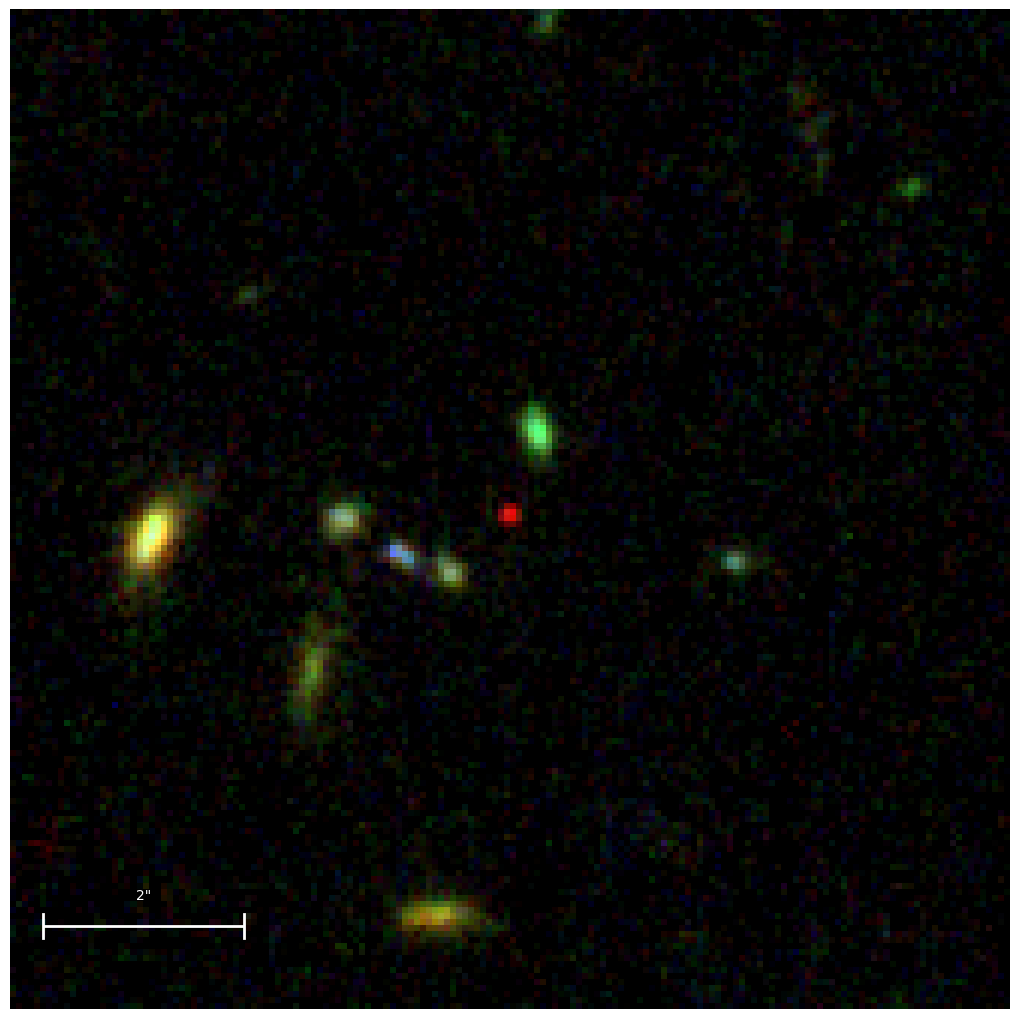

In [161]:
#make large plot of the a rgb cutout for the first object in the sample, with f444w in red, f277w in green, and f150w in blue, and a 1" scale bar. Use the regular cutouts for each band. Show the plot.
# Combine the three bands into a single true-color composite (like the COSMOS-Web cutout/FITS
# viewer) instead of three separate grayscale panels: each band is scaled to units of its own
# background noise, then combined with an asinh ("Lupton") stretch so bright cores don't
# saturate while faint, diffuse flux stays visible.
from astropy.visualization import make_lupton_rgb
from astropy.stats import sigma_clipped_stats
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from matplotlib.lines import Line2D

first_obj = catalogHandler.get_cat_photom(stack_sample_filtername)[0]
first_obj_id = first_obj['id']
cutout_root_dir = STACK_COSMOS_WEB_FW
verbose = verbosity

keep_labels_and_ticks = False

size_arcsec = 10
channels = {}  # StackCosmosWebFW -> noise-normalized cutout data
common_wcs = None
pixscale_arcsec = None
for band in [StackCosmosWebFW.F150W, StackCosmosWebFW.F277W, StackCosmosWebFW.F444W]:
    b = str(band.get_filter_name()).lower()
    cutout_file_path = f"{cutout_root_dir}{str(band.get_filter_name()).lower()}/cutouts/{first_obj_id}_{str(band.get_filter_name()).lower()}_cutout.fits"
    if not os.path.exists(cutout_file_path):
        if verbose >= 1:
            print(f"Cutout file {cutout_file_path} does not exist. Skipping masking for object {first_obj_id} in band {band.get_filter_name()}.")
        continue
    with fits.open(cutout_file_path) as hdul:
        data = hdul[0].data.astype(float)
        wcs = WCS(hdul[0].header).celestial
        #cut out a square region of size 10 arcsec x 10 arcsec around the center of the image
        center_pixel = (data.shape[1] / 2, data.shape[0] / 2)
        pixscale_arcsec = wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value
        size_pix = int(size_arcsec / pixscale_arcsec)
        cutout = Cutout2D(data, position=center_pixel, size=(size_pix, size_pix), wcs=wcs)
        data = cutout.data
        wcs = cutout.wcs
    # masked (non-target) pixels are NaN; treat them as background for display purposes
    _, _, sigma = sigma_clipped_stats(data, sigma=3.0)
    channels[band] = np.nan_to_num(data, nan=0.0) / sigma  # scale each band to units of its own background noise
    common_wcs = wcs

r = channels[StackCosmosWebFW.F444W]
g = channels[StackCosmosWebFW.F277W]
b_ = channels[StackCosmosWebFW.F150W]

# asinh ("Lupton") composite -- the same non-linear stretch survey cutout viewers (including
# COSMOS-Web's) use so bright cores don't blow out while faint, diffuse flux stays visible.
rgb_image = make_lupton_rgb(r, g, b_, stretch=20, Q=3, minimum=0)

rgb_cutout_fig = plt.figure(figsize=(10, 10))
rgb_cutout_fig.set_layout_engine(None)  # a constrained/tight layout engine would override our manual margins below
ax = rgb_cutout_fig.add_subplot(1, 1, 1, projection=common_wcs)
ax.imshow(rgb_image, origin='lower')
# ax.set_title(f"Object {first_obj_id}")#: RGB = F444W / F277W / F150W")
ax.coords[0].set_major_formatter('d.dddd')
ax.coords[1].set_major_formatter('d.dddd')
if keep_labels_and_ticks:
    ax.set_xlabel('RA (J2000)')
    ax.set_ylabel('Dec (J2000)')
    ax.coords[0].set_ticklabel_visible(True)
    ax.coords[1].set_ticklabel_visible(True)
else:
    ax.coords[0].set_ticklabel_visible(False)
    ax.coords[1].set_ticklabel_visible(False)
    ax.set_axis_off()
    ax.set_aspect('auto')  # WCSAxes' default equal aspect pads the axes (letterboxing) to keep the sky aspect exact
    ax.set_position([0, 0, 1, 1])  # a stronger override than subplots_adjust -- pins the axes to fill the figure

# 1 arcsec scale bar (convert to pixels via the WCS pixel scale)
bar_arcsec = 2.0
bar_pix = bar_arcsec / pixscale_arcsec
x0 = 0.03 * data.shape[1]
y0 = 0.08 * data.shape[0]
endcap = 0.30 * bar_pix

ax.plot([x0, x0 + bar_pix], [y0, y0], color='white', lw=2, transform=ax.transData, solid_capstyle='butt')
ax.plot([x0, x0], [y0 - endcap / 5, y0 + endcap / 5], color='white', lw=2, transform=ax.transData)
ax.plot([x0 + bar_pix, x0 + bar_pix], [y0 - endcap / 5, y0 + endcap / 5], color='white', lw=2, transform=ax.transData)
ax.text(x0 + bar_pix / 2, y0 + endcap * 0.4, f'{bar_arcsec:g}"',
    color='white', ha='center', va='bottom', transform=ax.transData)

if keep_labels_and_ticks:
    # default layout leaves room for the axis labels/ticks
    plt.show()
else:
    # no labels/frame left to make room for -- collapse the margins so the image fills the figure
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    plt.show()


#### remake cleaner inspection plot

Using the given radius of 2.3999999999997597 arcsec for peak extraction as provided.
Using provided radius of 12 arcsec for statistics and pixel scale of 0.39999999999996 arcsec/pixel.
Using the given radius of 5.500008 arcsec for peak extraction as provided.
Using provided radius of 28 arcsec for statistics and pixel scale of 1.1000016000000001 arcsec/pixel.
Using the given radius of 0.800000008848 arcsec for peak extraction as provided.
Using provided radius of 4 arcsec for statistics and pixel scale of 0.200000002212 arcsec/pixel.
Using the given radius of 1.20000000055392 arcsec for peak extraction as provided.
Using provided radius of 6 arcsec for statistics and pixel scale of 0.15000000006924 arcsec/pixel.


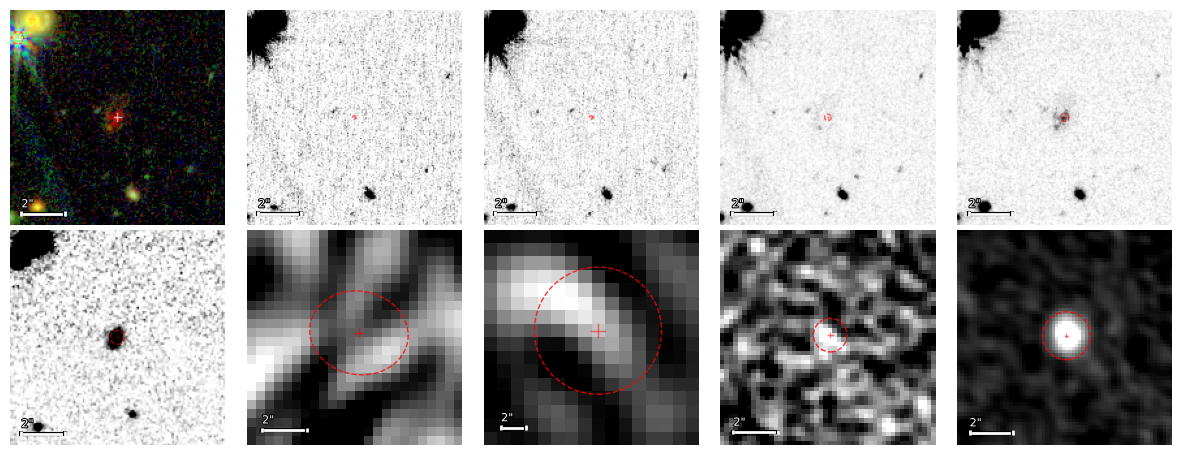

In [256]:
#make a multipanel plot of object 9, of its rgb image, the f814w cutout, f115w cutout, f150w cutout, f277w cutout, and f444w cutout, the f770w cutout, the meerkat image, the champs image, and the vla 3ghz image. Use the regular cutouts for each band. Show the plot.
# NOTE: no F814W (HST/ACS) cutouts exist anywhere in this project's data pipeline, so that
# panel is omitted. Everything below uses the regular (unmasked) per-band cutouts, and is
# looked up for object id 9 specifically (previously this cell silently reused first_obj_id,
# ra/dec, and rgb_image left over from the single-object RGB cell above, which was built for
# the *first object in the stacking sample* -- not necessarily object 9 -- and never defined
# ra/dec itself, which crashed plot_panel with a NaN pixel position).
from astropy.visualization import make_lupton_rgb
from astropy.stats import sigma_clipped_stats

object_9_id = 171478
obj = next((o for o in catalogHandler.get_cat_photom('condition_detection_reviewed') if o['id'] == object_9_id), None)
if obj is None:
    raise ValueError(f"Object with ID {object_9_id} not found in the catalog for filter '{stack_sample_filtername}'.")
first_obj_id = obj['id']
ra, dec = obj['ra'], obj['dec']

cutout_size_arcsec = 5
jwst_cutout_size_arcsec = cutout_size_arcsec*2
# Build the RGB composite for object 9 from its regular cutouts (same asinh/Lupton composite
# as the earlier single-object RGB cell, but unmasked per this cell's own instructions).
rgb_channels = {}
common_wcs = None
for band in [StackCosmosWebFW.F150W, StackCosmosWebFW.F277W, StackCosmosWebFW.F444W]:
    b = str(band.get_filter_name()).lower()
    cutout_file_path = f"{cutout_root_dir}{b}/cutouts/{first_obj_id}_{b}_cutout.fits"
    if not os.path.exists(cutout_file_path):
        if verbose >= 1:
            print(f"Cutout file {cutout_file_path} does not exist. Skipping band {band.get_filter_name()} for object {first_obj_id}.")
        continue
    with fits.open(cutout_file_path) as hdul:
        data = hdul[0].data.astype(float)
        wcs = WCS(hdul[0].header).celestial
        center_pixel = (data.shape[1] / 2, data.shape[0] / 2)
        pixscale_arcsec = wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value
        size_pix = int(jwst_cutout_size_arcsec / pixscale_arcsec)
        cutout = Cutout2D(data, position=center_pixel, size=(size_pix, size_pix), wcs=wcs)
        data = cutout.data
        wcs = cutout.wcs
    _, _, sigma = sigma_clipped_stats(data, sigma=3.0)
    rgb_channels[band] = np.nan_to_num(data, nan=0.0) / sigma
    common_wcs = wcs

rgb_image = make_lupton_rgb(rgb_channels[StackCosmosWebFW.F444W], rgb_channels[StackCosmosWebFW.F277W],
                             rgb_channels[StackCosmosWebFW.F150W], stretch=6, Q=8, minimum=0)

fig_multi_map = plt.figure(figsize=(15, 10))
n_rows, n_cols = 2,5
ax_rgb = fig_multi_map.add_subplot(n_rows, n_cols, 1, projection=common_wcs)
ax_rgb.imshow(rgb_image, origin='lower')
# ax_rgb.set_title(f"Object {first_obj_id}: RGB = F444W / F277W / F150W")
ax_rgb.coords[0].set_major_formatter('d.dddd')
ax_rgb.coords[1].set_major_formatter('d.dddd')
ax_rgb.coords[0].set_ticklabel_visible(False)
ax_rgb.coords[1].set_ticklabel_visible(False)
#include scale bar     include_scale_bar(fig, ax, wcs, x_min, x_max, y_min, y_max, scale_bar_length_arcsec=2, color='white')
rgb_xmin, rgb_xmax = ax_rgb.get_xlim()
rgb_ymin, rgb_ymax = ax_rgb.get_ylim()
rgb_x_pixel, rgb_y_pixel = wcs.celestial.world_to_pixel(SkyCoord(ra * u.deg, dec * u.deg))
include_scale_bar(fig_multi_map, ax_rgb, common_wcs, rgb_xmin, rgb_xmax, rgb_ymin, rgb_ymax, scale_bar_length_arcsec=2, color='white')
include_small_crosshair(fig_multi_map, ax_rgb, rgb_x_pixel, rgb_y_pixel, rgb_xmin, rgb_ymin, size_pixels=3, color='white', alpha=0.6)

for band in [StackCosmosWebFW.F115W, StackCosmosWebFW.F150W, StackCosmosWebFW.F277W, StackCosmosWebFW.F444W, StackCosmosWebFW.F770W]:
    b_str = str(band.get_filter_name()).lower()
    cutout_file_path = f"{cutout_root_dir}{b_str}/cutouts/{first_obj_id}_{b_str}_cutout.fits"
    if not os.path.exists(cutout_file_path):
        if verbose >= 1:
            print(f"Cutout file {cutout_file_path} does not exist. Skipping masking for object {first_obj_id} in band {band.get_filter_name()}.")
        continue
    with fits.open(cutout_file_path) as hdul:
        data = hdul[0].data.astype(float)
        wcs = WCS(hdul[0].header).celestial
        #cut out a square region of size 10 arcsec x 10 arcsec around the center of the image
        center_pixel = (data.shape[1] / 2, data.shape[0] / 2)
        pixscale_arcsec = wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value
        size_pix = int(jwst_cutout_size_arcsec / pixscale_arcsec)
        cutout = Cutout2D(data, position=center_pixel, size=(size_pix, size_pix), wcs=wcs)
        data = cutout.data
        wcs = cutout.wcs
    if band == StackCosmosWebFW.F115W:
        f115w_cutout = data
    if band == StackCosmosWebFW.F150W:
        f150w_cutout = data
    if band == StackCosmosWebFW.F277W:
        f277w_cutout = data
    if band == StackCosmosWebFW.F444W:
        f444w_cutout = data
    if band == StackCosmosWebFW.F770W:
        f770w_cutout = data
        
jwst_vmin, jwst_vmax = np.nanpercentile(f444w_cutout, [8, 97])

jwst_PA_APER = 107.41970461323311
# jwst_60mas_pix_arcsec = 0.06

def plot_jwst_band_cutouts(fig_multi_map : plt.Figure, ax_band : plt.Axes, n_rows, n_cols, wcs, fBANDw_cutout, rgb_x_pixel, rgb_y_pixel, psf_fwhm_arcsec=0.09):
    ax_band.imshow(fBANDw_cutout, origin='lower', cmap='Greys', vmin=jwst_vmin, vmax=jwst_vmax)
    ax_band.coords[0].set_major_formatter('d.dddd')
    ax_band.coords[1].set_major_formatter('d.dddd')
    ax_band.coords[0].set_ticklabel_visible(False)
    ax_band.coords[1].set_ticklabel_visible(False)
    
    xmin, xmax = ax_band.get_xlim()
    ymin, ymax = ax_band.get_ylim()
    #include scale bar
    include_scale_bar(fig_multi_map, ax_band, wcs, xmin, xmax, ymin, ymax, scale_bar_length_arcsec=2, color='white', scalebar_outline_width=3)
    include_small_crosshair(fig_multi_map, ax_band, rgb_x_pixel, rgb_y_pixel, xmin, ymin, size_pixels=1, color='red', alpha=0.2)
    include_ellipse_scaled(fig_multi_map, ax_band, rgb_x_pixel, rgb_y_pixel, first_obj_id, wcs, rgb_xmin, rgb_ymin, a_arcsec=psf_fwhm_arcsec, b_arcsec=psf_fwhm_arcsec, pa_deg=jwst_PA_APER, color='red', alpha=0.6)

ax_f115w = fig_multi_map.add_subplot(n_rows, n_cols, 2, projection=wcs)
plot_jwst_band_cutouts(fig_multi_map, ax_f115w, n_rows, n_cols, wcs, f115w_cutout, rgb_x_pixel, rgb_y_pixel, psf_fwhm_arcsec=0.08)

ax_f150w = fig_multi_map.add_subplot(n_rows, n_cols, 3, projection=wcs)
plot_jwst_band_cutouts(fig_multi_map, ax_f150w, n_rows, n_cols, wcs, f150w_cutout, rgb_x_pixel, rgb_y_pixel, psf_fwhm_arcsec=0.08)

ax_f277w = fig_multi_map.add_subplot(n_rows, n_cols, 4, projection=wcs)
plot_jwst_band_cutouts(fig_multi_map, ax_f277w, n_rows, n_cols, wcs, f277w_cutout, rgb_x_pixel, rgb_y_pixel, psf_fwhm_arcsec=0.15)

ax_f444w = fig_multi_map.add_subplot(n_rows, n_cols, 5, projection=wcs)
plot_jwst_band_cutouts(fig_multi_map, ax_f444w, n_rows, n_cols, wcs, f444w_cutout, rgb_x_pixel, rgb_y_pixel, psf_fwhm_arcsec=0.19)

ax_f770w = fig_multi_map.add_subplot(n_rows, n_cols, 6, projection=wcs)
plot_jwst_band_cutouts(fig_multi_map, ax_f770w, n_rows, n_cols, wcs, f770w_cutout, rgb_x_pixel, rgb_y_pixel, psf_fwhm_arcsec=0.32)

# Each radio/sub-mm panel gets its own survey's WCS as the subplot projection (not the
# leftover JWST `wcs` from the loop above) since plot_panel crops each image in its own
# native pixel grid -- using a mismatched projection would draw the wrong RA/Dec grid on it.

sBand_wcs_projection = WCS(sBand_hdr).celestial
ax_S_band = fig_multi_map.add_subplot(n_rows, n_cols, 7, projection=sBand_wcs_projection)
sBand_5_arcsec_zoom_size_pix = int(cutout_size_arcsec / sBand_wcs_projection.proj_plane_pixel_scales()[0].to(u.arcsec).value)
plot_panel(fig_multi_map, ax_S_band, sBand_image, sBand_wcs_projection, sBand_hdr, ra, dec, first_obj_id, title_prefix="S Band", zoom_size=sBand_5_arcsec_zoom_size_pix, hide_title=True, cmap='gray', include_interface_box=False)#, resolution_arcsec=0.71)

mightee_wcs_projection = WCS(mightee_header).celestial
ax_mightee = fig_multi_map.add_subplot(n_rows, n_cols, 8, projection=mightee_wcs_projection)
mightee_5_arcsec_zoom_size_pix = int(cutout_size_arcsec / mightee_wcs_projection.proj_plane_pixel_scales()[0].to(u.arcsec).value)
plot_panel(fig_multi_map, ax_mightee, mightee_image, mightee_wcs, mightee_header, ra, dec, first_obj_id, title_prefix="MIGHTEE", zoom_size=mightee_5_arcsec_zoom_size_pix*2, hide_title=True, cmap='gray', include_interface_box=False)#, resolution_arcsec=0.71)

vla_wcs_projection = WCS(vla_hdr).celestial
ax_vla = fig_multi_map.add_subplot(n_rows, n_cols, 9, projection=vla_wcs_projection)
#zoom radio to cutout_size_arcsec x cutout_size_arcsec around the object
vla_5_arcsec_zoom_size_pix = int(cutout_size_arcsec / vla_wcs_projection.proj_plane_pixel_scales()[0].to(u.arcsec).value)
plot_panel(fig_multi_map, ax_vla, vla_image, vla_wcs_projection, vla_hdr, ra, dec, first_obj_id, title_prefix="VLA 3GHz", zoom_size=vla_5_arcsec_zoom_size_pix, hide_title=True, cmap='gray', include_interface_box=False)#, resolution_arcsec=0.71)

champs_wcs_projection = WCS(champs_header).celestial
ax_champs = fig_multi_map.add_subplot(n_rows, n_cols, 10, projection=champs_wcs_projection)
champs_5_arcsec_zoom_size_pix = int(cutout_size_arcsec / champs_wcs_projection.proj_plane_pixel_scales()[0].to(u.arcsec).value)
plot_panel(fig_multi_map, ax_champs, champs_image, champs_wcs_projection, champs_header, ra, dec, first_obj_id, title_prefix="CHAMPS", zoom_size=champs_5_arcsec_zoom_size_pix, hide_title=True, cmap='gray', include_interface_box=False)#, resolution_arcsec=0.71)



# lBand_wcs_projection = WCS(lBand_hdr).celestial
# ax_L_band = fig_multi_map.add_subplot(n_rows, n_cols, 11, projection=lBand_wcs_projection)
# lBand_5_arcsec_zoom_size_pix = int(cutout_size_arcsec / lBand_wcs_projection.proj_plane_pixel_scales()[0].to(u.arcsec).value)
# plot_panel(fig_multi_map, ax_L_band, lBand_image, lBand_wcs, lBand_hdr, ra, dec, first_obj_id, title_prefix="L Band", zoom_size=lBand_5_arcsec_zoom_size_pix, hide_title=True, cmap='gray', include_interface_box=False)#, resolution_arcsec=0.71)
fig_multi_map.subplots_adjust(wspace=0.1, hspace=-0.6)

plt.show()


#### cutout summation plot (all pure objects)

Using the given radius of 0.08 arcsec for peak extraction as provided.
Using provided radius of 0 arcsec for statistics and pixel scale of 0.06000000000000131 arcsec/pixel.
Using the given radius of 0.08 arcsec for peak extraction as provided.
Using provided radius of 0 arcsec for statistics and pixel scale of 0.06000000000000131 arcsec/pixel.
Using the given radius of 0.08 arcsec for peak extraction as provided.
Using provided radius of 0 arcsec for statistics and pixel scale of 0.06000000000000131 arcsec/pixel.
Using the given radius of 0.08 arcsec for peak extraction as provided.
Using provided radius of 0 arcsec for statistics and pixel scale of 0.06000000000000131 arcsec/pixel.
Using the given radius of 0.15 arcsec for peak extraction as provided.
Using provided radius of 1 arcsec for statistics and pixel scale of 0.06000000000000131 arcsec/pixel.
Using the given radius of 0.15 arcsec for peak extraction as provided.
Using provided radius of 1 arcsec for statistics and pixel scale

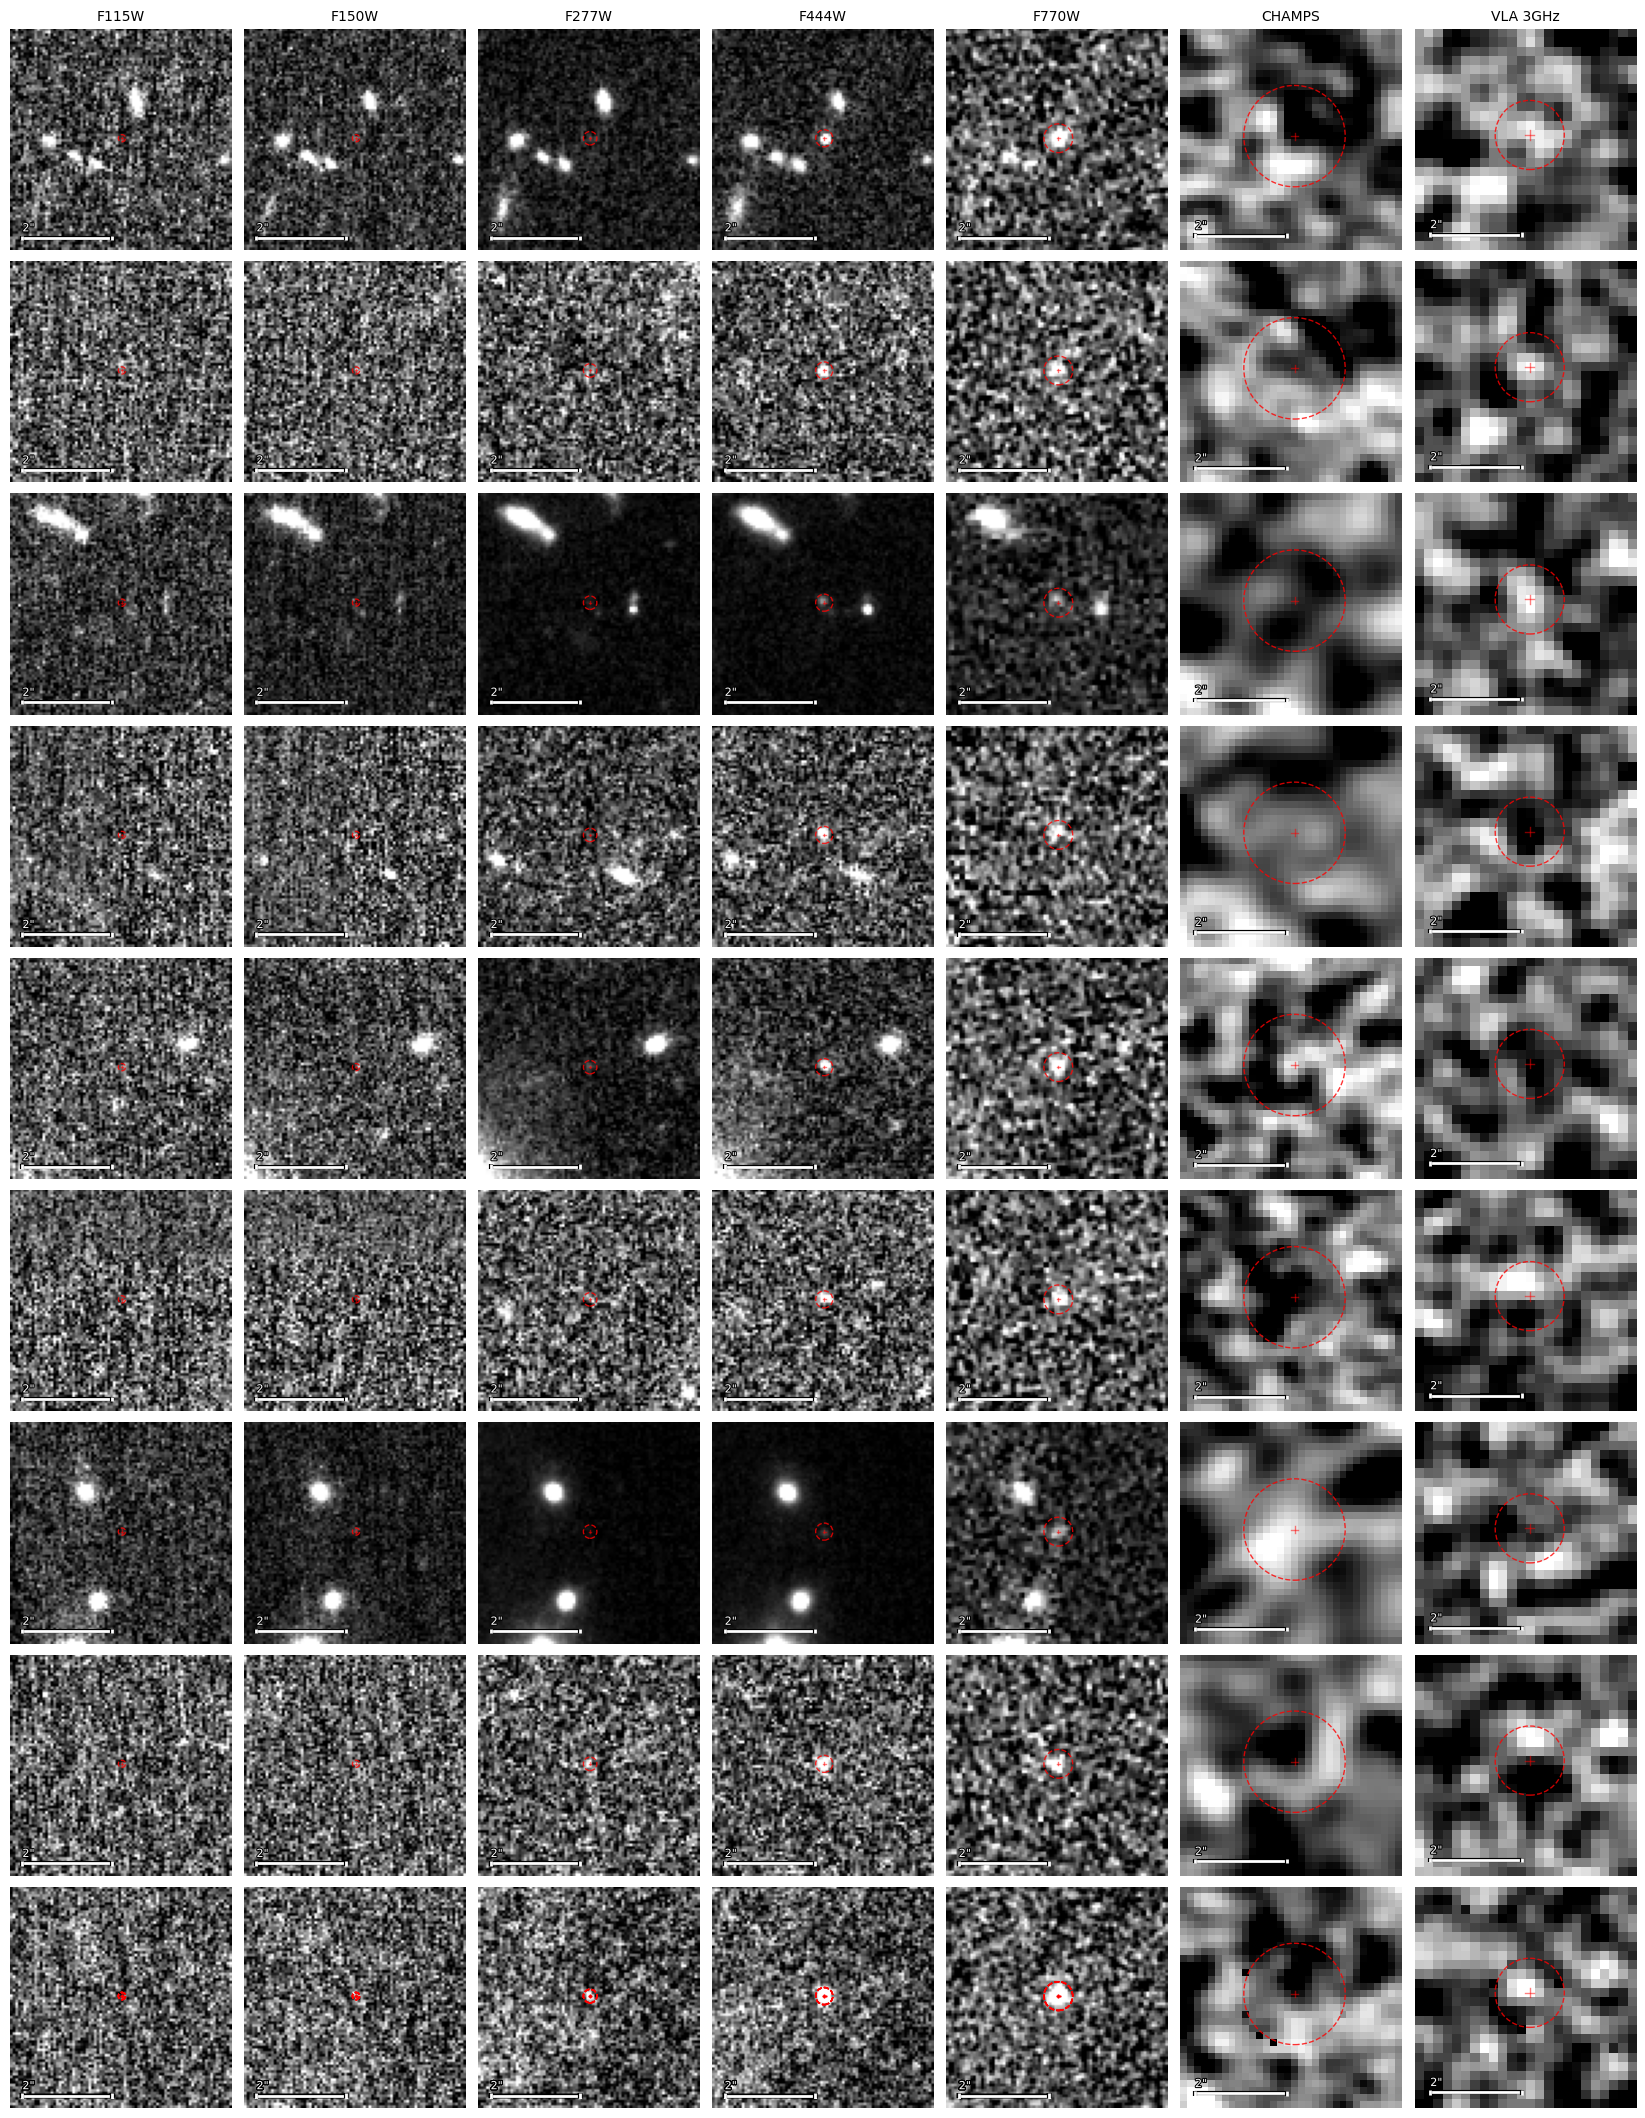

In [250]:
#similar to last plot but instead we make a multipanel plot of all pure dropouts and their cutouts, so 7 columns (f115w, f150w, f277w, f444w, f770w, champs, vla 3ghz) and as many rows as needed for all pure dropouts plus the last row is the stacked image of all pure dropouts in each band. Use the regular cutouts for each band. Show the plot.

fig_pure_dropouts = plt.figure(figsize=(21, 3 * (len(catalogHandler.get_cat_photom(stack_sample_filtername)) + 1)))
n_rows = len(catalogHandler.get_cat_photom(stack_sample_filtername)) + 1
n_cols = 7
cmap_name = 'gray'
#create all the subplots axes so we can index them later, and label the top row with column (band) names
col_titles = ["F115W", "F150W", "F277W", "F444W", "F770W", "CHAMPS", "VLA 3GHz"]
for i in range(n_rows):
    for j in range(n_cols):
        ax = fig_pure_dropouts.add_subplot(n_rows, n_cols, i * n_cols + j + 1)
        ax.set_axis_off()
        if i == 0:
            ax.set_title(col_titles[j], fontsize=10)

cutout_size_arcsec=5

for i, obj in enumerate(catalogHandler.get_cat_photom(stack_sample_filtername)):
    obj_id = obj['id']
    ra, dec = obj['ra'], obj['dec']
    center_x_pixel, center_y_pixel = wcs.celestial.world_to_pixel(SkyCoord(ra * u.deg, dec * u.deg))

    for j, band in enumerate([StackCosmosWebFW.F115W, StackCosmosWebFW.F150W, StackCosmosWebFW.F277W, StackCosmosWebFW.F444W, StackCosmosWebFW.F770W]):
        b_str = str(band.get_filter_name()).lower()
        cutout_file_path = f"{cutout_root_dir}{b_str}/cutouts/{obj_id}_{b_str}_cutout.fits"
        if not os.path.exists(cutout_file_path):
            if verbose >= 1:
                print(f"Cutout file {cutout_file_path} does not exist. Skipping band {band.get_filter_name()} for object {obj_id}.")
            continue
        with fits.open(cutout_file_path) as hdul:
            data = hdul[0].data.astype(float)
            wcs = WCS(hdul[0].header).celestial
            header = hdul[0].header
            center_pixel = (data.shape[1] / 2, data.shape[0] / 2)
            pixscale_arcsec = wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value
            size_pix = int(cutout_size_arcsec / pixscale_arcsec)
            # cutout = Cutout2D(data, position=center_pixel, size=(size_pix, size_pix), wcs=wcs)
            # data = cutout.data
            # wcs = cutout.wcs
        # ax_band = fig_pure_dropouts.add_subplot(n_rows, n_cols, i * n_cols + j + 1, projection=wcs)
        ax_band = fig_pure_dropouts.axes[i * n_cols + j]  # get the pre-created axis for this panel
        
        # plot_jwst_band_cutouts(fig_pure_dropouts, ax_band, n_rows, n_cols, wcs, data, center_x_pixel, center_y_pixel, psf_fwhm_arcsec=band.get_psf_fwhm_arcsec())
        plot_panel(fig_pure_dropouts, ax_band, data, wcs, header, ra, dec, obj_id, title_prefix=str(band.get_filter_name()), zoom_size=size_pix // 2, hide_title=True, cmap=cmap_name, include_interface_box=False, resolution_arcsec=band.get_psf_fwhm_arcsec())
        
        #also plot stacked image of all pure dropouts in each band in the last row
        stacked_image = get_jwst_stacked_images[band.get_filter_name()]
        stacked_wcs = wcs
        header = header
        # ax_band_stacked = fig_pure_dropouts.add_subplot(n_rows, n_cols, (n_rows - 1) * n_cols + j + 1, projection=stacked_wcs)
        ax_band_stacked = fig_pure_dropouts.axes[(n_rows - 1) * n_cols + j]  # get the pre-created axis for the last-row stacked panel
        plot_panel(fig_pure_dropouts, ax_band_stacked, stacked_image, stacked_wcs, header, ra, dec, obj_id, title_prefix=str(band.get_filter_name()), zoom_size=size_pix // 2, hide_title=True, cmap=cmap_name, include_interface_box=False, resolution_arcsec=band.get_psf_fwhm_arcsec())
        
    for j, band in enumerate([StackCHAMPS.CHAMPS_BAND, StackVLA3GHz.VLA_3GHZ]):
        if band == StackCHAMPS.CHAMPS_BAND:
            image = champs_image
            wcs = WCS(champs_header).celestial
            header = champs_header
            zoom_size_pix = int(cutout_size_arcsec / wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value)
            title_prefix = "CHAMPS"
        elif band == StackVLA3GHz.VLA_3GHZ:
            image = vla_image
            header = vla_hdr
            wcs = WCS(vla_hdr).celestial
            zoom_size_pix = int(cutout_size_arcsec / wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value)
            title_prefix = "VLA 3GHz"
        # ax_band = fig_pure_dropouts.add_subplot(n_rows, n_cols, i * n_cols + 5 + j + 1, projection=wcs)
        ax_band = fig_pure_dropouts.axes[i * n_cols + 5 + j]  # get the pre-created axis for this panel
        plot_panel(fig_pure_dropouts, ax_band, image, wcs, header, ra, dec, obj_id, title_prefix=title_prefix, zoom_size=zoom_size_pix // 2, hide_title=True, cmap=cmap_name, include_interface_box=False)
        
        stacked_image = get_champs_stacked_images[band.get_filter_name()] if band == StackCHAMPS.CHAMPS_BAND else get_vla3ghz_stacked_images[band.get_filter_name()]
        #the stacked array is a small cutout, not the full mosaic, so it needs its own local WCS
        #(saved alongside the stacked FITS file) rather than the mosaic-scale wcs from the loop above
        stacked_root_dir = STACK_CHAMPS if band == StackCHAMPS.CHAMPS_BAND else STACK_VLA_3GHZ
        stacked_file_path = f"{stacked_root_dir}{str(band.get_filter_name()).lower()}/stacked/{str(band.get_filter_name()).lower()}_stacked.fits"
        with fits.open(stacked_file_path) as stacked_hdul:
            stacked_wcs = WCS(stacked_hdul[0].header).celestial
        if i == 0:
            #the stack isn't tied to any single object's real sky position (each cutout was
            #recentered on its own object before stacking), so use a synthetic ra/dec at the
            #array's own center pixel instead of reusing this object's real ra/dec -- that real
            #ra/dec usually fell outside the stack's small WCS footprint, which is why 'data not
            #available' got drawn on top of a previous iteration's successful imshow; only plot
            #once since the stack is identical across every object iteration
            stack_center_pixel = (stacked_image.shape[1] / 2, stacked_image.shape[0] / 2)
            stack_coord = stacked_wcs.pixel_to_world(*stack_center_pixel)
            ax_band_stacked = fig_pure_dropouts.axes[(n_rows - 1) * n_cols + 5 + j]  # get the pre-created axis for the last-row stacked panel
            plot_panel(fig_pure_dropouts, ax_band_stacked, stacked_image, stacked_wcs, header, stack_coord.ra.deg, stack_coord.dec.deg, f"{title_prefix}_stack", title_prefix=title_prefix, zoom_size=zoom_size_pix // 2, hide_title=True, cmap=cmap_name, include_interface_box=False)
        
    # #name the row the object id
    # fig_pure_dropouts.text(0.01, 1 - (i + 0.5) / n_rows, f"Object {obj_id}", fontsize=10, ha='left', va='center', transform=fig_pure_dropouts.transFigure)
    
    # #name the last row "Stacked"
    # if i == len(catalogHandler.get_cat_photom(stack_sample_filtername)) - 1:
    #     fig_pure_dropouts.text(0.01, 1 - (i + 1.5) / n_rows, "Stacked", fontsize=10, ha='left', va='center', transform=fig_pure_dropouts.transFigure)
    
    #decrease space between panels
    fig_pure_dropouts.subplots_adjust(wspace=0.05, hspace=0.05)


#### stack animation gif

In [ ]:

# Example: build the stack one object at a time, ~0.8 s per added image.
stacked_animation, _anim = animate_progressive_stack(
    stack_sample_filtername=stack_sample_filtername,
    use_median_stacking=use_median_stacking,
    use_inverse_variance_weighting=True,
    image_size_arcsec=5,
    seconds_per_image=0.8,
    verbose=verbosity,
)

#save stacked_animation to a gif file
if stacked_animation is not None:
    gif_save_path = f"{STACK_COSMOS_WEB_FW}stacked_animation.gif"
    _anim.save(gif_save_path, writer='pillow', fps=5)
    print(f"Saved stacked animation to {gif_save_path}.") if verbosity >= 1 else None

stacked_animation

#### stack champs

In [ ]:

use_median_stacking = False
use_purity_dropout_for_stacking = False
use_frame_stdev_for_stacking = False #either each frame's own stdev is used for masking, or the stdev is computed across all frames in the sample, i.e. each pixel against the other ~20s objects pixels.

if use_purity_dropout_for_stacking:
    stack_sample_filtername = 'condition_strict_pure_277_dropout'
else:
    stack_sample_filtername = 'condition_stacking_sample'
    
verbosity = 1
    
# make_cutouts_for_all_objects(overwrite=False, verbose=verbosity)

get_masked_cutouts(stack_sample_filtername=stack_sample_filtername, use_frame_stdev_for_stacking=use_frame_stdev_for_stacking, verbose=verbosity)

# make_background_subtractions(overwrite=False, verbose=2, write_bgsub=False)

get_stacked_images = stack_masked_cutouts(stack_sample_filtername=stack_sample_filtername, use_median_stacking=use_median_stacking, verbose=verbosity, use_inverse_variance_weighting=True)
plot_stacked_images(image_size_arcsec=5, verbose=verbosity)
cosmos_web_stacked_statistic_table = get_peak_flux_density_and_background_stdev(use_median_stacking=use_median_stacking, use_purity_dropout_for_stacking=use_purity_dropout_for_stacking, verbose=2)#verbose=verbosity)

#### stack vla 3ghz

In [ ]:

use_median_stacking = False
use_purity_dropout_for_stacking = False
use_frame_stdev_for_stacking = False #either each frame's own stdev is used for masking, or the stdev is computed across all frames in the sample, i.e. each pixel against the other ~20s objects pixels.

if use_purity_dropout_for_stacking:
    stack_sample_filtername = 'condition_strict_pure_277_dropout'
else:
    stack_sample_filtername = 'condition_stacking_sample'
    
verbosity = 1
    
# make_cutouts_for_all_objects(overwrite=False, verbose=verbosity)

get_masked_cutouts(stack_sample_filtername=stack_sample_filtername, use_frame_stdev_for_stacking=use_frame_stdev_for_stacking, verbose=verbosity)

# make_background_subtractions(overwrite=False, verbose=2, write_bgsub=False)

get_stacked_images = stack_masked_cutouts(stack_sample_filtername=stack_sample_filtername, use_median_stacking=use_median_stacking, verbose=verbosity, use_inverse_variance_weighting=True)
plot_stacked_images(image_size_arcsec=5, verbose=verbosity)
cosmos_web_stacked_statistic_table = get_peak_flux_density_and_background_stdev(use_median_stacking=use_median_stacking, use_purity_dropout_for_stacking=use_purity_dropout_for_stacking, verbose=2)#verbose=verbosity)

## create supertable

In [53]:
print(f"Stacked statistic table: {cosmos_web_stacked_statistic_table[0]}") if verbosity >= 1 else None
print(f"Stacked statistic table: {vla3ghz_stacked_statistic_table[0]}") if verbosity >= 1 else None


Stacked statistic table: ('F115W', 0.001325121249826376, 0.002464395206055898)
Stacked statistic table: ('VLA_3GHZ', 2.7510780958182123e-06, 9.966746680019064e-07)


In [261]:
# create a table which consolidates the flux measurements from JWST and radio (VLA 3Ghz, CHAMPS, ALMA, Superdeblended)
#will eventually CIGALE SED fit

# CIGALE naming conventions: 
# File containing the input data. The columns are:
# * 'id': name of the object.
# * 'redshift': redshift of the object. If 0, the distance is assumed to
# be 10 pc. If negative the photometric mode is enabled. In that case an
# explicit redshift grid must be provided in the redshfting module.
# * 'distance' (Mpc, optional): distance in Mpc. Optional, if present it
# will be used in lieu of the distance computed from the redshift
# assuming a Planck et al. (2018) cosmology.
# * band fluxes: fluxes in filters in mJy. Each column is identified
# with a unique filter name, for instance jwst.nircam.F200W for the 2 μm
# filter of the NIRCAM instrument onboard JWST. The known filters are
# avalaible from the command 'pcigale-filters list'.
# * line fluxes: fluxes in lines in W/m². Each column is identified
# after a unique line name prefixed with 'line.', for instance
# line.H-alpha. The known filters are available from the command
# 'pcigale-filters list'. It is possible to combine lines together, for
# instance line.NII-654.8+H-alpha+NII-658.3 will be the sum of Hα and
# the adjacent NII lines.
# * physical properties: values of the intensive and extensive physical
# properties (e.g., dust.luminosity for the dust luminosity). To
# determine the format of the columns and the units, it is suggested to
# do a minimal run and examine the output FITS table.
# * uncertainties: the uncertainties for the band and line fluxes as
# well as for the physical properties are given using the same column
# names with the '_err' suffix.
# Important notes:
# * Fluxes can be positive or negative.
# * Upper limits are indicated with a negative value for the
# uncertainty.
# * In case some fluxes are missing for some objects, they can be
# replaced with NaN.
# * This file is optional to generate the configuration file, in
# particular for the savefluxes module.
super_table = Table(
    names=('id', 'redshift', 'RA', 'DEC',
           'jwst.nircam.F115W', 'jwst.nircam.F115W_err',
           'jwst.nircam.F150W', 'jwst.nircam.F150W_err',
           'jwst.nircam.F277W', 'jwst.nircam.F277W_err',
           'jwst.nircam.F444W', 'jwst.nircam.F444W_err',
           'jwst.miri.F770W',   'jwst.miri.F770W_err',
           # custom-registered filters:
           'vla.S',      'vla.S_err',
           'alma.A3Band3', 'alma.A3Band3_err',
           'alma.champs',     'alma.champs_err',
           'superdeblendedF24', 'superdeblendedF24_err',
           'superdeblendedF100', 'superdeblendedF100_err',
           'superdeblendedF160', 'superdeblendedF160_err',
           ),
    #dtype=('i4', 'f8', 'f8', 'f8',
    dtype=('U16', 'f8', 'f8', 'f8',
           'f4','f4', 'f4','f4', 'f4','f4', 'f4','f4', 'f4','f4',
           'f4','f4', 'f4','f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4'),
    meta={'name': 'Super Table of Flux Measurements from JWST and Radio'},
)

DUSTY_RED_GALAXY_ID = 171478
DUSTY_RED_GALAXY_ID2 = 183201
stacked_images = True

# for i, obj in enumerate(catalogHandler.get_cat_photom('condition_detection_reviewed')[catalogHandler.get_cat_photom('condition_detection_reviewed')['id'] == DUSTY_RED_GALAXY_ID]):
# for i, obj in enumerate(catalogHandler.get_cat_photom('condition_detection_reviewed')[catalogHandler.get_cat_photom('condition_detection_reviewed')['id'] == DUSTY_RED_GALAXY_ID2]):
for i, obj in enumerate(catalogHandler.get_cat_photom('condition_detection_reviewed')):
       if not stacked_images:
              obj_id = obj['id']
              ra, dec = obj['ra'], obj['dec']
              redshift = catalogHandler.get_z_redshift('condition_detection_reviewed')[catalogHandler.get_cat_photom('condition_detection_reviewed')['id'] == obj_id][0]
              #JWST fluxes in mJy, with errors
              # print(catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f115w'))
              f115, f115_err = catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f115w', useModel=True)[0], catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f115w', useModel=True)[1] # fluxes in microJy
              f150, f150_err = catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f150w', useModel=True)[0], catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f150w', useModel=True)[1] # fluxes in microJy
              f277, f277_err = catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f277w', useModel=True)[0], catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f277w', useModel=True)[1] # fluxes in microJy
              f444w, f444w_err = catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f444w', useModel=True)[0], catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f444w', useModel=True)[1] # fluxes in microJy
              f770w, f770w_err = catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f770w', useModel=True)[0], catalogHandler.get_filter_flux_of_id(obj_id, 'condition_detection_reviewed', 'f770w', useModel=True)[1] # fluxes in microJy
              
              #convert to mJy
              f115, f115_err = f115 / 1000, f115_err / 1000
              f150, f150_err = f150 / 1000, f150_err / 1000
              f277, f277_err = f277 / 1000, f277_err / 1000
              f444w, f444w_err = f444w / 1000, f444w_err / 1000
              f770w, f770w_err = f770w / 1000, f770w_err / 1000
              
              
              #if object is 171478, include super-deblended match
              if obj_id == DUSTY_RED_GALAXY_ID:
                     matched_super_deblended_row = matched_super_deblended[obj_id]
                     if len(matched_super_deblended_row) > 0:
                            f24, f24_err = matched_super_deblended_row['f24'], matched_super_deblended_row['df24'] # in microJy
                            f100, f100_err = matched_super_deblended_row['f100'], matched_super_deblended_row['df100'] # in microJy
                            f160, f160_err = matched_super_deblended_row['f160'], matched_super_deblended_row['df160'] # in microJy
                            
                            #convert to mJy
                            f24, f24_err = f24 / 1000, f24_err / 1000
                            # f100, f100_err = f100 / 1000, f100_err / 1000
                            # f160, f160_err = f160 / 1000, f160_err / 1000
                     else:
                            f24, f24_err = np.nan, np.nan
                            f100, f100_err = np.nan, np.nan
                            f160, f160_err = np.nan, np.nan
              else:
                     f24, f24_err = np.nan, np.nan
                     f100, f100_err = np.nan, np.nan
                     f160, f160_err = np.nan, np.nan
              
              #dict stores the object id as key, and a tuple of (ok_detection, intensity_point, intensity_avg, intensity_peak, stdev_value, rms_value) as value
              # VLA 3Ghz data is in Jy/Beam
              if matched_vla.get(obj_id) is not None and matched_vla[obj_id][0]:
                     vla_flux, vla_flux_err = matched_vla[obj_id][3] * 1000, matched_vla[obj_id][4] * 1000
              else:
                     vla_flux, vla_flux_err = matched_vla[obj_id][3] * 1000, matched_vla[obj_id][4] * 1000
              
              # champs data is in Jy/Beam
              if matched_champs_image.get(obj_id) is not None and matched_champs_image[obj_id][0]:
                     # print(matched_champs_image[obj_id])
                     champs_flux, champs_flux_err = matched_champs_image[obj_id][3] * 1000, matched_champs_image[obj_id][4] * 1000
              else:
                     champs_flux, champs_flux_err = matched_champs_image[obj_id][3] * 1000, matched_champs_image[obj_id][4] * 1000
              
              # ALMA A3 data is in mJy/Beam
              if matched_almaA3_prior.get(obj_id) is not None and matched_almaA3_prior[obj_id][0]:
                     print(f"Matched ALMA A3 prior for object {obj_id}: ")#{matched_almaA3_prior[obj_id]}")
                     # matched_almaA3_prior[obj_id] is an astropy.table.Row; convert to a Table (or dict) before printing
                     print(Table([matched_almaA3_prior[obj_id]]).to_pandas())
                     almaA3_flux, almaA3_flux_err = matched_almaA3_prior[obj_id]['Total_flux_pbcor'], matched_almaA3_prior[obj_id]['E_Total_flux_pbcor'] * 1
                     print(f"Observed ALMA A3 frequency for object {obj_id}: {micron_wavelength_to_frequency(matched_almaA3_prior[obj_id]['Obs_wavelength']) / 1e9:.4f} GHz")
              else:
                     print(f"No matched ALMA A3 prior for object {obj_id}. Setting flux and error to NaN.")
                     almaA3_flux, almaA3_flux_err = np.nan, np.nan #matched_almaA3_prior[obj_id]['Total_flux_pbcor'], matched_almaA3_prior[obj_id]['E_Total_flux_pbcor'] * -1
       else:
              # using stacked images;  grab from stacked_table_data the five jwst filters. leave the radio fluxes as NaN for now, since we don't have stacked radio images yet.
              # obj_id = 0
              
              #take the list of ints: masked_cutouts_object_ids and make it a single string of comma-separated values, and then use that as the obj_id for the stacked table
              obj_id = "Pure Stacked \n" + ','.join([str(i) for i in masked_cutouts_object_ids]) if use_purity_dropout_for_stacking else "Stacked \n" + ','.join([str(i) for i in masked_cutouts_object_ids])
              
              ra, dec = np.nan, np.nan
              redshift = np.nan
              # # Print the table
              # print("Band\tPeak Flux Density, Stdev")# \tRA\tDec")
              # for row in stacked_table_data:
              # print(f"{row[0]}\t{row[1]}\t{row[4]}")# \t{row[2]}\t{row[3]}")
              f115, f115_err = cosmos_web_stacked_statistic_table[0][1], cosmos_web_stacked_statistic_table[0][2] # in microJy
              f150, f150_err = cosmos_web_stacked_statistic_table[1][1], cosmos_web_stacked_statistic_table[1][2] # in microJy
              f277, f277_err = cosmos_web_stacked_statistic_table[2][1], cosmos_web_stacked_statistic_table[2][2] # in microJy
              f444w, f444w_err = cosmos_web_stacked_statistic_table[3][1], cosmos_web_stacked_statistic_table[3][2] # in microJy
              f770w, f770w_err = cosmos_web_stacked_statistic_table[4][1], cosmos_web_stacked_statistic_table[4][2] # in microJy

              #convert to mJy
              f115, f115_err = f115 / 1000, f115_err / 1000
              f150, f150_err = f150 / 1000, f150_err / 1000
              f277, f277_err = f277 / 1000, f277_err / 1000
              f444w, f444w_err = f444w / 1000, f444w_err / 1000
              f770w, f770w_err = f770w / 1000, f770w_err / 1000
              
              vla_flux, vla_flux_err = vla3ghz_stacked_statistic_table[0][1], -abs(vla3ghz_stacked_statistic_table[0][2]) # in Jy/Beam; negative error indicates upper limit
              almaA3_flux, almaA3_flux_err = np.nan, np.nan
              champs_flux, champs_flux_err = champs_stacked_statistic_table[0][1], -abs(champs_stacked_statistic_table[0][2]) # in Jy/Beam; negative error indicates upper limit
              f24, f24_err = np.nan, np.nan
              f100, f100_err = np.nan, np.nan
              f160, f160_err = np.nan, np.nan
       
       # Band 3	~100 GHz	alma.band3
       # Band 4	~145 GHz	alma.band4
       # Band 6	~230 GHz (1.2 mm)	alma.band6
       # Band 7	~345 GHz (870 µm)	alma.band7
       # Band 8	~460 GHz	alma.band8
       
       # show the table of flux measurements for the object
       # if confident in jwst redshift, use redshift.
       # otherwise if have a redshift from the CO(5-4) line, use that.
       # else use -1 for the redshift.
       if obj_id == DUSTY_RED_GALAXY_ID:
              redshift = 5.025
       if obj_id == DUSTY_RED_GALAXY_ID2:
              # redshift = 6.5
              redshift = np.nan
       super_table.add_row((obj_id, redshift, ra, dec,
                            f115, f115_err,
                            f150, f150_err,
                            f277, f277_err,
                            f444w, f444w_err,
                            f770w, f770w_err,
                            vla_flux, vla_flux_err,
                            almaA3_flux, almaA3_flux_err,
                            champs_flux, champs_flux_err,
                            f24, f24_err,
                            f100, f100_err,
                            f160, f160_err
                            ))
       
       if stacked_images:
              break
       
# display(HTML(f"""
# <div style="max-height:400px; overflow-y:auto; overflow-x:auto;">
#        {super_table.to_pandas().to_html(index=False)}
# </div>
# """))

#print as pd.dataframe
# import pandas as pd
super_table_df = super_table.to_pandas()
super_table_df

,id,redshift,RA,DEC,jwst.nircam.F115W,jwst.nircam.F115W_err,jwst.nircam.F150W,jwst.nircam.F150W_err,jwst.nircam.F277W,jwst.nircam.F277W_err,...,alma.A3Band3,alma.A3Band3_err,alma.champs,alma.champs_err,superdeblendedF24,superdeblendedF24_err,superdeblendedF100,superdeblendedF100_err,superdeblendedF160,superdeblendedF160_err
0,"Pure Stacked \n92586,184688,369896,384271,3852...",NaN,NaN,NaN,-0.000005,0.000004,0.000008,0.000004,0.000008,0.000002,...,NaN,NaN,-0.00003,-0.000139,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#save the table to a fits file
# super_table.write('cigale-run/super_table_flux_measurements.fits', overwrite=True)
# super_table.write('cigale-run/super_table_flux_measurements_171478.fits', overwrite=True)
# super_table.write('cigale-run/super_table_flux_measurements_183201.fits', overwrite=True)

# super_table.write('cigale-run/super_table_flux_measurements_stacked.fits', overwrite=True)
super_table.write('cigale-run/super_table_flux_measurements_pure_stacked.fits', overwrite=True)

In [ ]:
#just to double check, read super_table_flux_measurements_171478.fits and display as a pandas dataframe
super_table_check = Table.read('cigale-run/super_table_flux_measurements_171478.fits')
super_table_check_df = super_table_check.to_pandas()

super_table_check_df

In [ ]:
#run cigale-run/run_cigale.py

## display cigale results

In [182]:
#get the cigale run's posteriors into a table
CIGALE_RUN_DIR = 'cigale-run/out'
# CIGALE_RUN_DIR = 'cigale-run/20260709_132007_out_171478_best0p75_all_fixed'
CIGALE_RESULTS_FILE = os.path.join(CIGALE_RUN_DIR, 'results.fits')
cigale_results = Table.read(CIGALE_RESULTS_FILE)

#dont include columns which start with 'bayes.'
cigale_results_no_bayes = cigale_results#[[c for c in cigale_results.colnames if not c.startswith('bayes.')]]

row = cigale_results_no_bayes.to_pandas().iloc[0]

params = sorted({c[:-4] if c.endswith('_err') else c for c in row.index})
vals = [row.get(p) for p in params]
errs = [row.get(f'{p}_err') for p in params]

def _fmt(x):
    if x is None:
        return ''
    try:
        if isinstance(x, (list, tuple, np.ndarray)):
            return str(x)
        xf = float(x)
        if np.isnan(xf):
            return ''
        return f"{xf:.4e}"
    except Exception:
        return str(x)

summary = pd.DataFrame({
    'value': [_fmt(v) for v in vals],
    'err':   [_fmt(e) for e in errs],
}, index=params)

with pd.option_context('display.max_rows', None, 'display.float_format', '{:.4g}'.format):
    display(summary)



#take the dust luminosity and convert to SFR using the Kennicutt (1998) relation: SFR [M_sun/yr] = 1.0e-10 * L_IR [L_sun] for a Chabrier IMF. The dust luminosity is in Lsun units, so we can just multiply by 1e-10 to get the SFR in Msun/yr.
dust_luminosity = row.get('best.dust.luminosity') # in watts
print(f"Dust luminosity: {dust_luminosity:.4e} Watts")
dust_luminosity = dust_luminosity / 3.828e26 if dust_luminosity is not None else None # convert to Lsun
sfr = 1.0e-10 * dust_luminosity if dust_luminosity is not None else None
print(f"Dust luminosity: {dust_luminosity:.4e} Lsun")
print(f"Star formation rate (SFR): {sfr:.4e} Msun/yr")

,value,err
bayes.agn.accretion_power,0.0000e+00,0.0000e+00
bayes.agn.fracAGN,0.0000e+00,0.0000e+00
bayes.agn.luminosity,0.0000e+00,0.0000e+00
bayes.alma.A3Band6,1.9401e-04,1.6390e-05
bayes.alma.champs,1.5435e-04,1.3039e-05
bayes.attenuation.Av_BC,1.5857e+03,2.0650e+03
bayes.attenuation.Av_ISM,4.3315e+00,1.1901e+00
bayes.dust.luminosity,4.0246e+35,3.4001e+34
bayes.jwst.miri.F770W,1.7939e-04,6.8667e-06
bayes.jwst.nircam.F115W,1.5940e-23,5.1547e-18


Dust luminosity: 4.0423e+35 Watts
Dust luminosity: 1.0560e+09 Lsun
Star formation rate (SFR): 1.0560e-01 Msun/yr
